In [ ]:
from google.colab import files
import zipfile
import os

print("Please select ROM.zip")

uploaded = files.upload()

zip_name = next(iter(uploaded.keys()))

print(f"\nUploaded: {zip_name}")

extract_dir = "/content/ROM"

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("\nDataset extracted to:")
print(extract_dir)

Please select ROM.zip


Saving raw.zip to raw.zip

Uploaded: raw.zip

Dataset extracted to:
/content/ROM


In [ ]:
from pathlib import Path

ROOT = Path("/content/ROM")

print("Top-level contents:")
for p in sorted(ROOT.iterdir()):
    print("-", p.name)

print("\nAll subfolders:")
for p in sorted(ROOT.rglob("*")):
    if p.is_dir():
        print(p)

print("\nFirst 30 image-like files:")
image_files = sorted([
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in {".png", ".jpg", ".jpeg"}
])

print("Total image-like files:", len(image_files))

for p in image_files[:30]:
    print(p.relative_to(ROOT))

Top-level contents:
- raw

All subfolders:
/content/ROM/raw
/content/ROM/raw/images
/content/ROM/raw/masks

First 30 image-like files:
Total image-like files: 126
raw/images/тест 1 фон 1.png
raw/images/тест 1 фон 2.png
raw/images/тест 1 фон 3.png
raw/images/тест 1 фон 4.png
raw/images/тест 1 фон 5.png
raw/images/тест 1 фон 6.png
raw/images/тест 1 фон 7.png
raw/images/тест 1 фон 8.png
raw/images/тест 1 фон 9.png
raw/images/тест 2 фон 1.png
raw/images/тест 2 фон 2.png
raw/images/тест 2 фон 3.png
raw/images/тест 2 фон 4.png
raw/images/тест 2 фон 5.png
raw/images/тест 2 фон 6.png
raw/images/тест 2 фон 7.png
raw/images/тест 2 фон 8.png
raw/images/тест 2 фон 9.png
raw/images/тест 3 фон 1.png
raw/images/тест 3 фон 2.png
raw/images/тест 3 фон 3.png
raw/images/тест 3 фон 4.png
raw/images/тест 3 фон 5.png
raw/images/тест 3 фон 6.png
raw/images/тест 3 фон 7.png
raw/images/тест 3 фон 8.png
raw/images/тест 3 фон 9.png
raw/images/тест 4 фон 1.png
raw/images/тест 4 фон 2.png
raw/images/тест 4 фон 3.p

In [ ]:
from pathlib import Path
import shutil
import re

SOURCE_ROOT = Path("/content/ROM/raw")
OUTPUT_ROOT = Path("/content/ROM_split")

IMAGES_DIR = SOURCE_ROOT / "images"
MASKS_DIR = SOURCE_ROOT / "masks"

# Remove an old output folder if it exists
if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)

# Create output folders
for split in ["train", "val", "test"]:
    (OUTPUT_ROOT / split / "images").mkdir(parents=True, exist_ok=True)
    (OUTPUT_ROOT / split / "masks").mkdir(parents=True, exist_ok=True)

image_files = sorted(IMAGES_DIR.glob("*.png"))

counts = {"train": 0, "val": 0, "test": 0}

for image_path in image_files:
    match = re.search(r"фон\s*(\d+)", image_path.stem.lower())

    if not match:
        print("Skipped: background number not found:", image_path.name)
        continue

    background_number = int(match.group(1))

    if 1 <= background_number <= 7:
        split = "train"
    elif background_number == 8:
        split = "val"
    elif background_number == 9:
        split = "test"
    else:
        print("Skipped: unexpected background number:", image_path.name)
        continue

    mask_path = MASKS_DIR / image_path.name

    if not mask_path.exists():
        print("Missing mask:", mask_path.name)
        continue

    shutil.copy2(
        image_path,
        OUTPUT_ROOT / split / "images" / image_path.name
    )

    shutil.copy2(
        mask_path,
        OUTPUT_ROOT / split / "masks" / mask_path.name
    )

    counts[split] += 1

print("Split completed:")
print("Train:", counts["train"])
print("Validation:", counts["val"])
print("Test:", counts["test"])

Split completed:
Train: 49
Validation: 7
Test: 7


In [ ]:
import shutil
from google.colab import files

archive_path = shutil.make_archive(
    "/content/ROM_background_disjoint_split",
    "zip",
    "/content/ROM_split"
)

print("Archive created:", archive_path)

files.download(archive_path)

Archive created: /content/ROM_background_disjoint_split.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from pathlib import Path

DATASET_ROOT = Path("/content/ROM_split")
EXPERIMENTS_ROOT = Path("/content/experiments")

EXPERIMENTS_ROOT.mkdir(parents=True, exist_ok=True)

for model_name in [
    "unet",
    "deeplabv3",
    "yolo_seg",
    "detectron2",
    "sam3"
]:
    (EXPERIMENTS_ROOT / model_name).mkdir(
        parents=True,
        exist_ok=True
    )

print("Dataset:", DATASET_ROOT)
print("Experiments:", EXPERIMENTS_ROOT)

print("\nDataset check:")
for split in ["train", "val", "test"]:
    images = list((DATASET_ROOT / split / "images").glob("*.png"))
    masks = list((DATASET_ROOT / split / "masks").glob("*.png"))

    print(
        f"{split}: "
        f"{len(images)} images, "
        f"{len(masks)} masks"
    )

Dataset: /content/ROM_split
Experiments: /content/experiments

Dataset check:
train: 49 images, 49 masks
val: 7 images, 7 masks
test: 7 images, 7 masks


In [ ]:
import torch
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled.")
    print("In Colab: Runtime → Change runtime type → T4 GPU")

PyTorch: 2.11.0+cpu
Torchvision: 0.26.0+cpu
CUDA available: False
In Colab: Runtime → Change runtime type → T4 GPU


In [ ]:
from google.colab import files
import zipfile
from pathlib import Path

print("Please upload ROM_background_disjoint_split.zip")

uploaded = files.upload()
zip_name = next(iter(uploaded.keys()))

DATASET_ROOT = Path("/content/ROM_split")

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(DATASET_ROOT)

print("\nExtracted to:", DATASET_ROOT)

Please upload ROM_background_disjoint_split.zip


Saving ROM_background_disjoint_split.zip to ROM_background_disjoint_split.zip

Extracted to: /content/ROM_split


In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from pathlib import Path

DATASET_ROOT = Path("/content/ROM_split")

for split in ["train", "val", "test"]:
    images = sorted((DATASET_ROOT / split / "images").glob("*.png"))
    masks = sorted((DATASET_ROOT / split / "masks").glob("*.png"))

    print(
        f"{split}: "
        f"{len(images)} images, "
        f"{len(masks)} masks"
    )

train: 49 images, 49 masks
val: 7 images, 7 masks
test: 7 images, 7 masks


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from PIL import Image
import torch
import random

IMAGE_SIZE = (512, 512)

class SegmentationDataset(Dataset):
    def __init__(self, root, split, augment=False):
        self.images_dir = root / split / "images"
        self.masks_dir = root / split / "masks"
        self.augment = augment

        self.image_paths = sorted(self.images_dir.glob("*.png"))

        if not self.image_paths:
            raise RuntimeError(f"No images found in {self.images_dir}")

        for image_path in self.image_paths:
            mask_path = self.masks_dir / image_path.name
            if not mask_path.exists():
                raise FileNotFoundError(
                    f"Mask not found for {image_path.name}"
                )

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image_path = self.image_paths[index]
        mask_path = self.masks_dir / image_path.name

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        image = TF.resize(
            image,
            IMAGE_SIZE,
            interpolation=TF.InterpolationMode.BILINEAR
        )

        mask = TF.resize(
            mask,
            IMAGE_SIZE,
            interpolation=TF.InterpolationMode.NEAREST
        )

        if self.augment:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

        image = TF.to_tensor(image)
        mask = TF.to_tensor(mask)

        # Convert mask to binary values: 0 or 1
        mask = (mask > 0.5).float()

        return image, mask, image_path.name


train_dataset = SegmentationDataset(
    DATASET_ROOT,
    "train",
    augment=True
)

val_dataset = SegmentationDataset(
    DATASET_ROOT,
    "val",
    augment=False
)

test_dataset = SegmentationDataset(
    DATASET_ROOT,
    "test",
    augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

images, masks, names = next(iter(train_loader))

print("\nBatch image shape:", images.shape)
print("Batch mask shape:", masks.shape)
print("Mask values:", torch.unique(masks))
print("Example filenames:", names)

Train samples: 49
Validation samples: 7
Test samples: 7

Batch image shape: torch.Size([4, 3, 512, 512])
Batch mask shape: torch.Size([4, 1, 512, 512])
Mask values: tensor([0., 1.])
Example filenames: ('тест 6 фон 6.png', 'тест 3 фон 6.png', 'тест 7 фон 3.png', 'тест 1 фон 7.png')


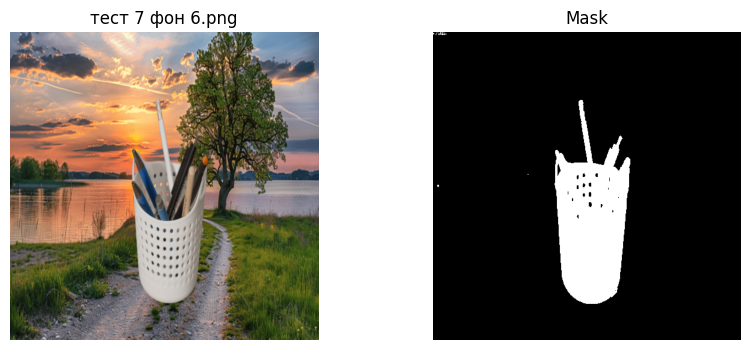

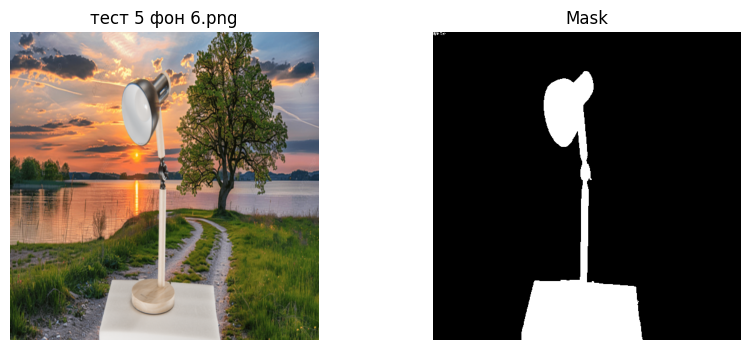

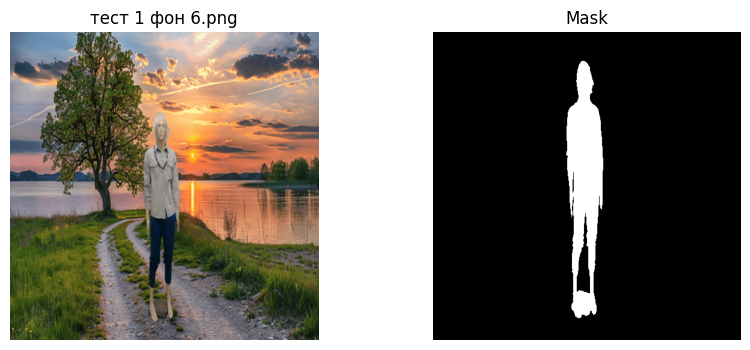

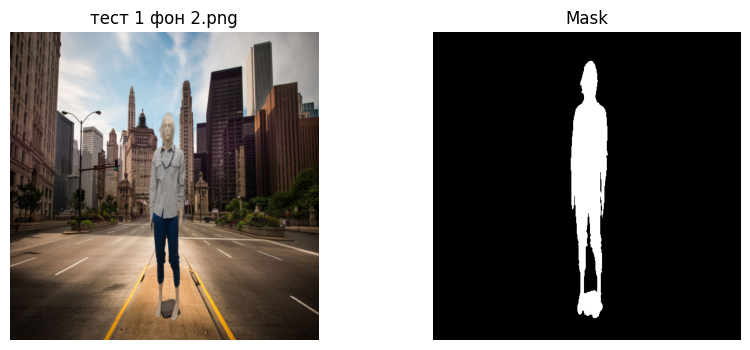

In [ ]:
import matplotlib.pyplot as plt

images, masks, names = next(iter(train_loader))

for i in range(min(4, len(images))):
    image = images[i].permute(1, 2, 0).numpy()
    mask = masks[i, 0].numpy()

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title(names[i])
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="gray")
    plt.title("Mask")
    plt.axis("off")

    plt.show()

In [ ]:
import torch
import torch.nn as nn
from torchvision.models.segmentation import fcn_resnet50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# FCN-ResNet50 as U-Net baseline replacement if torchvision lacks UNet
# We will replace this with a real U-Net in the next cell.

try:
    import segmentation_models_pytorch as smp
except ImportError:
    !pip -q install segmentation-models-pytorch
    import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

model = model.to(device)

print(model.__class__.__name__)
print("Trainable parameters:",
      sum(p.numel() for p in model.parameters() if p.requires_grad))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 13.1 MB/s eta 0:00:00


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Unet
Trainable parameters: 24436369


In [ ]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

# =========================
# SETTINGS
# =========================
EPOCHS = 50
LEARNING_RATE = 1e-4

SAVE_DIR = "/content/unet_results"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(SAVE_DIR, "unet_best.pth")

# =========================
# LOSS AND OPTIMIZER
# =========================
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

# =========================
# METRICS
# =========================
def dice_score(logits, masks, threshold=0.5, eps=1e-7):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()

    intersection = (predictions * masks).sum(dim=(1, 2, 3))
    denominator = predictions.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))

    dice = (2.0 * intersection + eps) / (denominator + eps)
    return dice.mean()


def iou_score(logits, masks, threshold=0.5, eps=1e-7):
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities > threshold).float()

    intersection = (predictions * masks).sum(dim=(1, 2, 3))

    union = (
        predictions.sum(dim=(1, 2, 3))
        + masks.sum(dim=(1, 2, 3))
        - intersection
    )

    iou = (intersection + eps) / (union + eps)
    return iou.mean()


# =========================
# HISTORY
# =========================
history = {
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": []
}

best_val_dice = -1.0
training_start_time = time.time()

# =========================
# TRAINING
# =========================
for epoch in range(EPOCHS):

    # -------- TRAIN --------
    model.train()

    train_loss_sum = 0.0

    for images, masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    mean_train_loss = train_loss_sum / len(train_loader)

    # -------- VALIDATION --------
    model.eval()

    val_loss_sum = 0.0
    val_dice_values = []
    val_iou_values = []

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            loss = criterion(logits, masks)

            val_loss_sum += loss.item()

            val_dice_values.append(
                dice_score(logits, masks).item()
            )

            val_iou_values.append(
                iou_score(logits, masks).item()
            )

    mean_val_loss = val_loss_sum / len(val_loader)
    mean_val_dice = float(np.mean(val_dice_values))
    mean_val_iou = float(np.mean(val_iou_values))

    scheduler.step(mean_val_dice)

    history["train_loss"].append(mean_train_loss)
    history["val_loss"].append(mean_val_loss)
    history["val_dice"].append(mean_val_dice)
    history["val_iou"].append(mean_val_iou)

    current_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train Loss: {mean_train_loss:.4f} | "
        f"Val Loss: {mean_val_loss:.4f} | "
        f"Val Dice: {mean_val_dice:.4f} | "
        f"Val IoU: {mean_val_iou:.4f} | "
        f"LR: {current_lr:.2e}"
    )

    # Save the best model
    if mean_val_dice > best_val_dice:

        best_val_dice = mean_val_dice

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_dice": best_val_dice,
                "history": history
            },
            BEST_MODEL_PATH
        )

        print(
            f"Best model saved: Val Dice = {best_val_dice:.4f}"
        )

training_time = time.time() - training_start_time

print("\nU-Net training completed.")
print(f"Best validation Dice: {best_val_dice:.4f}")
print(f"Training time: {training_time / 60:.2f} minutes")
print(f"Best model: {BEST_MODEL_PATH}")

ValueError: too many values to unpack (expected 2)

In [ ]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# SETTINGS
# ============================================================

EPOCHS = 50
LEARNING_RATE = 1e-4
THRESHOLD = 0.5
EARLY_STOPPING_PATIENCE = 10

SAVE_DIR = "/content/unet_results"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "unet_resnet34_best.pth"
)

HISTORY_PATH = os.path.join(
    SAVE_DIR,
    "unet_training_history.npz"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# CREATE U-NET
# ============================================================

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model: U-Net")
print("Encoder: ResNet-34")
print("Trainable parameters:", trainable_parameters)


# ============================================================
# LOSS, OPTIMIZER AND SCHEDULER
# ============================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-7
)


# ============================================================
# BATCH EXTRACTION
# ============================================================

def extract_images_and_masks(batch):
    """
    Supports loaders returning:

        image, mask

    or:

        image, mask, filename

    or other additional metadata.

    It also supports dictionary batches.
    """

    if isinstance(batch, dict):

        possible_image_keys = [
            "image",
            "images",
            "input",
            "inputs"
        ]

        possible_mask_keys = [
            "mask",
            "masks",
            "target",
            "targets"
        ]

        images = None
        masks = None

        for key in possible_image_keys:
            if key in batch:
                images = batch[key]
                break

        for key in possible_mask_keys:
            if key in batch:
                masks = batch[key]
                break

        if images is None or masks is None:
            raise ValueError(
                "Dictionary batch does not contain recognised "
                "image and mask keys."
            )

        return images, masks

    if isinstance(batch, (list, tuple)):

        if len(batch) < 2:
            raise ValueError(
                "Each batch must contain at least images and masks."
            )

        return batch[0], batch[1]

    raise TypeError(
        f"Unsupported batch type: {type(batch)}"
    )


# ============================================================
# OUTPUT EXTRACTION
# ============================================================

def extract_logits(model_output):
    """
    Handles a direct tensor output and common dictionary outputs.
    """

    if torch.is_tensor(model_output):
        return model_output

    if isinstance(model_output, dict):

        if "out" in model_output:
            return model_output["out"]

        if "logits" in model_output:
            return model_output["logits"]

    if isinstance(model_output, (list, tuple)):

        if len(model_output) == 0:
            raise ValueError("The model returned an empty output.")

        if torch.is_tensor(model_output[0]):
            return model_output[0]

    raise TypeError(
        f"Unsupported model output type: {type(model_output)}"
    )


# ============================================================
# METRIC ACCUMULATOR
# ============================================================

def segmentation_counts(logits, masks, threshold=0.5):
    """
    Returns per-image intersection, predicted area,
    target area and union.
    """

    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= threshold).float()
    masks = (masks >= 0.5).float()

    intersection = (
        predictions * masks
    ).sum(dim=(1, 2, 3))

    predicted_area = predictions.sum(
        dim=(1, 2, 3)
    )

    target_area = masks.sum(
        dim=(1, 2, 3)
    )

    union = (
        predicted_area
        + target_area
        - intersection
    )

    return (
        intersection,
        predicted_area,
        target_area,
        union
    )


def calculate_batch_metrics(
    logits,
    masks,
    threshold=0.5,
    eps=1e-7
):
    intersection, predicted_area, target_area, union = (
        segmentation_counts(
            logits,
            masks,
            threshold
        )
    )

    dice_values = (
        2.0 * intersection + eps
    ) / (
        predicted_area + target_area + eps
    )

    iou_values = (
        intersection + eps
    ) / (
        union + eps
    )

    return dice_values, iou_values


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    total_samples = 0

    for batch in loader:

        images, masks = extract_images_and_masks(batch)

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        masks = masks.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = (masks >= 0.5).float()

        optimizer.zero_grad(set_to_none=True)

        model_output = model(images)
        logits = extract_logits(model_output)

        if logits.shape != masks.shape:
            raise ValueError(
                "Prediction and mask dimensions do not match.\n"
                f"Prediction shape: {logits.shape}\n"
                f"Mask shape: {masks.shape}"
            )

        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size

    if total_samples == 0:
        raise ValueError("The training loader is empty.")

    mean_loss = running_loss / total_samples

    return mean_loss


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
    threshold=0.5
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_dice_values = []
    all_iou_values = []

    with torch.no_grad():

        for batch in loader:

            images, masks = extract_images_and_masks(batch)

            images = images.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            masks = masks.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            if masks.ndim == 3:
                masks = masks.unsqueeze(1)

            masks = (masks >= 0.5).float()

            model_output = model(images)
            logits = extract_logits(model_output)

            if logits.shape != masks.shape:
                raise ValueError(
                    "Prediction and mask dimensions do not match.\n"
                    f"Prediction shape: {logits.shape}\n"
                    f"Mask shape: {masks.shape}"
                )

            loss = criterion(logits, masks)

            batch_size = images.size(0)

            running_loss += loss.item() * batch_size
            total_samples += batch_size

            dice_values, iou_values = calculate_batch_metrics(
                logits,
                masks,
                threshold=threshold
            )

            all_dice_values.extend(
                dice_values.detach().cpu().tolist()
            )

            all_iou_values.extend(
                iou_values.detach().cpu().tolist()
            )

    if total_samples == 0:
        raise ValueError("The validation loader is empty.")

    mean_loss = running_loss / total_samples
    mean_dice = float(np.mean(all_dice_values))
    mean_iou = float(np.mean(all_iou_values))

    return mean_loss, mean_dice, mean_iou


# ============================================================
# HISTORY
# ============================================================

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "learning_rate": []
}

best_val_dice = -1.0
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.time()


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(1, EPOCHS + 1):

    epoch_start_time = time.time()

    mean_train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    (
        mean_val_loss,
        mean_val_dice,
        mean_val_iou
    ) = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        threshold=THRESHOLD
    )

    scheduler.step(mean_val_dice)

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_time = time.time() - epoch_start_time

    history["epoch"].append(epoch)
    history["train_loss"].append(mean_train_loss)
    history["val_loss"].append(mean_val_loss)
    history["val_dice"].append(mean_val_dice)
    history["val_iou"].append(mean_val_iou)
    history["learning_rate"].append(
        current_learning_rate
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {mean_train_loss:.6f} | "
        f"Val Loss: {mean_val_loss:.6f} | "
        f"Val Dice: {mean_val_dice:.6f} | "
        f"Val IoU: {mean_val_iou:.6f} | "
        f"LR: {current_learning_rate:.2e} | "
        f"Time: {epoch_time:.1f} s"
    )

    if mean_val_dice > best_val_dice:

        best_val_dice = mean_val_dice
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "epoch": epoch,
            "model_name": "U-Net",
            "encoder_name": "resnet34",
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_val_dice": best_val_dice,
            "val_iou": mean_val_iou,
            "val_loss": mean_val_loss,
            "threshold": THRESHOLD,
            "image_size": 512,
            "history": history
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        print(
            f"  Best checkpoint saved | "
            f"Epoch: {best_epoch} | "
            f"Dice: {best_val_dice:.6f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"  No improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    np.savez(
        HISTORY_PATH,
        epoch=np.array(history["epoch"]),
        train_loss=np.array(history["train_loss"]),
        val_loss=np.array(history["val_loss"]),
        val_dice=np.array(history["val_dice"]),
        val_iou=np.array(history["val_iou"]),
        learning_rate=np.array(
            history["learning_rate"]
        )
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping activated."
        )
        break


# ============================================================
# FINISHED
# ============================================================

training_time_seconds = (
    time.time() - training_start_time
)

training_time_minutes = (
    training_time_seconds / 60.0
)

print("\n==========================================")
print("U-Net training completed")
print("==========================================")
print(f"Best epoch: {best_epoch}")
print(
    f"Best validation Dice: "
    f"{best_val_dice:.6f}"
)
print(
    f"Training time: "
    f"{training_time_minutes:.2f} minutes"
)
print(f"Best checkpoint: {BEST_MODEL_PATH}")
print(f"Training history: {HISTORY_PATH}")
print("==========================================")

Device: cuda
Model: U-Net
Encoder: ResNet-34
Trainable parameters: 24436369
Epoch 01/50 | Train Loss: 0.723831 | Val Loss: 1.273527 | Val Dice: 0.274264 | Val IoU: 0.170369 | LR: 1.00e-04 | Time: 7.2 s
  Best checkpoint saved | Epoch: 1 | Dice: 0.274264
Epoch 02/50 | Train Loss: 0.502134 | Val Loss: 0.965818 | Val Dice: 0.363696 | Val IoU: 0.235484 | LR: 1.00e-04 | Time: 5.4 s
  Best checkpoint saved | Epoch: 2 | Dice: 0.363696
Epoch 03/50 | Train Loss: 0.464273 | Val Loss: 0.545071 | Val Dice: 0.558121 | Val IoU: 0.403317 | LR: 1.00e-04 | Time: 6.5 s
  Best checkpoint saved | Epoch: 3 | Dice: 0.558121
Epoch 04/50 | Train Loss: 0.414868 | Val Loss: 0.407794 | Val Dice: 0.627839 | Val IoU: 0.486809 | LR: 1.00e-04 | Time: 5.4 s
  Best checkpoint saved | Epoch: 4 | Dice: 0.627839
Epoch 05/50 | Train Loss: 0.381086 | Val Loss: 0.368406 | Val Dice: 0.656552 | Val IoU: 0.513157 | LR: 1.00e-04 | Time: 6.2 s
  Best checkpoint saved | Epoch: 5 | Dice: 0.656552
Epoch 06/50 | Train Loss: 0.366414

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import torch

# ============================================================
# SETTINGS
# ============================================================

CHECKPOINT_PATH = "/content/unet_results/unet_resnet34_best.pth"
THRESHOLD = 0.5

TEST_RESULTS_DIR = "/content/unet_results/test_evaluation"
os.makedirs(TEST_RESULTS_DIR, exist_ok=True)

TEST_CSV_PATH = os.path.join(
    TEST_RESULTS_DIR,
    "unet_test_metrics.csv"
)

SUMMARY_CSV_PATH = os.path.join(
    TEST_RESULTS_DIR,
    "unet_test_summary.csv"
)


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best checkpoint loaded.")
print("Checkpoint epoch:", checkpoint["epoch"])
print(
    "Checkpoint validation Dice:",
    checkpoint["best_val_dice"]
)


# ============================================================
# TEST METRIC FUNCTION
# ============================================================

def calculate_test_metrics(
    logits,
    masks,
    threshold=0.5,
    eps=1e-7
):
    probabilities = torch.sigmoid(logits)
    predictions = (
        probabilities >= threshold
    ).float()

    masks = (masks >= 0.5).float()

    intersection = (
        predictions * masks
    ).sum(dim=(1, 2, 3))

    predicted_area = predictions.sum(
        dim=(1, 2, 3)
    )

    target_area = masks.sum(
        dim=(1, 2, 3)
    )

    union = (
        predicted_area
        + target_area
        - intersection
    )

    dice = (
        2.0 * intersection + eps
    ) / (
        predicted_area + target_area + eps
    )

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    mse = torch.mean(
        (
            probabilities - masks
        ) ** 2,
        dim=(1, 2, 3)
    )

    psnr = 10.0 * torch.log10(
        1.0 / torch.clamp(mse, min=eps)
    )

    return predictions, dice, iou, psnr


# ============================================================
# TEST EVALUATION
# ============================================================

test_rows = []

total_inference_time = 0.0
total_images = 0
global_image_index = 0

model.eval()

with torch.no_grad():

    for batch_index, batch in enumerate(test_loader):

        images, masks = extract_images_and_masks(batch)

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        masks = masks.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = (masks >= 0.5).float()

        if device.type == "cuda":
            torch.cuda.synchronize()

        inference_start = time.perf_counter()

        model_output = model(images)
        logits = extract_logits(model_output)

        if device.type == "cuda":
            torch.cuda.synchronize()

        batch_inference_time = (
            time.perf_counter() - inference_start
        )

        batch_size = images.size(0)

        total_inference_time += batch_inference_time
        total_images += batch_size

        (
            predictions,
            dice_values,
            iou_values,
            psnr_values
        ) = calculate_test_metrics(
            logits,
            masks,
            threshold=THRESHOLD
        )

        average_time_per_image = (
            batch_inference_time / batch_size
        )

        dice_values = (
            dice_values.detach().cpu().numpy()
        )

        iou_values = (
            iou_values.detach().cpu().numpy()
        )

        psnr_values = (
            psnr_values.detach().cpu().numpy()
        )

        for sample_index in range(batch_size):

            test_rows.append(
                {
                    "image_index": global_image_index,
                    "batch_index": batch_index,
                    "dice": float(
                        dice_values[sample_index]
                    ),
                    "iou": float(
                        iou_values[sample_index]
                    ),
                    "psnr_db": float(
                        psnr_values[sample_index]
                    ),
                    "inference_time_seconds":
                        average_time_per_image,
                    "inference_time_ms":
                        average_time_per_image * 1000.0
                }
            )

            global_image_index += 1


# ============================================================
# SAVE INDIVIDUAL RESULTS
# ============================================================

test_dataframe = pd.DataFrame(test_rows)

test_dataframe.to_csv(
    TEST_CSV_PATH,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

mean_dice = test_dataframe["dice"].mean()
std_dice = test_dataframe["dice"].std(ddof=0)

mean_iou = test_dataframe["iou"].mean()
std_iou = test_dataframe["iou"].std(ddof=0)

mean_psnr = test_dataframe["psnr_db"].mean()
std_psnr = test_dataframe["psnr_db"].std(ddof=0)

mean_inference_seconds = (
    total_inference_time / total_images
)

mean_inference_ms = (
    mean_inference_seconds * 1000.0
)

fps = (
    1.0 / mean_inference_seconds
    if mean_inference_seconds > 0
    else float("inf")
)

summary_dataframe = pd.DataFrame(
    [
        {
            "model": "U-Net",
            "encoder": "ResNet-34",
            "test_images": total_images,
            "threshold": THRESHOLD,
            "mean_dice": mean_dice,
            "std_dice": std_dice,
            "mean_iou": mean_iou,
            "std_iou": std_iou,
            "mean_psnr_db": mean_psnr,
            "std_psnr_db": std_psnr,
            "mean_inference_time_seconds":
                mean_inference_seconds,
            "mean_inference_time_ms":
                mean_inference_ms,
            "fps": fps,
            "best_validation_dice":
                checkpoint["best_val_dice"],
            "best_epoch": checkpoint["epoch"]
        }
    ]
)

summary_dataframe.to_csv(
    SUMMARY_CSV_PATH,
    index=False
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n==========================================")
print("U-Net independent test evaluation")
print("==========================================")
print(f"Test images: {total_images}")
print(f"Mean Dice: {mean_dice:.6f}")
print(f"Dice standard deviation: {std_dice:.6f}")
print(f"Mean IoU: {mean_iou:.6f}")
print(f"IoU standard deviation: {std_iou:.6f}")
print(f"Mean PSNR: {mean_psnr:.3f} dB")
print(f"PSNR standard deviation: {std_psnr:.3f} dB")
print(
    f"Mean inference time: "
    f"{mean_inference_ms:.3f} ms/image"
)
print(f"Throughput: {fps:.2f} images/second")
print(f"Individual results: {TEST_CSV_PATH}")
print(f"Summary: {SUMMARY_CSV_PATH}")
print("==========================================")

display(test_dataframe)
display(summary_dataframe)

Best checkpoint loaded.
Checkpoint epoch: 50
Checkpoint validation Dice: 0.8636081985064915

U-Net independent test evaluation
Test images: 7
Mean Dice: 0.847659
Dice standard deviation: 0.116650
Mean IoU: 0.751132
IoU standard deviation: 0.154125
Mean PSNR: 15.558 dB
PSNR standard deviation: 1.024 dB
Mean inference time: 29.051 ms/image
Throughput: 34.42 images/second
Individual results: /content/unet_results/test_evaluation/unet_test_metrics.csv
Summary: /content/unet_results/test_evaluation/unet_test_summary.csv


,image_index,batch_index,dice,iou,psnr_db,inference_time_seconds,inference_time_ms
0,0,0,0.855517,0.747514,16.529768,0.043423,43.422688
1,1,1,0.894458,0.809068,15.993258,0.027623,27.622956
2,2,2,0.909153,0.833438,15.603615,0.026456,26.455841
3,3,3,0.968186,0.938333,16.545637,0.026489,26.488523
4,4,4,0.853343,0.744201,14.854256,0.026442,26.442299
5,5,5,0.575997,0.404492,13.420434,0.026495,26.495324
6,6,6,0.876959,0.780879,15.955770,0.026431,26.430518


,model,encoder,test_images,threshold,mean_dice,std_dice,mean_iou,std_iou,mean_psnr_db,std_psnr_db,mean_inference_time_seconds,mean_inference_time_ms,fps,best_validation_dice,best_epoch
0,U-Net,ResNet-34,7,0.5,0.847659,0.11665,0.751132,0.154125,15.557534,1.023576,0.029051,29.051164,34.422028,0.863608,50


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

# ============================================================
# SETTINGS
# ============================================================

MODEL_NAME = "unet_resnet34"

CHECKPOINT_PATH = "/content/unet_results/unet_resnet34_best.pth"
HISTORY_PATH = "/content/unet_results/unet_training_history.npz"

BASE_DIR = "/content/unet_results"
EXPORT_DIR = os.path.join(BASE_DIR, "complete_results")

PREDICTED_MASK_DIR = os.path.join(
    EXPORT_DIR,
    "predicted_masks"
)

PROBABILITY_MASK_DIR = os.path.join(
    EXPORT_DIR,
    "probability_masks"
)

GROUND_TRUTH_DIR = os.path.join(
    EXPORT_DIR,
    "ground_truth_masks"
)

ORIGINAL_IMAGE_DIR = os.path.join(
    EXPORT_DIR,
    "original_images"
)

ERROR_MAP_DIR = os.path.join(
    EXPORT_DIR,
    "error_maps"
)

OVERLAY_DIR = os.path.join(
    EXPORT_DIR,
    "overlays"
)

COMPARISON_DIR = os.path.join(
    EXPORT_DIR,
    "comparison_figures"
)

PLOTS_DIR = os.path.join(
    EXPORT_DIR,
    "training_plots"
)

for directory in [
    EXPORT_DIR,
    PREDICTED_MASK_DIR,
    PROBABILITY_MASK_DIR,
    GROUND_TRUTH_DIR,
    ORIGINAL_IMAGE_DIR,
    ERROR_MAP_DIR,
    OVERLAY_DIR,
    COMPARISON_DIR,
    PLOTS_DIR
]:
    os.makedirs(directory, exist_ok=True)

THRESHOLD = 0.5


# ============================================================
# LOAD BEST MODEL
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best U-Net checkpoint loaded.")
print("Epoch:", checkpoint["epoch"])
print(
    "Validation Dice:",
    checkpoint["best_val_dice"]
)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def extract_optional_metadata(batch):
    """
    Returns additional batch information when it exists.
    """

    if isinstance(batch, (list, tuple)):

        if len(batch) > 2:
            return batch[2]

    if isinstance(batch, dict):

        for key in [
            "filename",
            "filenames",
            "name",
            "names",
            "path",
            "paths"
        ]:
            if key in batch:
                return batch[key]

    return None


def make_safe_filename(metadata, sample_index, global_index):

    default_name = f"test_{global_index:03d}"

    if metadata is None:
        return default_name

    try:
        if isinstance(metadata, (list, tuple)):
            value = metadata[sample_index]
        else:
            value = metadata

        value = str(value)

        basename = os.path.basename(value)
        basename = os.path.splitext(basename)[0]

        safe_name = "".join(
            character
            if character.isalnum() or character in "-_"
            else "_"
            for character in basename
        )

        if safe_name.strip("_") == "":
            return default_name

        return f"{global_index:03d}_{safe_name}"

    except Exception:
        return default_name


def tensor_image_to_numpy(image_tensor):
    """
    Converts CHW tensor to HWC NumPy array.

    The loader may contain normalised images. Therefore this
    function rescales each image to [0, 1] for visualisation.
    """

    image = image_tensor.detach().cpu().float().numpy()

    if image.ndim == 3:
        image = np.transpose(image, (1, 2, 0))

    image_min = image.min()
    image_max = image.max()

    if image_max > image_min:
        image = (
            image - image_min
        ) / (
            image_max - image_min
        )
    else:
        image = np.zeros_like(image)

    return np.clip(image, 0.0, 1.0)


def save_grayscale_png(array, path):

    array = np.asarray(array)

    array_uint8 = np.clip(
        array * 255.0,
        0,
        255
    ).astype(np.uint8)

    Image.fromarray(
        array_uint8,
        mode="L"
    ).save(path)


def save_rgb_png(array, path):

    array = np.asarray(array)

    array_uint8 = np.clip(
        array * 255.0,
        0,
        255
    ).astype(np.uint8)

    Image.fromarray(
        array_uint8,
        mode="RGB"
    ).save(path)


def calculate_metrics_per_image(
    probability,
    prediction,
    target,
    eps=1e-7
):
    probability = probability.astype(np.float32)
    prediction = prediction.astype(np.float32)
    target = target.astype(np.float32)

    intersection = np.sum(
        prediction * target
    )

    predicted_area = np.sum(prediction)
    target_area = np.sum(target)

    union = (
        predicted_area
        + target_area
        - intersection
    )

    dice = (
        2.0 * intersection + eps
    ) / (
        predicted_area + target_area + eps
    )

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    mse = np.mean(
        (probability - target) ** 2
    )

    psnr = 10.0 * np.log10(
        1.0 / max(mse, eps)
    )

    false_positive = np.logical_and(
        prediction == 1,
        target == 0
    )

    false_negative = np.logical_and(
        prediction == 0,
        target == 1
    )

    true_positive = np.logical_and(
        prediction == 1,
        target == 1
    )

    true_negative = np.logical_and(
        prediction == 0,
        target == 0
    )

    fp_pixels = int(false_positive.sum())
    fn_pixels = int(false_negative.sum())
    tp_pixels = int(true_positive.sum())
    tn_pixels = int(true_negative.sum())

    precision = (
        tp_pixels
        / max(tp_pixels + fp_pixels, 1)
    )

    recall = (
        tp_pixels
        / max(tp_pixels + fn_pixels, 1)
    )

    accuracy = (
        tp_pixels + tn_pixels
    ) / max(
        tp_pixels
        + tn_pixels
        + fp_pixels
        + fn_pixels,
        1
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "psnr_db": float(psnr),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy": float(accuracy),
        "true_positive_pixels": tp_pixels,
        "true_negative_pixels": tn_pixels,
        "false_positive_pixels": fp_pixels,
        "false_negative_pixels": fn_pixels
    }


def create_error_map(prediction, target):
    """
    RGB error map:

    black = correct background
    white = correct foreground
    red   = false positive
    blue  = false negative
    """

    prediction = prediction.astype(bool)
    target = target.astype(bool)

    height, width = prediction.shape

    error_map = np.zeros(
        (height, width, 3),
        dtype=np.float32
    )

    true_positive = np.logical_and(
        prediction,
        target
    )

    false_positive = np.logical_and(
        prediction,
        np.logical_not(target)
    )

    false_negative = np.logical_and(
        np.logical_not(prediction),
        target
    )

    error_map[true_positive] = [1.0, 1.0, 1.0]
    error_map[false_positive] = [1.0, 0.0, 0.0]
    error_map[false_negative] = [0.0, 0.0, 1.0]

    return error_map


def create_overlay(image, prediction):

    overlay = image.copy()

    mask = prediction.astype(bool)

    overlay_colour = np.zeros_like(overlay)
    overlay_colour[..., 1] = 1.0

    alpha = 0.45

    overlay[mask] = (
        (1.0 - alpha) * overlay[mask]
        + alpha * overlay_colour[mask]
    )

    return np.clip(overlay, 0.0, 1.0)


# ============================================================
# RUN TEST SET AND SAVE EVERYTHING
# ============================================================

result_rows = []
global_index = 0

model.eval()

with torch.no_grad():

    for batch_index, batch in enumerate(test_loader):

        images, masks = extract_images_and_masks(batch)
        metadata = extract_optional_metadata(batch)

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        masks = masks.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = (masks >= 0.5).float()

        model_output = model(images)
        logits = extract_logits(model_output)

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= THRESHOLD
        ).float()

        batch_size = images.size(0)

        for sample_index in range(batch_size):

            filename = make_safe_filename(
                metadata=metadata,
                sample_index=sample_index,
                global_index=global_index
            )

            original_image = tensor_image_to_numpy(
                images[sample_index]
            )

            target_mask = (
                masks[sample_index, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            probability_mask = (
                probabilities[sample_index, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            predicted_mask = (
                predictions[sample_index, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            metrics = calculate_metrics_per_image(
                probability=probability_mask,
                prediction=predicted_mask,
                target=target_mask
            )

            error_map = create_error_map(
                prediction=predicted_mask,
                target=target_mask
            )

            overlay = create_overlay(
                image=original_image,
                prediction=predicted_mask
            )

            original_path = os.path.join(
                ORIGINAL_IMAGE_DIR,
                f"{filename}_image.png"
            )

            target_path = os.path.join(
                GROUND_TRUTH_DIR,
                f"{filename}_ground_truth.png"
            )

            prediction_path = os.path.join(
                PREDICTED_MASK_DIR,
                f"{filename}_prediction.png"
            )

            probability_path = os.path.join(
                PROBABILITY_MASK_DIR,
                f"{filename}_probability.png"
            )

            error_path = os.path.join(
                ERROR_MAP_DIR,
                f"{filename}_error_map.png"
            )

            overlay_path = os.path.join(
                OVERLAY_DIR,
                f"{filename}_overlay.png"
            )

            comparison_path = os.path.join(
                COMPARISON_DIR,
                f"{filename}_comparison.png"
            )

            save_rgb_png(
                original_image,
                original_path
            )

            save_grayscale_png(
                target_mask,
                target_path
            )

            save_grayscale_png(
                predicted_mask,
                prediction_path
            )

            save_grayscale_png(
                probability_mask,
                probability_path
            )

            save_rgb_png(
                error_map,
                error_path
            )

            save_rgb_png(
                overlay,
                overlay_path
            )

            # ------------------------------------------------
            # COMPARISON FIGURE
            # ------------------------------------------------

            figure = plt.figure(
                figsize=(20, 4.5)
            )

            axis_1 = figure.add_subplot(1, 5, 1)
            axis_1.imshow(original_image)
            axis_1.set_title("Original image")
            axis_1.axis("off")

            axis_2 = figure.add_subplot(1, 5, 2)
            axis_2.imshow(
                target_mask,
                cmap="gray",
                vmin=0,
                vmax=1
            )
            axis_2.set_title("Ground truth")
            axis_2.axis("off")

            axis_3 = figure.add_subplot(1, 5, 3)
            axis_3.imshow(
                predicted_mask,
                cmap="gray",
                vmin=0,
                vmax=1
            )
            axis_3.set_title(
                f"Prediction\n"
                f"Dice={metrics['dice']:.3f}, "
                f"IoU={metrics['iou']:.3f}"
            )
            axis_3.axis("off")

            axis_4 = figure.add_subplot(1, 5, 4)
            axis_4.imshow(error_map)
            axis_4.set_title(
                "Error map\n"
                "Red: FP, Blue: FN"
            )
            axis_4.axis("off")

            axis_5 = figure.add_subplot(1, 5, 5)
            axis_5.imshow(overlay)
            axis_5.set_title("Prediction overlay")
            axis_5.axis("off")

            figure.suptitle(
                f"U-Net ResNet-34 — {filename}",
                fontsize=14
            )

            figure.tight_layout()

            figure.savefig(
                comparison_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.close(figure)

            result_row = {
                "image_index": global_index,
                "filename": filename,
                "model": "U-Net",
                "encoder": "ResNet-34",
                "threshold": THRESHOLD,
                **metrics,
                "original_image_path": original_path,
                "ground_truth_path": target_path,
                "prediction_path": prediction_path,
                "probability_path": probability_path,
                "error_map_path": error_path,
                "overlay_path": overlay_path,
                "comparison_figure_path": comparison_path
            }

            result_rows.append(result_row)

            print(
                f"Saved {filename} | "
                f"Dice: {metrics['dice']:.4f} | "
                f"IoU: {metrics['iou']:.4f}"
            )

            global_index += 1


# ============================================================
# SAVE TEST METRICS
# ============================================================

results_dataframe = pd.DataFrame(
    result_rows
)

DETAILED_METRICS_PATH = os.path.join(
    EXPORT_DIR,
    "unet_detailed_test_metrics.csv"
)

results_dataframe.to_csv(
    DETAILED_METRICS_PATH,
    index=False
)


# ============================================================
# SAVE SUMMARY
# ============================================================

summary_dataframe = pd.DataFrame(
    [
        {
            "model": "U-Net",
            "encoder": "ResNet-34",
            "best_epoch": checkpoint["epoch"],
            "best_validation_dice":
                checkpoint["best_val_dice"],
            "test_images":
                len(results_dataframe),
            "mean_test_dice":
                results_dataframe["dice"].mean(),
            "std_test_dice":
                results_dataframe["dice"].std(
                    ddof=0
                ),
            "median_test_dice":
                results_dataframe["dice"].median(),
            "minimum_test_dice":
                results_dataframe["dice"].min(),
            "maximum_test_dice":
                results_dataframe["dice"].max(),
            "mean_test_iou":
                results_dataframe["iou"].mean(),
            "std_test_iou":
                results_dataframe["iou"].std(
                    ddof=0
                ),
            "mean_test_psnr_db":
                results_dataframe["psnr_db"].mean(),
            "std_test_psnr_db":
                results_dataframe["psnr_db"].std(
                    ddof=0
                ),
            "mean_precision":
                results_dataframe["precision"].mean(),
            "mean_recall":
                results_dataframe["recall"].mean(),
            "mean_pixel_accuracy":
                results_dataframe[
                    "pixel_accuracy"
                ].mean()
        }
    ]
)

SUMMARY_PATH = os.path.join(
    EXPORT_DIR,
    "unet_complete_summary.csv"
)

summary_dataframe.to_csv(
    SUMMARY_PATH,
    index=False
)


# ============================================================
# TRAINING CURVES
# ============================================================

history_data = np.load(HISTORY_PATH)

epochs = history_data["epoch"]
train_loss = history_data["train_loss"]
val_loss = history_data["val_loss"]
val_dice = history_data["val_dice"]
val_iou = history_data["val_iou"]
learning_rate = history_data["learning_rate"]

# Loss plot
plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_loss,
    label="Training loss"
)

plt.plot(
    epochs,
    val_loss,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("U-Net training and validation loss")
plt.legend()
plt.grid(True)
plt.tight_layout()

LOSS_PLOT_PATH = os.path.join(
    PLOTS_DIR,
    "unet_loss_curve.png"
)

plt.savefig(
    LOSS_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Dice and IoU plot
plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    val_dice,
    label="Validation Dice"
)

plt.plot(
    epochs,
    val_iou,
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("U-Net validation segmentation metrics")
plt.legend()
plt.grid(True)
plt.tight_layout()

METRIC_PLOT_PATH = os.path.join(
    PLOTS_DIR,
    "unet_validation_metrics.png"
)

plt.savefig(
    METRIC_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Learning-rate plot
plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    learning_rate
)

plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("U-Net learning-rate schedule")
plt.grid(True)
plt.tight_layout()

LR_PLOT_PATH = os.path.join(
    PLOTS_DIR,
    "unet_learning_rate.png"
)

plt.savefig(
    LR_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# Per-image metrics plot
plt.figure(figsize=(9, 5))

x_positions = np.arange(
    len(results_dataframe)
)

plt.plot(
    x_positions,
    results_dataframe["dice"],
    marker="o",
    label="Dice"
)

plt.plot(
    x_positions,
    results_dataframe["iou"],
    marker="o",
    label="IoU"
)

plt.xticks(
    x_positions,
    results_dataframe["image_index"]
)

plt.xlabel("Test image index")
plt.ylabel("Score")
plt.title("U-Net per-image test results")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()

PER_IMAGE_PLOT_PATH = os.path.join(
    PLOTS_DIR,
    "unet_per_image_metrics.png"
)

plt.savefig(
    PER_IMAGE_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# COPY MODEL AND ORIGINAL TEST FILES
# ============================================================

MODEL_COPY_PATH = os.path.join(
    EXPORT_DIR,
    "unet_resnet34_best.pth"
)

shutil.copy2(
    CHECKPOINT_PATH,
    MODEL_COPY_PATH
)

HISTORY_COPY_PATH = os.path.join(
    EXPORT_DIR,
    "unet_training_history.npz"
)

shutil.copy2(
    HISTORY_PATH,
    HISTORY_COPY_PATH
)

old_test_metrics = (
    "/content/unet_results/test_evaluation/"
    "unet_test_metrics.csv"
)

old_test_summary = (
    "/content/unet_results/test_evaluation/"
    "unet_test_summary.csv"
)

if os.path.exists(old_test_metrics):
    shutil.copy2(
        old_test_metrics,
        os.path.join(
            EXPORT_DIR,
            "unet_test_metrics_original.csv"
        )
    )

if os.path.exists(old_test_summary):
    shutil.copy2(
        old_test_summary,
        os.path.join(
            EXPORT_DIR,
            "unet_test_summary_original.csv"
        )
    )


# ============================================================
# CREATE README
# ============================================================

README_PATH = os.path.join(
    EXPORT_DIR,
    "README.txt"
)

with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as readme_file:

    readme_file.write(
        "U-Net ResNet-34 segmentation results\n"
        "=====================================\n\n"
        f"Best epoch: {checkpoint['epoch']}\n"
        f"Best validation Dice: "
        f"{checkpoint['best_val_dice']:.6f}\n"
        f"Test images: {len(results_dataframe)}\n"
        f"Mean test Dice: "
        f"{results_dataframe['dice'].mean():.6f}\n"
        f"Mean test IoU: "
        f"{results_dataframe['iou'].mean():.6f}\n"
        f"Mean test PSNR: "
        f"{results_dataframe['psnr_db'].mean():.3f} dB\n\n"
        "Error-map colours:\n"
        "- Black: correct background\n"
        "- White: correct foreground\n"
        "- Red: false positive\n"
        "- Blue: false negative\n"
    )


# ============================================================
# CREATE ZIP ARCHIVE
# ============================================================

ZIP_BASE_PATH = "/content/unet_complete_results"

ZIP_PATH = shutil.make_archive(
    ZIP_BASE_PATH,
    "zip",
    root_dir=EXPORT_DIR
)


# ============================================================
# FINISHED
# ============================================================

print("\n==========================================")
print("ALL U-NET RESULTS SAVED")
print("==========================================")
print(f"Results directory: {EXPORT_DIR}")
print(f"Detailed metrics: {DETAILED_METRICS_PATH}")
print(f"Summary: {SUMMARY_PATH}")
print(f"Model checkpoint: {MODEL_COPY_PATH}")
print(f"Training history: {HISTORY_COPY_PATH}")
print(f"ZIP archive: {ZIP_PATH}")
print("==========================================")

display(results_dataframe)
display(summary_dataframe)

Best U-Net checkpoint loaded.
Epoch: 50
Validation Dice: 0.8636081985064915


/tmp/ipykernel_664/1987570095.py:220: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(
/tmp/ipykernel_664/1987570095.py:204: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  Image.fromarray(


Saved 000_тест_1_фон_9 | Dice: 0.8555 | IoU: 0.7475
Saved 001_тест_2_фон_9 | Dice: 0.8945 | IoU: 0.8091
Saved 002_тест_3_фон_9 | Dice: 0.9092 | IoU: 0.8334
Saved 003_тест_4_фон_9 | Dice: 0.9682 | IoU: 0.9383
Saved 004_тест_5_фон_9 | Dice: 0.8533 | IoU: 0.7442
Saved 005_тест_6_фон_9 | Dice: 0.5760 | IoU: 0.4045
Saved 006_тест_7_фон_9 | Dice: 0.8770 | IoU: 0.7809

ALL U-NET RESULTS SAVED
Results directory: /content/unet_results/complete_results
Detailed metrics: /content/unet_results/complete_results/unet_detailed_test_metrics.csv
Summary: /content/unet_results/complete_results/unet_complete_summary.csv
Model checkpoint: /content/unet_results/complete_results/unet_resnet34_best.pth
Training history: /content/unet_results/complete_results/unet_training_history.npz
ZIP archive: /content/unet_complete_results.zip


,image_index,filename,model,encoder,threshold,dice,iou,psnr_db,precision,recall,...,true_negative_pixels,false_positive_pixels,false_negative_pixels,original_image_path,ground_truth_path,prediction_path,probability_path,error_map_path,overlay_path,comparison_figure_path
0,0,000_тест_1_фон_9,U-Net,ResNet-34,0.5,0.855517,0.747514,16.529768,0.782336,0.943801,...,241430,4308,922,/content/unet_results/complete_results/origina...,/content/unet_results/complete_results/ground_...,/content/unet_results/complete_results/predict...,/content/unet_results/complete_results/probabi...,/content/unet_results/complete_results/error_m...,/content/unet_results/complete_results/overlay...,/content/unet_results/complete_results/compari...
1,1,001_тест_2_фон_9,U-Net,ResNet-34,0.5,0.894458,0.809068,15.993259,0.860833,0.930818,...,228818,4359,2004,/content/unet_results/complete_results/origina...,/content/unet_results/complete_results/ground_...,/content/unet_results/complete_results/predict...,/content/unet_results/complete_results/probabi...,/content/unet_results/complete_results/error_m...,/content/unet_results/complete_results/overlay...,/content/unet_results/complete_results/compari...
2,2,002_тест_3_фон_9,U-Net,ResNet-34,0.5,0.909153,0.833438,15.603615,0.910400,0.907910,...,217548,3658,3770,/content/unet_results/complete_results/origina...,/content/unet_results/complete_results/ground_...,/content/unet_results/complete_results/predict...,/content/unet_results/complete_results/probabi...,/content/unet_results/complete_results/error_m...,/content/unet_results/complete_results/overlay...,/content/unet_results/complete_results/compari...
3,3,003_тест_4_фон_9,U-Net,ResNet-34,0.5,0.968186,0.938333,16.545637,0.941683,0.996224,...,147998,6633,406,/content/unet_results/complete_results/origina...,/content/unet_results/complete_results/ground_...,/content/unet_results/complete_results/predict...,/content/unet_results/complete_results/probabi...,/content/unet_results/complete_results/error_m...,/content/unet_results/complete_results/overlay...,/content/unet_results/complete_results/compari...
4,4,004_тест_5_фон_9,U-Net,ResNet-34,0.5,0.853343,0.744201,14.854258,0.758433,0.975404,...,225588,8665,686,/content/unet_results/complete_results/origina...,/content/unet_results/complete_results/ground_...,/content/unet_results/complete_results/predict...,/content/unet_results/complete_results/probabi...,/content/unet_results/complete_results/error_m...,/content/unet_results/complete_results/overlay...,/content/unet_results/complete_results/compari...
5,5,005_тест_6_фон_9,U-Net,ResNet-34,0.5,0.575997,0.404492,13.420433,0.577583,0.574420,...,240104,6520,6605,/content/unet_results/complete_results/origina...,/content/unet_results/complete_results/ground_...,/content/unet_results/complete_results/predict...,/content/unet_results/complete_results/probabi...,/content/unet_results/complete_results/error_m...,/content/unet_results/complete_results/overlay...,/content/unet_results/complete_results/compari...
6,6,006_тест_7_фон_9,U-Net,ResNet-34,0.5,0.876959,0.780879,15.955771,0.797377,0.974189,...,229760,6426,670,/content/unet_results/complete_results/origina...,/content/unet_results/complete_results/ground_...,/content/unet_results/complete_results/predict...,/content/unet_results/complete_results/probabi...,/content/unet_results/complete_results/error_m...,/content/unet_results/complete_results/overlay...,/content/unet_results/complete_results/compari...


,model,encoder,best_epoch,best_validation_dice,test_images,mean_test_dice,std_test_dice,median_test_dice,minimum_test_dice,maximum_test_dice,mean_test_iou,std_test_iou,mean_test_psnr_db,std_test_psnr_db,mean_precision,mean_recall,mean_pixel_accuracy
0,U-Net,ResNet-34,50,0.863608,7,0.847659,0.11665,0.876959,0.575997,0.968186,0.751132,0.154125,15.557534,1.023576,0.804092,0.900395,0.969683


In [ ]:
import os
from google.colab import files

ZIP_PATH = "/content/unet_complete_results.zip"
RESULTS_DIR = "/content/unet_results/complete_results"

print("ZIP exists:", os.path.exists(ZIP_PATH))
print("ZIP size:", os.path.getsize(ZIP_PATH) / (1024 * 1024), "MB")

print("\nSaved folders and files:")
for root, dirs, filenames in os.walk(RESULTS_DIR):
    level = root.replace(RESULTS_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for filename in filenames:
        print(f"{indent}    {filename}")

files.download(ZIP_PATH)

ZIP exists: True
ZIP size: 280.17575550079346 MB

Saved folders and files:
complete_results/
    unet_resnet34_best.pth
    README.txt
    unet_training_history.npz
    unet_complete_summary.csv
    unet_detailed_test_metrics.csv
    unet_test_summary_original.csv
    unet_test_metrics_original.csv
    probability_masks/
        000_тест_1_фон_9_probability.png
        003_тест_4_фон_9_probability.png
        002_тест_3_фон_9_probability.png
        006_тест_7_фон_9_probability.png
        005_тест_6_фон_9_probability.png
        004_тест_5_фон_9_probability.png
        001_тест_2_фон_9_probability.png
    ground_truth_masks/
        001_тест_2_фон_9_ground_truth.png
        006_тест_7_фон_9_ground_truth.png
        005_тест_6_фон_9_ground_truth.png
        004_тест_5_фон_9_ground_truth.png
        000_тест_1_фон_9_ground_truth.png
        002_тест_3_фон_9_ground_truth.png
        003_тест_4_фон_9_ground_truth.png
    error_maps/
        004_тест_5_фон_9_error_map.png
        002_тест_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from torch.utils.data import DataLoader

# Keep the same dataset used by the existing loader
train_dataset = train_loader.dataset

TRAIN_BATCH_SIZE = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    drop_last=True
)

print("Training images:", len(train_dataset))
print("Training batch size:", TRAIN_BATCH_SIZE)
print("Number of training batches:", len(train_loader))

first_batch = next(iter(train_loader))
images, masks = extract_images_and_masks(first_batch)

print("First image batch shape:", images.shape)
print("First mask batch shape:", masks.shape)

Training images: 49
Training batch size: 2
Number of training batches: 24
First image batch shape: torch.Size([2, 3, 512, 512])
First mask batch shape: torch.Size([2, 1, 512, 512])


In [ ]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# SETTINGS
# ============================================================

EPOCHS = 50
LEARNING_RATE = 1e-4
THRESHOLD = 0.5
EARLY_STOPPING_PATIENCE = 10

SAVE_DIR = "/content/deeplabv3_results"
os.makedirs(SAVE_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    SAVE_DIR,
    "deeplabv3_resnet34_best.pth"
)

HISTORY_PATH = os.path.join(
    SAVE_DIR,
    "deeplabv3_training_history.npz"
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# CREATE DEEPLABV3
# ============================================================

model = smp.DeepLabV3(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
).to(device)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Model: DeepLabV3")
print("Encoder: ResNet-34")
print("Trainable parameters:", trainable_parameters)


# ============================================================
# LOSS, OPTIMIZER AND SCHEDULER
# ============================================================

criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
    min_lr=1e-7
)


# ============================================================
# BATCH EXTRACTION
# ============================================================

def extract_images_and_masks(batch):
    """
    Supports loaders returning:

        image, mask

    or:

        image, mask, filename

    or dictionaries containing images and masks.
    """

    if isinstance(batch, dict):

        possible_image_keys = [
            "image",
            "images",
            "input",
            "inputs"
        ]

        possible_mask_keys = [
            "mask",
            "masks",
            "target",
            "targets"
        ]

        images = None
        masks = None

        for key in possible_image_keys:
            if key in batch:
                images = batch[key]
                break

        for key in possible_mask_keys:
            if key in batch:
                masks = batch[key]
                break

        if images is None or masks is None:
            raise ValueError(
                "Dictionary batch does not contain recognised "
                "image and mask keys."
            )

        return images, masks

    if isinstance(batch, (list, tuple)):

        if len(batch) < 2:
            raise ValueError(
                "Each batch must contain at least images and masks."
            )

        return batch[0], batch[1]

    raise TypeError(
        f"Unsupported batch type: {type(batch)}"
    )


# ============================================================
# OUTPUT EXTRACTION
# ============================================================

def extract_logits(model_output):

    if torch.is_tensor(model_output):
        return model_output

    if isinstance(model_output, dict):

        if "out" in model_output:
            return model_output["out"]

        if "logits" in model_output:
            return model_output["logits"]

    if isinstance(model_output, (list, tuple)):

        if len(model_output) == 0:
            raise ValueError(
                "The model returned an empty output."
            )

        if torch.is_tensor(model_output[0]):
            return model_output[0]

    raise TypeError(
        f"Unsupported model output type: {type(model_output)}"
    )


# ============================================================
# METRIC CALCULATION
# ============================================================

def calculate_batch_metrics(
    logits,
    masks,
    threshold=0.5,
    eps=1e-7
):
    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    masks = (
        masks >= 0.5
    ).float()

    intersection = (
        predictions * masks
    ).sum(dim=(1, 2, 3))

    predicted_area = predictions.sum(
        dim=(1, 2, 3)
    )

    target_area = masks.sum(
        dim=(1, 2, 3)
    )

    union = (
        predicted_area
        + target_area
        - intersection
    )

    dice_values = (
        2.0 * intersection + eps
    ) / (
        predicted_area + target_area + eps
    )

    iou_values = (
        intersection + eps
    ) / (
        union + eps
    )

    return dice_values, iou_values


# ============================================================
# TRAINING FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    total_samples = 0

    for batch in loader:

        images, masks = extract_images_and_masks(batch)

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        masks = masks.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = (
            masks >= 0.5
        ).float()

        optimizer.zero_grad(
            set_to_none=True
        )

        model_output = model(images)
        logits = extract_logits(model_output)

        if logits.shape != masks.shape:
            raise ValueError(
                "Prediction and mask dimensions do not match.\n"
                f"Prediction shape: {logits.shape}\n"
                f"Mask shape: {masks.shape}"
            )

        loss = criterion(
            logits,
            masks
        )

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        total_samples += batch_size

    if total_samples == 0:
        raise ValueError(
            "The training loader is empty."
        )

    mean_loss = (
        running_loss / total_samples
    )

    return mean_loss


# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch(
    model,
    loader,
    criterion,
    device,
    threshold=0.5
):
    model.eval()

    running_loss = 0.0
    total_samples = 0

    all_dice_values = []
    all_iou_values = []

    with torch.no_grad():

        for batch in loader:

            images, masks = extract_images_and_masks(batch)

            images = images.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            masks = masks.to(
                device,
                dtype=torch.float32,
                non_blocking=True
            )

            if masks.ndim == 3:
                masks = masks.unsqueeze(1)

            masks = (
                masks >= 0.5
            ).float()

            model_output = model(images)
            logits = extract_logits(model_output)

            if logits.shape != masks.shape:
                raise ValueError(
                    "Prediction and mask dimensions do not match.\n"
                    f"Prediction shape: {logits.shape}\n"
                    f"Mask shape: {masks.shape}"
                )

            loss = criterion(
                logits,
                masks
            )

            batch_size = images.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            total_samples += batch_size

            dice_values, iou_values = (
                calculate_batch_metrics(
                    logits,
                    masks,
                    threshold=threshold
                )
            )

            all_dice_values.extend(
                dice_values
                .detach()
                .cpu()
                .tolist()
            )

            all_iou_values.extend(
                iou_values
                .detach()
                .cpu()
                .tolist()
            )

    if total_samples == 0:
        raise ValueError(
            "The validation loader is empty."
        )

    mean_loss = (
        running_loss / total_samples
    )

    mean_dice = float(
        np.mean(all_dice_values)
    )

    mean_iou = float(
        np.mean(all_iou_values)
    )

    return (
        mean_loss,
        mean_dice,
        mean_iou
    )


# ============================================================
# HISTORY
# ============================================================

history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "val_dice": [],
    "val_iou": [],
    "learning_rate": []
}

best_val_dice = -1.0
best_epoch = 0
epochs_without_improvement = 0

training_start_time = time.time()


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(1, EPOCHS + 1):

    epoch_start_time = time.time()

    mean_train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    (
        mean_val_loss,
        mean_val_dice,
        mean_val_iou
    ) = validate_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        threshold=THRESHOLD
    )

    scheduler.step(
        mean_val_dice
    )

    current_learning_rate = (
        optimizer.param_groups[0]["lr"]
    )

    epoch_time = (
        time.time() - epoch_start_time
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(
        mean_train_loss
    )
    history["val_loss"].append(
        mean_val_loss
    )
    history["val_dice"].append(
        mean_val_dice
    )
    history["val_iou"].append(
        mean_val_iou
    )
    history["learning_rate"].append(
        current_learning_rate
    )

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {mean_train_loss:.6f} | "
        f"Val Loss: {mean_val_loss:.6f} | "
        f"Val Dice: {mean_val_dice:.6f} | "
        f"Val IoU: {mean_val_iou:.6f} | "
        f"LR: {current_learning_rate:.2e} | "
        f"Time: {epoch_time:.1f} s"
    )

    if mean_val_dice > best_val_dice:

        best_val_dice = mean_val_dice
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "epoch": epoch,
            "model_name": "DeepLabV3",
            "encoder_name": "resnet34",
            "model_state_dict":
                model.state_dict(),
            "optimizer_state_dict":
                optimizer.state_dict(),
            "scheduler_state_dict":
                scheduler.state_dict(),
            "best_val_dice":
                best_val_dice,
            "val_iou":
                mean_val_iou,
            "val_loss":
                mean_val_loss,
            "threshold":
                THRESHOLD,
            "image_size":
                512,
            "history":
                history
        }

        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )

        print(
            f"  Best checkpoint saved | "
            f"Epoch: {best_epoch} | "
            f"Dice: {best_val_dice:.6f}"
        )

    else:

        epochs_without_improvement += 1

        print(
            f"  No improvement: "
            f"{epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE}"
        )

    np.savez(
        HISTORY_PATH,
        epoch=np.array(
            history["epoch"]
        ),
        train_loss=np.array(
            history["train_loss"]
        ),
        val_loss=np.array(
            history["val_loss"]
        ),
        val_dice=np.array(
            history["val_dice"]
        ),
        val_iou=np.array(
            history["val_iou"]
        ),
        learning_rate=np.array(
            history["learning_rate"]
        )
    )

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):
        print(
            "\nEarly stopping activated."
        )
        break


# ============================================================
# FINISHED
# ============================================================

training_time_seconds = (
    time.time() - training_start_time
)

training_time_minutes = (
    training_time_seconds / 60.0
)

print("\n==========================================")
print("DeepLabV3 training completed")
print("==========================================")
print(f"Best epoch: {best_epoch}")
print(
    f"Best validation Dice: "
    f"{best_val_dice:.6f}"
)
print(
    f"Training time: "
    f"{training_time_minutes:.2f} minutes"
)
print(f"Best checkpoint: {BEST_MODEL_PATH}")
print(f"Training history: {HISTORY_PATH}")
print("==========================================")

Device: cuda
Model: DeepLabV3
Encoder: ResNet-34
Trainable parameters: 26007105
Epoch 01/50 | Train Loss: 0.428600 | Val Loss: 0.653806 | Val Dice: 0.527318 | Val IoU: 0.387709 | LR: 1.00e-04 | Time: 14.8 s
  Best checkpoint saved | Epoch: 1 | Dice: 0.527318
Epoch 02/50 | Train Loss: 0.281091 | Val Loss: 0.283386 | Val Dice: 0.690297 | Val IoU: 0.570078 | LR: 1.00e-04 | Time: 15.2 s
  Best checkpoint saved | Epoch: 2 | Dice: 0.690297
Epoch 03/50 | Train Loss: 0.195161 | Val Loss: 0.192857 | Val Dice: 0.717901 | Val IoU: 0.623278 | LR: 1.00e-04 | Time: 15.7 s
  Best checkpoint saved | Epoch: 3 | Dice: 0.717901
Epoch 04/50 | Train Loss: 0.148697 | Val Loss: 0.187288 | Val Dice: 0.705476 | Val IoU: 0.603549 | LR: 1.00e-04 | Time: 15.0 s
  No improvement: 1/10
Epoch 05/50 | Train Loss: 0.160581 | Val Loss: 0.141805 | Val Dice: 0.768422 | Val IoU: 0.662746 | LR: 1.00e-04 | Time: 14.8 s
  Best checkpoint saved | Epoch: 5 | Dice: 0.768422
Epoch 06/50 | Train Loss: 0.150923 | Val Loss: 0.14335

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import torch

# ============================================================
# SETTINGS
# ============================================================

CHECKPOINT_PATH = (
    "/content/deeplabv3_results/"
    "deeplabv3_resnet34_best.pth"
)

THRESHOLD = 0.5

TEST_RESULTS_DIR = (
    "/content/deeplabv3_results/test_evaluation"
)

os.makedirs(
    TEST_RESULTS_DIR,
    exist_ok=True
)

TEST_CSV_PATH = os.path.join(
    TEST_RESULTS_DIR,
    "deeplabv3_test_metrics.csv"
)

SUMMARY_CSV_PATH = os.path.join(
    TEST_RESULTS_DIR,
    "deeplabv3_test_summary.csv"
)


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best DeepLabV3 checkpoint loaded.")
print("Checkpoint epoch:", checkpoint["epoch"])
print(
    "Checkpoint validation Dice:",
    checkpoint["best_val_dice"]
)


# ============================================================
# TEST METRIC FUNCTION
# ============================================================

def calculate_test_metrics(
    logits,
    masks,
    threshold=0.5,
    eps=1e-7
):
    probabilities = torch.sigmoid(logits)

    predictions = (
        probabilities >= threshold
    ).float()

    masks = (
        masks >= 0.5
    ).float()

    intersection = (
        predictions * masks
    ).sum(dim=(1, 2, 3))

    predicted_area = predictions.sum(
        dim=(1, 2, 3)
    )

    target_area = masks.sum(
        dim=(1, 2, 3)
    )

    union = (
        predicted_area
        + target_area
        - intersection
    )

    dice = (
        2.0 * intersection + eps
    ) / (
        predicted_area
        + target_area
        + eps
    )

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    mse = torch.mean(
        (
            probabilities - masks
        ) ** 2,
        dim=(1, 2, 3)
    )

    psnr = 10.0 * torch.log10(
        1.0 / torch.clamp(
            mse,
            min=eps
        )
    )

    return (
        predictions,
        dice,
        iou,
        psnr
    )


# ============================================================
# GPU WARM-UP
# ============================================================

warmup_batch = next(iter(test_loader))

warmup_images, _ = extract_images_and_masks(
    warmup_batch
)

warmup_images = warmup_images.to(
    device,
    dtype=torch.float32
)

with torch.no_grad():

    for _ in range(10):
        warmup_output = model(
            warmup_images
        )

if device.type == "cuda":
    torch.cuda.synchronize()

print("GPU warm-up completed.")


# ============================================================
# TEST EVALUATION
# ============================================================

test_rows = []

total_inference_time = 0.0
total_images = 0
global_image_index = 0

model.eval()

with torch.no_grad():

    for batch_index, batch in enumerate(
        test_loader
    ):

        images, masks = extract_images_and_masks(
            batch
        )

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        masks = masks.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = (
            masks >= 0.5
        ).float()

        if device.type == "cuda":
            torch.cuda.synchronize()

        inference_start = time.perf_counter()

        model_output = model(images)
        logits = extract_logits(model_output)

        if device.type == "cuda":
            torch.cuda.synchronize()

        batch_inference_time = (
            time.perf_counter()
            - inference_start
        )

        batch_size = images.size(0)

        total_inference_time += (
            batch_inference_time
        )

        total_images += batch_size

        (
            predictions,
            dice_values,
            iou_values,
            psnr_values
        ) = calculate_test_metrics(
            logits,
            masks,
            threshold=THRESHOLD
        )

        average_time_per_image = (
            batch_inference_time
            / batch_size
        )

        dice_values = (
            dice_values
            .detach()
            .cpu()
            .numpy()
        )

        iou_values = (
            iou_values
            .detach()
            .cpu()
            .numpy()
        )

        psnr_values = (
            psnr_values
            .detach()
            .cpu()
            .numpy()
        )

        for sample_index in range(
            batch_size
        ):

            test_rows.append(
                {
                    "image_index":
                        global_image_index,

                    "batch_index":
                        batch_index,

                    "dice":
                        float(
                            dice_values[
                                sample_index
                            ]
                        ),

                    "iou":
                        float(
                            iou_values[
                                sample_index
                            ]
                        ),

                    "psnr_db":
                        float(
                            psnr_values[
                                sample_index
                            ]
                        ),

                    "inference_time_seconds":
                        average_time_per_image,

                    "inference_time_ms":
                        average_time_per_image
                        * 1000.0
                }
            )

            global_image_index += 1


# ============================================================
# SAVE INDIVIDUAL RESULTS
# ============================================================

test_dataframe = pd.DataFrame(
    test_rows
)

test_dataframe.to_csv(
    TEST_CSV_PATH,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

mean_dice = (
    test_dataframe["dice"].mean()
)

std_dice = (
    test_dataframe["dice"].std(
        ddof=0
    )
)

mean_iou = (
    test_dataframe["iou"].mean()
)

std_iou = (
    test_dataframe["iou"].std(
        ddof=0
    )
)

mean_psnr = (
    test_dataframe["psnr_db"].mean()
)

std_psnr = (
    test_dataframe["psnr_db"].std(
        ddof=0
    )
)

mean_inference_seconds = (
    total_inference_time
    / total_images
)

mean_inference_ms = (
    mean_inference_seconds
    * 1000.0
)

fps = (
    1.0 / mean_inference_seconds
    if mean_inference_seconds > 0
    else float("inf")
)

summary_dataframe = pd.DataFrame(
    [
        {
            "model":
                "DeepLabV3",

            "encoder":
                "ResNet-34",

            "test_images":
                total_images,

            "threshold":
                THRESHOLD,

            "mean_dice":
                mean_dice,

            "std_dice":
                std_dice,

            "mean_iou":
                mean_iou,

            "std_iou":
                std_iou,

            "mean_psnr_db":
                mean_psnr,

            "std_psnr_db":
                std_psnr,

            "mean_inference_time_seconds":
                mean_inference_seconds,

            "mean_inference_time_ms":
                mean_inference_ms,

            "fps":
                fps,

            "best_validation_dice":
                checkpoint["best_val_dice"],

            "best_epoch":
                checkpoint["epoch"]
        }
    ]
)

summary_dataframe.to_csv(
    SUMMARY_CSV_PATH,
    index=False
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n==========================================")
print("DeepLabV3 independent test evaluation")
print("==========================================")
print(f"Test images: {total_images}")
print(f"Mean Dice: {mean_dice:.6f}")
print(
    f"Dice standard deviation: "
    f"{std_dice:.6f}"
)
print(f"Mean IoU: {mean_iou:.6f}")
print(
    f"IoU standard deviation: "
    f"{std_iou:.6f}"
)
print(
    f"Mean PSNR: "
    f"{mean_psnr:.3f} dB"
)
print(
    f"PSNR standard deviation: "
    f"{std_psnr:.3f} dB"
)
print(
    f"Mean inference time: "
    f"{mean_inference_ms:.3f} ms/image"
)
print(
    f"Throughput: "
    f"{fps:.2f} images/second"
)
print(
    f"Individual results: "
    f"{TEST_CSV_PATH}"
)
print(
    f"Summary: "
    f"{SUMMARY_CSV_PATH}"
)
print("==========================================")

display(test_dataframe)
display(summary_dataframe)

Best DeepLabV3 checkpoint loaded.
Checkpoint epoch: 49
Checkpoint validation Dice: 0.8409667781421116
GPU warm-up completed.

DeepLabV3 independent test evaluation
Test images: 7
Mean Dice: 0.886155
Dice standard deviation: 0.162072
Mean IoU: 0.825657
IoU standard deviation: 0.206988
Mean PSNR: 20.120 dB
PSNR standard deviation: 2.910 dB
Mean inference time: 58.680 ms/image
Throughput: 17.04 images/second
Individual results: /content/deeplabv3_results/test_evaluation/deeplabv3_test_metrics.csv
Summary: /content/deeplabv3_results/test_evaluation/deeplabv3_test_summary.csv


,image_index,batch_index,dice,iou,psnr_db,inference_time_seconds,inference_time_ms
0,0,0,0.939436,0.885789,22.664072,0.059607,59.607227
1,1,1,0.930165,0.869447,19.626486,0.060400,60.399750
2,2,2,0.929992,0.869146,18.332788,0.057408,57.408081
3,3,3,0.987612,0.975527,21.328566,0.060631,60.630891
4,4,4,0.967782,0.937576,23.036720,0.052195,52.194914
5,5,5,0.492034,0.326290,14.067193,0.061295,61.295395
6,6,6,0.956064,0.915827,21.784279,0.059226,59.226442


,model,encoder,test_images,threshold,mean_dice,std_dice,mean_iou,std_iou,mean_psnr_db,std_psnr_db,mean_inference_time_seconds,mean_inference_time_ms,fps,best_validation_dice,best_epoch
0,DeepLabV3,ResNet-34,7,0.5,0.886155,0.162072,0.825657,0.206988,20.120015,2.910183,0.05868,58.680386,17.041469,0.840967,49


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image

# ============================================================
# SETTINGS
# ============================================================

MODEL_NAME = "deeplabv3_resnet34"

CHECKPOINT_PATH = (
    "/content/deeplabv3_results/"
    "deeplabv3_resnet34_best.pth"
)

HISTORY_PATH = (
    "/content/deeplabv3_results/"
    "deeplabv3_training_history.npz"
)

BASE_DIR = "/content/deeplabv3_results"
EXPORT_DIR = os.path.join(BASE_DIR, "complete_results")

PREDICTED_MASK_DIR = os.path.join(
    EXPORT_DIR,
    "predicted_masks"
)

PROBABILITY_MASK_DIR = os.path.join(
    EXPORT_DIR,
    "probability_masks"
)

GROUND_TRUTH_DIR = os.path.join(
    EXPORT_DIR,
    "ground_truth_masks"
)

ORIGINAL_IMAGE_DIR = os.path.join(
    EXPORT_DIR,
    "original_images"
)

ERROR_MAP_DIR = os.path.join(
    EXPORT_DIR,
    "error_maps"
)

OVERLAY_DIR = os.path.join(
    EXPORT_DIR,
    "overlays"
)

COMPARISON_DIR = os.path.join(
    EXPORT_DIR,
    "comparison_figures"
)

PLOTS_DIR = os.path.join(
    EXPORT_DIR,
    "training_plots"
)

for directory in [
    EXPORT_DIR,
    PREDICTED_MASK_DIR,
    PROBABILITY_MASK_DIR,
    GROUND_TRUTH_DIR,
    ORIGINAL_IMAGE_DIR,
    ERROR_MAP_DIR,
    OVERLAY_DIR,
    COMPARISON_DIR,
    PLOTS_DIR
]:
    os.makedirs(directory, exist_ok=True)

THRESHOLD = 0.5


# ============================================================
# LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best DeepLabV3 checkpoint loaded.")
print("Epoch:", checkpoint["epoch"])
print(
    "Validation Dice:",
    checkpoint["best_val_dice"]
)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def extract_optional_metadata(batch):

    if isinstance(batch, (list, tuple)):
        if len(batch) > 2:
            return batch[2]

    if isinstance(batch, dict):

        for key in [
            "filename",
            "filenames",
            "name",
            "names",
            "path",
            "paths"
        ]:
            if key in batch:
                return batch[key]

    return None


def make_safe_filename(
    metadata,
    sample_index,
    global_index
):

    default_name = f"test_{global_index:03d}"

    if metadata is None:
        return default_name

    try:

        if isinstance(metadata, (list, tuple)):
            value = metadata[sample_index]
        else:
            value = metadata

        value = str(value)

        basename = os.path.basename(value)
        basename = os.path.splitext(basename)[0]

        safe_name = "".join(
            character
            if character.isalnum()
            or character in "-_"
            else "_"
            for character in basename
        )

        if safe_name.strip("_") == "":
            return default_name

        return f"{global_index:03d}_{safe_name}"

    except Exception:
        return default_name


def tensor_image_to_numpy(image_tensor):

    image = (
        image_tensor
        .detach()
        .cpu()
        .float()
        .numpy()
    )

    if image.ndim == 3:
        image = np.transpose(
            image,
            (1, 2, 0)
        )

    image_min = image.min()
    image_max = image.max()

    if image_max > image_min:

        image = (
            image - image_min
        ) / (
            image_max - image_min
        )

    else:
        image = np.zeros_like(image)

    return np.clip(
        image,
        0.0,
        1.0
    )


def save_grayscale_png(array, path):

    array_uint8 = np.clip(
        np.asarray(array) * 255.0,
        0,
        255
    ).astype(np.uint8)

    Image.fromarray(
        array_uint8
    ).save(path)


def save_rgb_png(array, path):

    array_uint8 = np.clip(
        np.asarray(array) * 255.0,
        0,
        255
    ).astype(np.uint8)

    Image.fromarray(
        array_uint8
    ).save(path)


def calculate_metrics_per_image(
    probability,
    prediction,
    target,
    eps=1e-7
):

    probability = probability.astype(
        np.float32
    )

    prediction = prediction.astype(
        np.float32
    )

    target = target.astype(
        np.float32
    )

    intersection = np.sum(
        prediction * target
    )

    predicted_area = np.sum(prediction)
    target_area = np.sum(target)

    union = (
        predicted_area
        + target_area
        - intersection
    )

    dice = (
        2.0 * intersection + eps
    ) / (
        predicted_area
        + target_area
        + eps
    )

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    mse = np.mean(
        (probability - target) ** 2
    )

    psnr = 10.0 * np.log10(
        1.0 / max(mse, eps)
    )

    false_positive = np.logical_and(
        prediction == 1,
        target == 0
    )

    false_negative = np.logical_and(
        prediction == 0,
        target == 1
    )

    true_positive = np.logical_and(
        prediction == 1,
        target == 1
    )

    true_negative = np.logical_and(
        prediction == 0,
        target == 0
    )

    fp_pixels = int(false_positive.sum())
    fn_pixels = int(false_negative.sum())
    tp_pixels = int(true_positive.sum())
    tn_pixels = int(true_negative.sum())

    precision = (
        tp_pixels
        / max(tp_pixels + fp_pixels, 1)
    )

    recall = (
        tp_pixels
        / max(tp_pixels + fn_pixels, 1)
    )

    pixel_accuracy = (
        tp_pixels + tn_pixels
    ) / max(
        tp_pixels
        + tn_pixels
        + fp_pixels
        + fn_pixels,
        1
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "psnr_db": float(psnr),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy": float(pixel_accuracy),
        "true_positive_pixels": tp_pixels,
        "true_negative_pixels": tn_pixels,
        "false_positive_pixels": fp_pixels,
        "false_negative_pixels": fn_pixels
    }


def create_error_map(
    prediction,
    target
):

    prediction = prediction.astype(bool)
    target = target.astype(bool)

    height, width = prediction.shape

    error_map = np.zeros(
        (height, width, 3),
        dtype=np.float32
    )

    true_positive = np.logical_and(
        prediction,
        target
    )

    false_positive = np.logical_and(
        prediction,
        np.logical_not(target)
    )

    false_negative = np.logical_and(
        np.logical_not(prediction),
        target
    )

    error_map[true_positive] = [
        1.0,
        1.0,
        1.0
    ]

    error_map[false_positive] = [
        1.0,
        0.0,
        0.0
    ]

    error_map[false_negative] = [
        0.0,
        0.0,
        1.0
    ]

    return error_map


def create_overlay(
    image,
    prediction
):

    overlay = image.copy()

    mask = prediction.astype(bool)

    overlay_colour = np.zeros_like(
        overlay
    )

    overlay_colour[..., 1] = 1.0

    alpha = 0.45

    overlay[mask] = (
        (1.0 - alpha) * overlay[mask]
        + alpha * overlay_colour[mask]
    )

    return np.clip(
        overlay,
        0.0,
        1.0
    )


# ============================================================
# TEST SET EXPORT
# ============================================================

result_rows = []
global_index = 0

model.eval()

with torch.no_grad():

    for batch_index, batch in enumerate(
        test_loader
    ):

        images, masks = extract_images_and_masks(
            batch
        )

        metadata = extract_optional_metadata(
            batch
        )

        images = images.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        masks = masks.to(
            device,
            dtype=torch.float32,
            non_blocking=True
        )

        if masks.ndim == 3:
            masks = masks.unsqueeze(1)

        masks = (
            masks >= 0.5
        ).float()

        model_output = model(images)
        logits = extract_logits(model_output)

        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= THRESHOLD
        ).float()

        batch_size = images.size(0)

        for sample_index in range(
            batch_size
        ):

            filename = make_safe_filename(
                metadata=metadata,
                sample_index=sample_index,
                global_index=global_index
            )

            original_image = (
                tensor_image_to_numpy(
                    images[sample_index]
                )
            )

            target_mask = (
                masks[sample_index, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            probability_mask = (
                probabilities[sample_index, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            predicted_mask = (
                predictions[sample_index, 0]
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            metrics = calculate_metrics_per_image(
                probability=probability_mask,
                prediction=predicted_mask,
                target=target_mask
            )

            error_map = create_error_map(
                prediction=predicted_mask,
                target=target_mask
            )

            overlay = create_overlay(
                image=original_image,
                prediction=predicted_mask
            )

            original_path = os.path.join(
                ORIGINAL_IMAGE_DIR,
                f"{filename}_image.png"
            )

            target_path = os.path.join(
                GROUND_TRUTH_DIR,
                f"{filename}_ground_truth.png"
            )

            prediction_path = os.path.join(
                PREDICTED_MASK_DIR,
                f"{filename}_prediction.png"
            )

            probability_path = os.path.join(
                PROBABILITY_MASK_DIR,
                f"{filename}_probability.png"
            )

            error_path = os.path.join(
                ERROR_MAP_DIR,
                f"{filename}_error_map.png"
            )

            overlay_path = os.path.join(
                OVERLAY_DIR,
                f"{filename}_overlay.png"
            )

            comparison_path = os.path.join(
                COMPARISON_DIR,
                f"{filename}_comparison.png"
            )

            save_rgb_png(
                original_image,
                original_path
            )

            save_grayscale_png(
                target_mask,
                target_path
            )

            save_grayscale_png(
                predicted_mask,
                prediction_path
            )

            save_grayscale_png(
                probability_mask,
                probability_path
            )

            save_rgb_png(
                error_map,
                error_path
            )

            save_rgb_png(
                overlay,
                overlay_path
            )

            figure = plt.figure(
                figsize=(20, 4.5)
            )

            axis_1 = figure.add_subplot(
                1,
                5,
                1
            )

            axis_1.imshow(original_image)
            axis_1.set_title("Original image")
            axis_1.axis("off")

            axis_2 = figure.add_subplot(
                1,
                5,
                2
            )

            axis_2.imshow(
                target_mask,
                cmap="gray",
                vmin=0,
                vmax=1
            )

            axis_2.set_title("Ground truth")
            axis_2.axis("off")

            axis_3 = figure.add_subplot(
                1,
                5,
                3
            )

            axis_3.imshow(
                predicted_mask,
                cmap="gray",
                vmin=0,
                vmax=1
            )

            axis_3.set_title(
                f"Prediction\n"
                f"Dice={metrics['dice']:.3f}, "
                f"IoU={metrics['iou']:.3f}"
            )

            axis_3.axis("off")

            axis_4 = figure.add_subplot(
                1,
                5,
                4
            )

            axis_4.imshow(error_map)

            axis_4.set_title(
                "Error map\n"
                "Red: FP, Blue: FN"
            )

            axis_4.axis("off")

            axis_5 = figure.add_subplot(
                1,
                5,
                5
            )

            axis_5.imshow(overlay)
            axis_5.set_title(
                "Prediction overlay"
            )

            axis_5.axis("off")

            figure.suptitle(
                f"DeepLabV3 ResNet-34 — {filename}",
                fontsize=14
            )

            figure.tight_layout()

            figure.savefig(
                comparison_path,
                dpi=300,
                bbox_inches="tight"
            )

            plt.close(figure)

            result_rows.append(
                {
                    "image_index": global_index,
                    "filename": filename,
                    "model": "DeepLabV3",
                    "encoder": "ResNet-34",
                    "threshold": THRESHOLD,
                    **metrics,
                    "original_image_path":
                        original_path,
                    "ground_truth_path":
                        target_path,
                    "prediction_path":
                        prediction_path,
                    "probability_path":
                        probability_path,
                    "error_map_path":
                        error_path,
                    "overlay_path":
                        overlay_path,
                    "comparison_figure_path":
                        comparison_path
                }
            )

            print(
                f"Saved {filename} | "
                f"Dice: {metrics['dice']:.4f} | "
                f"IoU: {metrics['iou']:.4f}"
            )

            global_index += 1


# ============================================================
# SAVE DETAILED METRICS
# ============================================================

results_dataframe = pd.DataFrame(
    result_rows
)

DETAILED_METRICS_PATH = os.path.join(
    EXPORT_DIR,
    "deeplabv3_detailed_test_metrics.csv"
)

results_dataframe.to_csv(
    DETAILED_METRICS_PATH,
    index=False
)


# ============================================================
# SAVE SUMMARY
# ============================================================

summary_dataframe = pd.DataFrame(
    [
        {
            "model": "DeepLabV3",
            "encoder": "ResNet-34",
            "best_epoch":
                checkpoint["epoch"],
            "best_validation_dice":
                checkpoint["best_val_dice"],
            "test_images":
                len(results_dataframe),
            "mean_test_dice":
                results_dataframe["dice"].mean(),
            "std_test_dice":
                results_dataframe["dice"].std(
                    ddof=0
                ),
            "median_test_dice":
                results_dataframe["dice"].median(),
            "minimum_test_dice":
                results_dataframe["dice"].min(),
            "maximum_test_dice":
                results_dataframe["dice"].max(),
            "mean_test_iou":
                results_dataframe["iou"].mean(),
            "std_test_iou":
                results_dataframe["iou"].std(
                    ddof=0
                ),
            "mean_test_psnr_db":
                results_dataframe[
                    "psnr_db"
                ].mean(),
            "std_test_psnr_db":
                results_dataframe[
                    "psnr_db"
                ].std(
                    ddof=0
                ),
            "mean_precision":
                results_dataframe[
                    "precision"
                ].mean(),
            "mean_recall":
                results_dataframe[
                    "recall"
                ].mean(),
            "mean_pixel_accuracy":
                results_dataframe[
                    "pixel_accuracy"
                ].mean()
        }
    ]
)

SUMMARY_PATH = os.path.join(
    EXPORT_DIR,
    "deeplabv3_complete_summary.csv"
)

summary_dataframe.to_csv(
    SUMMARY_PATH,
    index=False
)


# ============================================================
# TRAINING CURVES
# ============================================================

history_data = np.load(
    HISTORY_PATH
)

epochs = history_data["epoch"]
train_loss = history_data["train_loss"]
val_loss = history_data["val_loss"]
val_dice = history_data["val_dice"]
val_iou = history_data["val_iou"]
learning_rate = history_data[
    "learning_rate"
]

plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    train_loss,
    label="Training loss"
)

plt.plot(
    epochs,
    val_loss,
    label="Validation loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "DeepLabV3 training and validation loss"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOTS_DIR,
        "deeplabv3_loss_curve.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    val_dice,
    label="Validation Dice"
)

plt.plot(
    epochs,
    val_iou,
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title(
    "DeepLabV3 validation metrics"
)

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOTS_DIR,
        "deeplabv3_validation_metrics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


plt.figure(figsize=(7, 5))

plt.plot(
    epochs,
    learning_rate
)

plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title(
    "DeepLabV3 learning-rate schedule"
)

plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOTS_DIR,
        "deeplabv3_learning_rate.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


plt.figure(figsize=(9, 5))

x_positions = np.arange(
    len(results_dataframe)
)

plt.plot(
    x_positions,
    results_dataframe["dice"],
    marker="o",
    label="Dice"
)

plt.plot(
    x_positions,
    results_dataframe["iou"],
    marker="o",
    label="IoU"
)

plt.xticks(
    x_positions,
    results_dataframe["image_index"]
)

plt.xlabel("Test image index")
plt.ylabel("Score")
plt.title(
    "DeepLabV3 per-image test results"
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOTS_DIR,
        "deeplabv3_per_image_metrics.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# COPY CHECKPOINT, HISTORY AND TEST FILES
# ============================================================

MODEL_COPY_PATH = os.path.join(
    EXPORT_DIR,
    "deeplabv3_resnet34_best.pth"
)

shutil.copy2(
    CHECKPOINT_PATH,
    MODEL_COPY_PATH
)

HISTORY_COPY_PATH = os.path.join(
    EXPORT_DIR,
    "deeplabv3_training_history.npz"
)

shutil.copy2(
    HISTORY_PATH,
    HISTORY_COPY_PATH
)

original_test_metrics = (
    "/content/deeplabv3_results/"
    "test_evaluation/"
    "deeplabv3_test_metrics.csv"
)

original_test_summary = (
    "/content/deeplabv3_results/"
    "test_evaluation/"
    "deeplabv3_test_summary.csv"
)

if os.path.exists(original_test_metrics):

    shutil.copy2(
        original_test_metrics,
        os.path.join(
            EXPORT_DIR,
            "deeplabv3_test_metrics_original.csv"
        )
    )

if os.path.exists(original_test_summary):

    shutil.copy2(
        original_test_summary,
        os.path.join(
            EXPORT_DIR,
            "deeplabv3_test_summary_original.csv"
        )
    )


# ============================================================
# README
# ============================================================

README_PATH = os.path.join(
    EXPORT_DIR,
    "README.txt"
)

with open(
    README_PATH,
    "w",
    encoding="utf-8"
) as readme_file:

    readme_file.write(
        "DeepLabV3 ResNet-34 segmentation results\n"
        "========================================\n\n"
        f"Best epoch: {checkpoint['epoch']}\n"
        f"Best validation Dice: "
        f"{checkpoint['best_val_dice']:.6f}\n"
        f"Test images: {len(results_dataframe)}\n"
        f"Mean test Dice: "
        f"{results_dataframe['dice'].mean():.6f}\n"
        f"Mean test IoU: "
        f"{results_dataframe['iou'].mean():.6f}\n"
        f"Mean test PSNR: "
        f"{results_dataframe['psnr_db'].mean():.3f} dB\n\n"
        "Error-map colours:\n"
        "- Black: correct background\n"
        "- White: correct foreground\n"
        "- Red: false positive\n"
        "- Blue: false negative\n"
    )


# ============================================================
# CREATE ZIP ARCHIVE
# ============================================================

ZIP_BASE_PATH = (
    "/content/deeplabv3_complete_results"
)

ZIP_PATH = shutil.make_archive(
    ZIP_BASE_PATH,
    "zip",
    root_dir=EXPORT_DIR
)


# ============================================================
# FINISHED
# ============================================================

print("\n==========================================")
print("ALL DEEPLABV3 RESULTS SAVED")
print("==========================================")
print(f"Results directory: {EXPORT_DIR}")
print(f"Detailed metrics: {DETAILED_METRICS_PATH}")
print(f"Summary: {SUMMARY_PATH}")
print(f"Model checkpoint: {MODEL_COPY_PATH}")
print(f"Training history: {HISTORY_COPY_PATH}")
print(f"ZIP archive: {ZIP_PATH}")
print("==========================================")

display(results_dataframe)
display(summary_dataframe)

Best DeepLabV3 checkpoint loaded.
Epoch: 49
Validation Dice: 0.8409667781421116
Saved 000_тест_1_фон_9 | Dice: 0.9394 | IoU: 0.8858
Saved 001_тест_2_фон_9 | Dice: 0.9302 | IoU: 0.8694
Saved 002_тест_3_фон_9 | Dice: 0.9300 | IoU: 0.8691
Saved 003_тест_4_фон_9 | Dice: 0.9876 | IoU: 0.9755
Saved 004_тест_5_фон_9 | Dice: 0.9678 | IoU: 0.9376
Saved 005_тест_6_фон_9 | Dice: 0.4920 | IoU: 0.3263
Saved 006_тест_7_фон_9 | Dice: 0.9561 | IoU: 0.9158

ALL DEEPLABV3 RESULTS SAVED
Results directory: /content/deeplabv3_results/complete_results
Detailed metrics: /content/deeplabv3_results/complete_results/deeplabv3_detailed_test_metrics.csv
Summary: /content/deeplabv3_results/complete_results/deeplabv3_complete_summary.csv
Model checkpoint: /content/deeplabv3_results/complete_results/deeplabv3_resnet34_best.pth
Training history: /content/deeplabv3_results/complete_results/deeplabv3_training_history.npz
ZIP archive: /content/deeplabv3_complete_results.zip


,image_index,filename,model,encoder,threshold,dice,iou,psnr_db,precision,recall,...,true_negative_pixels,false_positive_pixels,false_negative_pixels,original_image_path,ground_truth_path,prediction_path,probability_path,error_map_path,overlay_path,comparison_figure_path
0,0,000_тест_1_фон_9,DeepLabV3,ResNet-34,0.5,0.939436,0.885789,22.664074,0.956190,0.923260,...,245044,694,1259,/content/deeplabv3_results/complete_results/or...,/content/deeplabv3_results/complete_results/gr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/er...,/content/deeplabv3_results/complete_results/ov...,/content/deeplabv3_results/complete_results/co...
1,1,001_тест_2_фон_9,DeepLabV3,ResNet-34,0.5,0.930165,0.869447,19.626486,0.954815,0.906756,...,231934,1243,2701,/content/deeplabv3_results/complete_results/or...,/content/deeplabv3_results/complete_results/gr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/er...,/content/deeplabv3_results/complete_results/ov...,/content/deeplabv3_results/complete_results/co...
2,2,002_тест_3_фон_9,DeepLabV3,ResNet-34,0.5,0.929992,0.869146,18.332790,0.936231,0.923836,...,218630,2576,3118,/content/deeplabv3_results/complete_results/or...,/content/deeplabv3_results/complete_results/gr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/er...,/content/deeplabv3_results/complete_results/ov...,/content/deeplabv3_results/complete_results/co...
3,3,003_тест_4_фон_9,DeepLabV3,ResNet-34,0.5,0.987612,0.975527,21.328568,0.977714,0.997712,...,152186,2445,246,/content/deeplabv3_results/complete_results/or...,/content/deeplabv3_results/complete_results/gr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/er...,/content/deeplabv3_results/complete_results/ov...,/content/deeplabv3_results/complete_results/co...
4,4,004_тест_5_фон_9,DeepLabV3,ResNet-34,0.5,0.967782,0.937576,23.036724,0.964662,0.970923,...,233261,992,811,/content/deeplabv3_results/complete_results/or...,/content/deeplabv3_results/complete_results/gr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/er...,/content/deeplabv3_results/complete_results/ov...,/content/deeplabv3_results/complete_results/co...
5,5,005_тест_6_фон_9,DeepLabV3,ResNet-34,0.5,0.492034,0.326290,14.067194,0.530596,0.458698,...,240326,6298,8401,/content/deeplabv3_results/complete_results/or...,/content/deeplabv3_results/complete_results/gr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/er...,/content/deeplabv3_results/complete_results/ov...,/content/deeplabv3_results/complete_results/co...
6,6,006_тест_7_фон_9,DeepLabV3,ResNet-34,0.5,0.956064,0.915827,21.784283,0.946199,0.966138,...,234760,1426,879,/content/deeplabv3_results/complete_results/or...,/content/deeplabv3_results/complete_results/gr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/pr...,/content/deeplabv3_results/complete_results/er...,/content/deeplabv3_results/complete_results/ov...,/content/deeplabv3_results/complete_results/co...


,model,encoder,best_epoch,best_validation_dice,test_images,mean_test_dice,std_test_dice,median_test_dice,minimum_test_dice,maximum_test_dice,mean_test_iou,std_test_iou,mean_test_psnr_db,std_test_psnr_db,mean_precision,mean_recall,mean_pixel_accuracy
0,DeepLabV3,ResNet-34,49,0.840967,7,0.886155,0.162072,0.939436,0.492034,0.987612,0.825657,0.206988,20.120017,2.910184,0.895201,0.878189,0.981968


In [ ]:
from google.colab import files

files.download(
    "/content/deeplabv3_complete_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

root = "/content/ROM_split"

for current_root, directories, files in os.walk(root):
    level = current_root.replace(root, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(current_root)}/")

    for filename in sorted(files)[:10]:
        print(f"{indent}    {filename}")

    if level >= 3:
        directories[:] = []

ROM_split/
    train/
        images/
            тест 1 фон 1.png
            тест 1 фон 2.png
            тест 1 фон 3.png
            тест 1 фон 4.png
            тест 1 фон 5.png
            тест 1 фон 6.png
            тест 1 фон 7.png
            тест 2 фон 1.png
            тест 2 фон 2.png
            тест 2 фон 3.png
        masks/
            тест 1 фон 1.png
            тест 1 фон 2.png
            тест 1 фон 3.png
            тест 1 фон 4.png
            тест 1 фон 5.png
            тест 1 фон 6.png
            тест 1 фон 7.png
            тест 2 фон 1.png
            тест 2 фон 2.png
            тест 2 фон 3.png
    val/
        images/
            тест 1 фон 8.png
            тест 2 фон 8.png
            тест 3 фон 8.png
            тест 4 фон 8.png
            тест 5 фон 8.png
            тест 6 фон 8.png
            тест 7 фон 8.png
        masks/
            тест 1 фон 8.png
            тест 2 фон 8.png
            тест 3 фон 8.png
            тест 4 фон 8.png
        

In [ ]:
# ============================================================
# CONVERT BINARY MASKS TO YOLO SEGMENTATION FORMAT
# ============================================================

import os
import shutil
from pathlib import Path

import cv2
import numpy as np
import yaml
from PIL import Image


# ============================================================
# PATHS
# ============================================================

SOURCE_ROOT = Path("/content/ROM_split")
YOLO_ROOT = Path("/content/ROM_YOLO")

SPLITS = ["train", "val", "test"]

CLASS_ID = 0
CLASS_NAME = "foreground"

# Ignore extremely small contours caused by mask noise
MIN_CONTOUR_AREA = 20

# Polygon approximation:
# smaller value = more detailed polygon
POLYGON_EPSILON_FACTOR = 0.001


# ============================================================
# CREATE OUTPUT DIRECTORIES
# ============================================================

if YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

for split in SPLITS:
    (YOLO_ROOT / "images" / split).mkdir(
        parents=True,
        exist_ok=True
    )

    (YOLO_ROOT / "labels" / split).mkdir(
        parents=True,
        exist_ok=True
    )

print("Output directory created:")
print(YOLO_ROOT)


# ============================================================
# SAFE FILE STEM
# ============================================================

def make_safe_stem(filename):
    """
    Converts names such as:

        тест 1 фон 1.png

    into ASCII-safe names such as:

        image_001.png

    We assign names sequentially instead of relying on
    Cyrillic filename handling inside training libraries.
    """

    return Path(filename).stem


# ============================================================
# LOAD BINARY MASK
# ============================================================

def load_binary_mask(mask_path):
    """
    Loads a mask and converts it to a binary uint8 mask:
        background = 0
        foreground = 255
    """

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Could not read mask: {mask_path}"
        )

    _, binary_mask = cv2.threshold(
        mask,
        127,
        255,
        cv2.THRESH_BINARY
    )

    return binary_mask


# ============================================================
# MASK TO YOLO POLYGONS
# ============================================================

def mask_to_yolo_polygons(
    binary_mask,
    min_contour_area=20,
    epsilon_factor=0.001
):
    """
    Converts a binary mask into YOLO segmentation polygons.

    Output:
        list of polygons

    Each polygon is:
        [x1, y1, x2, y2, ...]

    Coordinates are normalized to [0, 1].
    """

    height, width = binary_mask.shape

    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    polygons = []

    for contour in contours:

        contour_area = cv2.contourArea(
            contour
        )

        if contour_area < min_contour_area:
            continue

        perimeter = cv2.arcLength(
            contour,
            True
        )

        epsilon = (
            epsilon_factor * perimeter
        )

        approximated_contour = (
            cv2.approxPolyDP(
                contour,
                epsilon,
                True
            )
        )

        # YOLO polygons require at least 3 points
        if len(approximated_contour) < 3:
            continue

        polygon = []

        for point in approximated_contour:

            x = float(point[0][0])
            y = float(point[0][1])

            normalized_x = x / width
            normalized_y = y / height

            normalized_x = min(
                max(normalized_x, 0.0),
                1.0
            )

            normalized_y = min(
                max(normalized_y, 0.0),
                1.0
            )

            polygon.extend(
                [
                    normalized_x,
                    normalized_y
                ]
            )

        if len(polygon) >= 6:
            polygons.append(polygon)

    # Largest contour first for consistency
    polygons.sort(
        key=lambda polygon: len(polygon),
        reverse=True
    )

    return polygons


# ============================================================
# CONVERT DATASET
# ============================================================

conversion_rows = []

split_counters = {
    "train": 0,
    "val": 0,
    "test": 0
}

for split in SPLITS:

    source_image_dir = (
        SOURCE_ROOT / split / "images"
    )

    source_mask_dir = (
        SOURCE_ROOT / split / "masks"
    )

    output_image_dir = (
        YOLO_ROOT / "images" / split
    )

    output_label_dir = (
        YOLO_ROOT / "labels" / split
    )

    image_files = sorted(
        [
            path
            for path in source_image_dir.iterdir()
            if path.suffix.lower()
            in [".png", ".jpg", ".jpeg"]
        ],
        key=lambda path: path.name
    )

    print(
        f"\nConverting {split}: "
        f"{len(image_files)} images"
    )

    for local_index, image_path in enumerate(
        image_files,
        start=1
    ):

        mask_path = (
            source_mask_dir / image_path.name
        )

        if not mask_path.exists():
            raise FileNotFoundError(
                f"No matching mask for:\n"
                f"{image_path}\n"
                f"Expected:\n"
                f"{mask_path}"
            )

        # Use simple ASCII filenames
        new_stem = (
            f"{split}_{local_index:03d}"
        )

        new_image_name = (
            new_stem + image_path.suffix.lower()
        )

        new_label_name = (
            new_stem + ".txt"
        )

        output_image_path = (
            output_image_dir / new_image_name
        )

        output_label_path = (
            output_label_dir / new_label_name
        )

        shutil.copy2(
            image_path,
            output_image_path
        )

        binary_mask = load_binary_mask(
            mask_path
        )

        polygons = mask_to_yolo_polygons(
            binary_mask=binary_mask,
            min_contour_area=MIN_CONTOUR_AREA,
            epsilon_factor=POLYGON_EPSILON_FACTOR
        )

        with open(
            output_label_path,
            "w",
            encoding="utf-8"
        ) as label_file:

            for polygon in polygons:

                polygon_string = " ".join(
                    f"{coordinate:.6f}"
                    for coordinate in polygon
                )

                label_file.write(
                    f"{CLASS_ID} "
                    f"{polygon_string}\n"
                )

        foreground_pixels = int(
            np.count_nonzero(binary_mask)
        )

        conversion_rows.append(
            {
                "split": split,
                "original_filename":
                    image_path.name,
                "new_filename":
                    new_image_name,
                "number_of_polygons":
                    len(polygons),
                "foreground_pixels":
                    foreground_pixels,
                "label_path":
                    str(output_label_path)
            }
        )

        split_counters[split] += 1

        print(
            f"  {image_path.name} "
            f"→ {new_image_name} | "
            f"polygons: {len(polygons)}"
        )


# ============================================================
# CREATE DATASET YAML
# ============================================================

DATASET_YAML_PATH = (
    YOLO_ROOT / "dataset.yaml"
)

dataset_configuration = {
    "path": str(YOLO_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: CLASS_NAME
    }
}

with open(
    DATASET_YAML_PATH,
    "w",
    encoding="utf-8"
) as yaml_file:

    yaml.safe_dump(
        dataset_configuration,
        yaml_file,
        sort_keys=False,
        allow_unicode=True
    )


# ============================================================
# SAVE CONVERSION TABLE
# ============================================================

import pandas as pd

conversion_dataframe = pd.DataFrame(
    conversion_rows
)

CONVERSION_CSV_PATH = (
    YOLO_ROOT / "conversion_summary.csv"
)

conversion_dataframe.to_csv(
    CONVERSION_CSV_PATH,
    index=False
)


# ============================================================
# VALIDATION CHECKS
# ============================================================

print("\n==========================================")
print("YOLO DATASET CONVERSION COMPLETED")
print("==========================================")

for split in SPLITS:

    image_count = len(
        list(
            (
                YOLO_ROOT
                / "images"
                / split
            ).glob("*")
        )
    )

    label_count = len(
        list(
            (
                YOLO_ROOT
                / "labels"
                / split
            ).glob("*.txt")
        )
    )

    empty_labels = []

    for label_path in (
        YOLO_ROOT
        / "labels"
        / split
    ).glob("*.txt"):

        if label_path.stat().st_size == 0:
            empty_labels.append(
                label_path.name
            )

    print(
        f"{split}: "
        f"{image_count} images, "
        f"{label_count} labels, "
        f"{len(empty_labels)} empty labels"
    )

    if empty_labels:
        print(
            "  Empty labels:",
            empty_labels
        )

print("\nDataset YAML:")
print(DATASET_YAML_PATH)

print("\nConversion table:")
print(CONVERSION_CSV_PATH)

print("\nYOLO dataset root:")
print(YOLO_ROOT)

print("==========================================")

display(conversion_dataframe)

Output directory created:
/content/ROM_YOLO

Converting train: 49 images
  тест 1 фон 1.png → train_001.png | polygons: 1
  тест 1 фон 2.png → train_002.png | polygons: 1
  тест 1 фон 3.png → train_003.png | polygons: 1
  тест 1 фон 4.png → train_004.png | polygons: 1
  тест 1 фон 5.png → train_005.png | polygons: 1
  тест 1 фон 6.png → train_006.png | polygons: 1
  тест 1 фон 7.png → train_007.png | polygons: 1
  тест 2 фон 1.png → train_008.png | polygons: 2
  тест 2 фон 2.png → train_009.png | polygons: 2
  тест 2 фон 3.png → train_010.png | polygons: 2
  тест 2 фон 4.png → train_011.png | polygons: 2
  тест 2 фон 5.png → train_012.png | polygons: 2
  тест 2 фон 6.png → train_013.png | polygons: 2
  тест 2 фон 7.png → train_014.png | polygons: 2
  тест 3 фон 1.png → train_015.png | polygons: 1
  тест 3 фон 2.png → train_016.png | polygons: 1
  тест 3 фон 3.png → train_017.png | polygons: 1
  тест 3 фон 4.png → train_018.png | polygons: 1
  тест 3 фон 5.png → train_019.png | polygons

,split,original_filename,new_filename,number_of_polygons,foreground_pixels,label_path
0,train,тест 1 фон 1.png,train_001.png,1,83464,/content/ROM_YOLO/labels/train/train_001.txt
1,train,тест 1 фон 2.png,train_002.png,1,83464,/content/ROM_YOLO/labels/train/train_002.txt
2,train,тест 1 фон 3.png,train_003.png,1,83464,/content/ROM_YOLO/labels/train/train_003.txt
3,train,тест 1 фон 4.png,train_004.png,1,83464,/content/ROM_YOLO/labels/train/train_004.txt
4,train,тест 1 фон 5.png,train_005.png,1,83464,/content/ROM_YOLO/labels/train/train_005.txt
...,...,...,...,...,...,...
58,test,тест 3 фон 9.png,test_003.png,1,214229,/content/ROM_YOLO/labels/test/test_003.txt
59,test,тест 4 фон 9.png,test_004.png,6,682066,/content/ROM_YOLO/labels/test/test_004.txt
60,test,тест 5 фон 9.png,test_005.png,5,176512,/content/ROM_YOLO/labels/test/test_005.txt
61,test,тест 6 фон 9.png,test_006.png,6,99102,/content/ROM_YOLO/labels/test/test_006.txt


In [ ]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.6 MB/s eta 0:00:00


In [ ]:
# ============================================================
# YOLOv8m-SEG TRAINING
# Same dataset split and 50-epoch protocol
# ============================================================

import os
import random
import shutil
import time
import numpy as np
import torch

from ultralytics import YOLO
import ultralytics


# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


# ============================================================
# SETTINGS
# ============================================================

DATASET_YAML = "/content/ROM_YOLO/dataset.yaml"

PROJECT_DIR = "/content/yolo_results"
RUN_NAME = "yolov8m_seg"

EPOCHS = 50
IMAGE_SIZE = 512
BATCH_SIZE = 4
PATIENCE = 10
DEVICE = 0 if torch.cuda.is_available() else "cpu"

EXPECTED_RUN_DIR = os.path.join(
    PROJECT_DIR,
    RUN_NAME
)

# Remove an earlier incomplete run, if present
if os.path.exists(EXPECTED_RUN_DIR):
    shutil.rmtree(EXPECTED_RUN_DIR)

os.makedirs(
    PROJECT_DIR,
    exist_ok=True
)


# ============================================================
# ENVIRONMENT INFORMATION
# ============================================================

print("PyTorch version:", torch.__version__)
print("Ultralytics version:", ultralytics.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("Dataset:", DATASET_YAML)
print("Epochs:", EPOCHS)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)


# ============================================================
# LOAD PRETRAINED YOLOv8 SEGMENTATION MODEL
# ============================================================

model = YOLO(
    "yolov8m-seg.pt"
)

print("\nModel loaded: YOLOv8m-seg")


# ============================================================
# TRAINING
# ============================================================

training_start_time = time.time()

training_results = model.train(

    # Dataset
    data=DATASET_YAML,

    # Core training protocol
    epochs=EPOCHS,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,

    # Hardware
    device=DEVICE,
    workers=2,

    # Reproducibility
    seed=SEED,
    deterministic=True,

    # Output
    project=PROJECT_DIR,
    name=RUN_NAME,
    exist_ok=True,
    save=True,
    save_period=1,
    plots=True,
    verbose=True,

    # Use pretrained model
    pretrained=True,

    # Optimizer
    optimizer="Adam",
    lr0=1e-4,

    # Do not change image geometry through multiscale
    multi_scale=False,

    # --------------------------------------------------------
    # AUGMENTATION
    #
    # Match the U-Net and DeepLabV3 protocol as closely as
    # possible: horizontal flipping only.
    # --------------------------------------------------------

    fliplr=0.5,
    flipud=0.0,

    hsv_h=0.0,
    hsv_s=0.0,
    hsv_v=0.0,

    degrees=0.0,
    translate=0.0,
    scale=0.0,
    shear=0.0,
    perspective=0.0,

    mosaic=0.0,
    mixup=0.0,
    copy_paste=0.0,

    # Disable automatic rectangular batching
    rect=False,

    # Do not cache, to avoid unnecessary Colab memory use
    cache=False,

    # Single foreground class
    single_cls=True
)

training_time_seconds = (
    time.time() - training_start_time
)

training_time_minutes = (
    training_time_seconds / 60.0
)


# ============================================================
# LOCATE SAVED FILES
# ============================================================

run_dir = str(
    training_results.save_dir
)

best_model_path = os.path.join(
    run_dir,
    "weights",
    "best.pt"
)

last_model_path = os.path.join(
    run_dir,
    "weights",
    "last.pt"
)

results_csv_path = os.path.join(
    run_dir,
    "results.csv"
)


# ============================================================
# LOAD BEST MODEL
# ============================================================

if not os.path.exists(best_model_path):
    raise FileNotFoundError(
        f"Best checkpoint was not found:\n"
        f"{best_model_path}"
    )

best_model = YOLO(
    best_model_path
)


# ============================================================
# VALIDATE BEST CHECKPOINT ON VALIDATION SET
# ============================================================

validation_results = best_model.val(
    data=DATASET_YAML,
    split="val",
    imgsz=IMAGE_SIZE,
    batch=1,
    device=DEVICE,
    plots=True,
    project=PROJECT_DIR,
    name="yolov8m_seg_best_validation",
    exist_ok=True,
    verbose=True
)


# ============================================================
# EXTRACT YOLO VALIDATION METRICS
# ============================================================

try:
    box_map50 = float(
        validation_results.box.map50
    )
except Exception:
    box_map50 = float("nan")

try:
    box_map5095 = float(
        validation_results.box.map
    )
except Exception:
    box_map5095 = float("nan")

try:
    mask_map50 = float(
        validation_results.seg.map50
    )
except Exception:
    mask_map50 = float("nan")

try:
    mask_map5095 = float(
        validation_results.seg.map
    )
except Exception:
    mask_map5095 = float("nan")


# ============================================================
# FINISHED
# ============================================================

print("\n==========================================")
print("YOLOv8m-SEG TRAINING COMPLETED")
print("==========================================")
print(
    f"Training time: "
    f"{training_time_minutes:.2f} minutes"
)
print(f"Training directory: {run_dir}")
print(f"Best checkpoint: {best_model_path}")
print(f"Last checkpoint: {last_model_path}")
print(f"Training history: {results_csv_path}")

print("\nBest-checkpoint validation:")
print(
    f"Mask mAP50: "
    f"{mask_map50:.6f}"
)
print(
    f"Mask mAP50-95: "
    f"{mask_map5095:.6f}"
)
print(
    f"Box mAP50: "
    f"{box_map50:.6f}"
)
print(
    f"Box mAP50-95: "
    f"{box_map5095:.6f}"
)
print("==========================================")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.11.0+cu128
Ultralytics version: 8.4.105
CUDA available: True
GPU: Tesla T4
Dataset: /content/ROM_YOLO/dataset.yaml
Epochs: 50
Image size: 512
Batch size: 4

Model loaded: YOLOv8m-seg
Ultralytics 8.4.105 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/ROM_YOLO/dataset.yaml, degrees=0.0, deterministic=True, device

In [ ]:
# ============================================================
# YOLOv8m-SEG INDEPENDENT TEST EVALUATION
# ============================================================

import os
import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch

from ultralytics import YOLO


# ============================================================
# SETTINGS
# ============================================================

BEST_MODEL_PATH = (
    "/content/yolo_results/"
    "yolov8m_seg/weights/best.pt"
)

YOLO_TEST_IMAGE_DIR = Path(
    "/content/ROM_YOLO/images/test"
)

ORIGINAL_TEST_MASK_DIR = Path(
    "/content/ROM_split/test/masks"
)

CONVERSION_CSV_PATH = (
    "/content/ROM_YOLO/conversion_summary.csv"
)

OUTPUT_DIR = Path(
    "/content/yolo_results/test_evaluation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DETAILED_CSV_PATH = (
    OUTPUT_DIR / "yolov8m_test_metrics.csv"
)

SUMMARY_CSV_PATH = (
    OUTPUT_DIR / "yolov8m_test_summary.csv"
)

IMAGE_SIZE = 512
CONFIDENCE_THRESHOLD = 0.25
IOU_THRESHOLD = 0.7

DEVICE = 0 if torch.cuda.is_available() else "cpu"


# ============================================================
# LOAD MODEL
# ============================================================

model = YOLO(
    BEST_MODEL_PATH
)

print("Best YOLOv8m-seg checkpoint loaded.")
print("Checkpoint:", BEST_MODEL_PATH)


# ============================================================
# LOAD FILENAME MAPPING
# ============================================================

conversion_dataframe = pd.read_csv(
    CONVERSION_CSV_PATH
)

test_mapping = conversion_dataframe[
    conversion_dataframe["split"] == "test"
].copy()

test_mapping = test_mapping.sort_values(
    "new_filename"
).reset_index(drop=True)

print("Test images found:", len(test_mapping))


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_ground_truth_mask(mask_path):
    """
    Load the original binary ground-truth mask.
    """

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Could not read mask: {mask_path}"
        )

    mask = (
        mask >= 128
    ).astype(np.float32)

    return mask


def combine_yolo_masks(
    result,
    target_height,
    target_width
):
    """
    Merge all predicted YOLO instances into one binary
    foreground mask.

    Returns:
        combined_mask
        number_of_instances
        confidence values
    """

    combined_mask = np.zeros(
        (target_height, target_width),
        dtype=np.float32
    )

    number_of_instances = 0
    confidence_values = []

    if (
        result.masks is None
        or result.masks.data is None
        or len(result.masks.data) == 0
    ):
        return (
            combined_mask,
            number_of_instances,
            confidence_values
        )

    predicted_masks = (
        result.masks.data
        .detach()
        .cpu()
        .numpy()
    )

    number_of_instances = len(
        predicted_masks
    )

    if (
        result.boxes is not None
        and result.boxes.conf is not None
    ):
        confidence_values = (
            result.boxes.conf
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

    for instance_mask in predicted_masks:

        resized_mask = cv2.resize(
            instance_mask.astype(np.float32),
            (target_width, target_height),
            interpolation=cv2.INTER_NEAREST
        )

        combined_mask = np.maximum(
            combined_mask,
            resized_mask
        )

    combined_mask = (
        combined_mask >= 0.5
    ).astype(np.float32)

    return (
        combined_mask,
        number_of_instances,
        confidence_values
    )


def calculate_binary_metrics(
    prediction,
    target,
    eps=1e-7
):
    """
    Calculate Dice, IoU, and PSNR from binary masks.
    """

    prediction = (
        prediction >= 0.5
    ).astype(np.float32)

    target = (
        target >= 0.5
    ).astype(np.float32)

    intersection = np.sum(
        prediction * target
    )

    predicted_area = np.sum(
        prediction
    )

    target_area = np.sum(
        target
    )

    union = (
        predicted_area
        + target_area
        - intersection
    )

    dice = (
        2.0 * intersection + eps
    ) / (
        predicted_area
        + target_area
        + eps
    )

    iou = (
        intersection + eps
    ) / (
        union + eps
    )

    mse = np.mean(
        (prediction - target) ** 2
    )

    psnr = 10.0 * np.log10(
        1.0 / max(mse, eps)
    )

    true_positive = int(
        np.logical_and(
            prediction == 1,
            target == 1
        ).sum()
    )

    false_positive = int(
        np.logical_and(
            prediction == 1,
            target == 0
        ).sum()
    )

    false_negative = int(
        np.logical_and(
            prediction == 0,
            target == 1
        ).sum()
    )

    true_negative = int(
        np.logical_and(
            prediction == 0,
            target == 0
        ).sum()
    )

    precision = (
        true_positive
        / max(
            true_positive + false_positive,
            1
        )
    )

    recall = (
        true_positive
        / max(
            true_positive + false_negative,
            1
        )
    )

    pixel_accuracy = (
        true_positive + true_negative
    ) / max(
        true_positive
        + true_negative
        + false_positive
        + false_negative,
        1
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "psnr_db": float(psnr),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy": float(pixel_accuracy),
        "true_positive_pixels": true_positive,
        "true_negative_pixels": true_negative,
        "false_positive_pixels": false_positive,
        "false_negative_pixels": false_negative
    }


# ============================================================
# GPU WARM-UP
# ============================================================

first_test_image = str(
    YOLO_TEST_IMAGE_DIR
    / test_mapping.iloc[0]["new_filename"]
)

for _ in range(10):

    _ = model.predict(
        source=first_test_image,
        imgsz=IMAGE_SIZE,
        conf=CONFIDENCE_THRESHOLD,
        iou=IOU_THRESHOLD,
        device=DEVICE,
        retina_masks=True,
        verbose=False
    )

if torch.cuda.is_available():
    torch.cuda.synchronize()

print("GPU warm-up completed.")


# ============================================================
# TEST EVALUATION
# ============================================================

result_rows = []

total_inference_time = 0.0

for image_index, row in test_mapping.iterrows():

    new_filename = row["new_filename"]
    original_filename = row["original_filename"]

    image_path = (
        YOLO_TEST_IMAGE_DIR
        / new_filename
    )

    ground_truth_path = (
        ORIGINAL_TEST_MASK_DIR
        / original_filename
    )

    ground_truth_mask = load_ground_truth_mask(
        ground_truth_path
    )

    target_height, target_width = (
        ground_truth_mask.shape
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    prediction_results = model.predict(
        source=str(image_path),
        imgsz=IMAGE_SIZE,
        conf=CONFIDENCE_THRESHOLD,
        iou=IOU_THRESHOLD,
        device=DEVICE,
        retina_masks=True,
        verbose=False
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time_seconds = (
        time.perf_counter()
        - inference_start
    )

    total_inference_time += (
        inference_time_seconds
    )

    result = prediction_results[0]

    (
        combined_prediction,
        number_of_instances,
        confidence_values
    ) = combine_yolo_masks(
        result=result,
        target_height=target_height,
        target_width=target_width
    )

    metrics = calculate_binary_metrics(
        prediction=combined_prediction,
        target=ground_truth_mask
    )

    mean_confidence = (
        float(np.mean(confidence_values))
        if len(confidence_values) > 0
        else 0.0
    )

    maximum_confidence = (
        float(np.max(confidence_values))
        if len(confidence_values) > 0
        else 0.0
    )

    result_rows.append(
        {
            "image_index": image_index,
            "yolo_filename": new_filename,
            "original_filename": original_filename,
            "number_of_instances":
                number_of_instances,
            "mean_detection_confidence":
                mean_confidence,
            "maximum_detection_confidence":
                maximum_confidence,
            "confidence_threshold":
                CONFIDENCE_THRESHOLD,
            "nms_iou_threshold":
                IOU_THRESHOLD,
            **metrics,
            "inference_time_seconds":
                inference_time_seconds,
            "inference_time_ms":
                inference_time_seconds * 1000.0
        }
    )

    print(
        f"{image_index}: {original_filename} | "
        f"Instances: {number_of_instances} | "
        f"Dice: {metrics['dice']:.6f} | "
        f"IoU: {metrics['iou']:.6f} | "
        f"PSNR: {metrics['psnr_db']:.3f} dB"
    )


# ============================================================
# SAVE DETAILED RESULTS
# ============================================================

test_dataframe = pd.DataFrame(
    result_rows
)

test_dataframe.to_csv(
    DETAILED_CSV_PATH,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

mean_inference_seconds = (
    total_inference_time
    / len(test_dataframe)
)

mean_inference_ms = (
    mean_inference_seconds
    * 1000.0
)

fps = (
    1.0 / mean_inference_seconds
    if mean_inference_seconds > 0
    else float("inf")
)

summary_dataframe = pd.DataFrame(
    [
        {
            "model": "YOLOv8m-seg",
            "test_images":
                len(test_dataframe),
            "image_size":
                IMAGE_SIZE,
            "confidence_threshold":
                CONFIDENCE_THRESHOLD,
            "nms_iou_threshold":
                IOU_THRESHOLD,
            "mean_dice":
                test_dataframe["dice"].mean(),
            "std_dice":
                test_dataframe["dice"].std(
                    ddof=0
                ),
            "mean_iou":
                test_dataframe["iou"].mean(),
            "std_iou":
                test_dataframe["iou"].std(
                    ddof=0
                ),
            "mean_psnr_db":
                test_dataframe[
                    "psnr_db"
                ].mean(),
            "std_psnr_db":
                test_dataframe[
                    "psnr_db"
                ].std(
                    ddof=0
                ),
            "mean_precision":
                test_dataframe[
                    "precision"
                ].mean(),
            "mean_recall":
                test_dataframe[
                    "recall"
                ].mean(),
            "mean_pixel_accuracy":
                test_dataframe[
                    "pixel_accuracy"
                ].mean(),
            "mean_predicted_instances":
                test_dataframe[
                    "number_of_instances"
                ].mean(),
            "mean_inference_time_seconds":
                mean_inference_seconds,
            "mean_inference_time_ms":
                mean_inference_ms,
            "fps":
                fps
        }
    ]
)

summary_dataframe.to_csv(
    SUMMARY_CSV_PATH,
    index=False
)


# ============================================================
# PRINT RESULTS
# ============================================================

mean_dice = (
    test_dataframe["dice"].mean()
)

std_dice = (
    test_dataframe["dice"].std(
        ddof=0
    )
)

mean_iou = (
    test_dataframe["iou"].mean()
)

std_iou = (
    test_dataframe["iou"].std(
        ddof=0
    )
)

mean_psnr = (
    test_dataframe["psnr_db"].mean()
)

std_psnr = (
    test_dataframe["psnr_db"].std(
        ddof=0
    )
)

print("\n==========================================")
print("YOLOv8m-SEG INDEPENDENT TEST EVALUATION")
print("==========================================")
print(f"Test images: {len(test_dataframe)}")
print(f"Mean Dice: {mean_dice:.6f}")
print(f"Dice standard deviation: {std_dice:.6f}")
print(f"Mean IoU: {mean_iou:.6f}")
print(f"IoU standard deviation: {std_iou:.6f}")
print(f"Mean PSNR: {mean_psnr:.3f} dB")
print(f"PSNR standard deviation: {std_psnr:.3f} dB")
print(
    f"Mean inference time: "
    f"{mean_inference_ms:.3f} ms/image"
)
print(f"Throughput: {fps:.2f} images/second")
print(f"Detailed results: {DETAILED_CSV_PATH}")
print(f"Summary: {SUMMARY_CSV_PATH}")
print("==========================================")

display(test_dataframe)
display(summary_dataframe)

Best YOLOv8m-seg checkpoint loaded.
Checkpoint: /content/yolo_results/yolov8m_seg/weights/best.pt
Test images found: 7
GPU warm-up completed.
0: тест 1 фон 9.png | Instances: 1 | Dice: 0.898659 | IoU: 0.815968 | PSNR: 18.596 dB
1: тест 2 фон 9.png | Instances: 2 | Dice: 0.919177 | IoU: 0.850442 | PSNR: 17.234 dB
2: тест 3 фон 9.png | Instances: 1 | Dice: 0.927742 | IoU: 0.865223 | PSNR: 16.359 dB
3: тест 4 фон 9.png | Instances: 1 | Dice: 0.989531 | IoU: 0.979278 | PSNR: 20.645 dB
4: тест 5 фон 9.png | Instances: 1 | Dice: 0.971469 | IoU: 0.944520 | PSNR: 22.119 dB
5: тест 6 фон 9.png | Instances: 1 | Dice: 0.387750 | IoU: 0.240502 | PSNR: 7.371 dB
6: тест 7 фон 9.png | Instances: 1 | Dice: 0.963331 | IoU: 0.929256 | PSNR: 21.244 dB

YOLOv8m-SEG INDEPENDENT TEST EVALUATION
Test images: 7
Mean Dice: 0.865380
Dice standard deviation: 0.197225
Mean IoU: 0.803599
IoU standard deviation: 0.235958
Mean PSNR: 17.653 dB
PSNR standard deviation: 4.633 dB
Mean inference time: 253.106 ms/image
Th

,image_index,yolo_filename,original_filename,number_of_instances,mean_detection_confidence,maximum_detection_confidence,confidence_threshold,nms_iou_threshold,dice,iou,psnr_db,precision,recall,pixel_accuracy,true_positive_pixels,true_negative_pixels,false_positive_pixels,false_negative_pixels,inference_time_seconds,inference_time_ms
0,0,test_001.png,тест 1 фон 9.png,1,0.971842,0.971842,0.25,0.7,0.898659,0.815968,18.596138,0.828525,0.981765,0.986184,81942,1237217,16959,1522,0.196577,196.577252
1,1,test_002.png,тест 2 фон 9.png,2,0.981858,0.987759,0.25,0.7,0.919177,0.850442,17.234468,0.871960,0.971801,0.981096,137093,1114138,20131,3978,0.486452,486.452048
2,2,test_003.png,тест 3 фон 9.png,1,0.980085,0.980085,0.25,0.7,0.927742,0.865223,16.358643,0.906098,0.950446,0.976872,203613,1136045,21101,10616,0.209280,209.280392
3,3,test_004.png,тест 4 фон 9.png,1,0.996679,0.996679,0.25,0.7,0.989531,0.979278,20.645271,0.985800,0.993290,0.991381,677489,971415,9759,4577,0.217362,217.362110
4,4,test_005.png,тест 5 фон 9.png,1,0.992593,0.992593,0.25,0.7,0.971469,0.944520,22.118546,0.960742,0.982437,0.993860,173412,1475446,7086,3100,0.246842,246.841725
5,5,test_006.png,тест 6 фон 9.png,1,0.993717,0.993717,0.25,0.7,0.387750,0.240502,7.370836,0.241741,0.979143,0.816804,97035,1269236,304366,2067,0.232135,232.135469
6,6,test_007.png,тест 7 фон 9.png,1,0.997619,0.997619,0.25,0.7,0.963331,0.929256,21.244019,0.933144,0.995536,0.992491,164154,1487556,11761,736,0.183095,183.094573


,model,test_images,image_size,confidence_threshold,nms_iou_threshold,mean_dice,std_dice,mean_iou,std_iou,mean_psnr_db,std_psnr_db,mean_precision,mean_recall,mean_pixel_accuracy,mean_predicted_instances,mean_inference_time_seconds,mean_inference_time_ms,fps
0,YOLOv8m-seg,7,512,0.25,0.7,0.86538,0.197225,0.803599,0.235958,17.65256,4.633005,0.818287,0.979203,0.96267,1.142857,0.253106,253.106224,3.95091


In [ ]:
# ============================================================
# COMPLETE YOLOv8m-SEG RESULTS EXPORT
# ============================================================

import os
import json
import shutil
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from ultralytics import YOLO


# ============================================================
# PATHS
# ============================================================

BEST_MODEL_PATH = Path(
    "/content/yolo_results/yolov8m_seg/weights/best.pt"
)

LAST_MODEL_PATH = Path(
    "/content/yolo_results/yolov8m_seg/weights/last.pt"
)

TRAINING_RUN_DIR = Path(
    "/content/yolo_results/yolov8m_seg"
)

TRAINING_RESULTS_CSV = (
    TRAINING_RUN_DIR / "results.csv"
)

YOLO_TEST_IMAGE_DIR = Path(
    "/content/ROM_YOLO/images/test"
)

ORIGINAL_TEST_IMAGE_DIR = Path(
    "/content/ROM_split/test/images"
)

ORIGINAL_TEST_MASK_DIR = Path(
    "/content/ROM_split/test/masks"
)

CONVERSION_CSV_PATH = Path(
    "/content/ROM_YOLO/conversion_summary.csv"
)

EXISTING_METRICS_CSV = Path(
    "/content/yolo_results/test_evaluation/"
    "yolov8m_test_metrics.csv"
)

EXISTING_SUMMARY_CSV = Path(
    "/content/yolo_results/test_evaluation/"
    "yolov8m_test_summary.csv"
)

EXPORT_ROOT = Path(
    "/content/yolo_results/complete_results"
)

ZIP_PATH = Path(
    "/content/yolov8m_complete_results.zip"
)


# ============================================================
# SETTINGS
# ============================================================

IMAGE_SIZE = 512
CONFIDENCE_THRESHOLD = 0.25
NMS_IOU_THRESHOLD = 0.70
MASK_THRESHOLD = 0.50

DEVICE = 0 if torch.cuda.is_available() else "cpu"


# ============================================================
# CREATE CLEAN EXPORT DIRECTORY
# ============================================================

if EXPORT_ROOT.exists():
    shutil.rmtree(EXPORT_ROOT)

directories = {
    "originals": EXPORT_ROOT / "images" / "originals",
    "ground_truth": EXPORT_ROOT / "images" / "ground_truth_masks",
    "predictions": EXPORT_ROOT / "images" / "predicted_masks",
    "probability": EXPORT_ROOT / "images" / "probability_masks",
    "overlays": EXPORT_ROOT / "images" / "overlays",
    "error_maps": EXPORT_ROOT / "images" / "error_maps",
    "comparisons": EXPORT_ROOT / "comparisons",
    "metrics": EXPORT_ROOT / "metrics",
    "training": EXPORT_ROOT / "training",
    "model": EXPORT_ROOT / "model",
}

for directory in directories.values():
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Export directory created:")
print(EXPORT_ROOT)


# ============================================================
# LOAD MODEL AND FILE MAPPING
# ============================================================

model = YOLO(
    str(BEST_MODEL_PATH)
)

conversion_dataframe = pd.read_csv(
    CONVERSION_CSV_PATH
)

test_mapping = conversion_dataframe[
    conversion_dataframe["split"] == "test"
].copy()

test_mapping = test_mapping.sort_values(
    "new_filename"
).reset_index(drop=True)

if len(test_mapping) != 7:
    print(
        "Warning: expected 7 test images, found",
        len(test_mapping)
    )


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_rgb_image(image_path):
    image_bgr = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    return cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )


def load_binary_mask(mask_path):
    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Could not read mask: {mask_path}"
        )

    return (
        mask >= 128
    ).astype(np.uint8)


def combine_yolo_masks(
    result,
    target_height,
    target_width
):
    """
    Combines all YOLO instance masks into:
    1. one continuous-valued merged mask;
    2. one final binary foreground mask.
    """

    probability_mask = np.zeros(
        (target_height, target_width),
        dtype=np.float32
    )

    confidence_values = []

    if (
        result.masks is None
        or result.masks.data is None
        or len(result.masks.data) == 0
    ):
        return (
            probability_mask,
            probability_mask.astype(np.uint8),
            0,
            confidence_values
        )

    instance_masks = (
        result.masks.data
        .detach()
        .cpu()
        .numpy()
    )

    if (
        result.boxes is not None
        and result.boxes.conf is not None
    ):
        confidence_values = (
            result.boxes.conf
            .detach()
            .cpu()
            .numpy()
            .tolist()
        )

    for instance_mask in instance_masks:
        resized_mask = cv2.resize(
            instance_mask.astype(np.float32),
            (target_width, target_height),
            interpolation=cv2.INTER_LINEAR
        )

        probability_mask = np.maximum(
            probability_mask,
            resized_mask
        )

    binary_mask = (
        probability_mask >= MASK_THRESHOLD
    ).astype(np.uint8)

    return (
        probability_mask,
        binary_mask,
        len(instance_masks),
        confidence_values
    )


def calculate_metrics(
    prediction,
    target,
    eps=1e-7
):
    prediction = (
        prediction > 0
    ).astype(np.uint8)

    target = (
        target > 0
    ).astype(np.uint8)

    true_positive = int(
        np.logical_and(
            prediction == 1,
            target == 1
        ).sum()
    )

    true_negative = int(
        np.logical_and(
            prediction == 0,
            target == 0
        ).sum()
    )

    false_positive = int(
        np.logical_and(
            prediction == 1,
            target == 0
        ).sum()
    )

    false_negative = int(
        np.logical_and(
            prediction == 0,
            target == 1
        ).sum()
    )

    predicted_area = (
        true_positive + false_positive
    )

    target_area = (
        true_positive + false_negative
    )

    union = (
        true_positive
        + false_positive
        + false_negative
    )

    dice = (
        2 * true_positive + eps
    ) / (
        predicted_area
        + target_area
        + eps
    )

    iou = (
        true_positive + eps
    ) / (
        union + eps
    )

    mse = np.mean(
        (
            prediction.astype(np.float32)
            - target.astype(np.float32)
        ) ** 2
    )

    psnr = 10.0 * np.log10(
        1.0 / max(mse, eps)
    )

    precision = (
        true_positive
        / max(
            true_positive + false_positive,
            1
        )
    )

    recall = (
        true_positive
        / max(
            true_positive + false_negative,
            1
        )
    )

    pixel_accuracy = (
        true_positive + true_negative
    ) / max(
        true_positive
        + true_negative
        + false_positive
        + false_negative,
        1
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "psnr_db": float(psnr),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy": float(pixel_accuracy),
        "true_positive_pixels": true_positive,
        "true_negative_pixels": true_negative,
        "false_positive_pixels": false_positive,
        "false_negative_pixels": false_negative
    }


def create_overlay(
    image_rgb,
    ground_truth,
    prediction
):
    """
    Green: true positive
    Red: false positive
    Blue: false negative
    """

    overlay = image_rgb.copy().astype(
        np.float32
    )

    true_positive = np.logical_and(
        ground_truth == 1,
        prediction == 1
    )

    false_positive = np.logical_and(
        ground_truth == 0,
        prediction == 1
    )

    false_negative = np.logical_and(
        ground_truth == 1,
        prediction == 0
    )

    colour_layer = np.zeros_like(
        overlay
    )

    colour_layer[
        true_positive
    ] = [0, 255, 0]

    colour_layer[
        false_positive
    ] = [255, 0, 0]

    colour_layer[
        false_negative
    ] = [0, 0, 255]

    affected_pixels = np.logical_or.reduce(
        [
            true_positive,
            false_positive,
            false_negative
        ]
    )

    overlay[
        affected_pixels
    ] = (
        0.55
        * overlay[affected_pixels]
        + 0.45
        * colour_layer[affected_pixels]
    )

    return np.clip(
        overlay,
        0,
        255
    ).astype(np.uint8)


def create_error_map(
    ground_truth,
    prediction
):
    """
    Black: correct background
    Green: true positive
    Red: false positive
    Blue: false negative
    """

    height, width = ground_truth.shape

    error_map = np.zeros(
        (height, width, 3),
        dtype=np.uint8
    )

    true_positive = np.logical_and(
        ground_truth == 1,
        prediction == 1
    )

    false_positive = np.logical_and(
        ground_truth == 0,
        prediction == 1
    )

    false_negative = np.logical_and(
        ground_truth == 1,
        prediction == 0
    )

    error_map[
        true_positive
    ] = [0, 255, 0]

    error_map[
        false_positive
    ] = [255, 0, 0]

    error_map[
        false_negative
    ] = [0, 0, 255]

    return error_map


def save_rgb_image(
    output_path,
    image_rgb
):
    image_bgr = cv2.cvtColor(
        image_rgb,
        cv2.COLOR_RGB2BGR
    )

    cv2.imwrite(
        str(output_path),
        image_bgr
    )


# ============================================================
# WARM-UP
# ============================================================

first_image_path = (
    YOLO_TEST_IMAGE_DIR
    / test_mapping.iloc[0]["new_filename"]
)

for _ in range(5):
    model.predict(
        source=str(first_image_path),
        imgsz=IMAGE_SIZE,
        conf=CONFIDENCE_THRESHOLD,
        iou=NMS_IOU_THRESHOLD,
        device=DEVICE,
        retina_masks=True,
        verbose=False
    )

if torch.cuda.is_available():
    torch.cuda.synchronize()

print("Warm-up completed.")


# ============================================================
# EXPORT EACH TEST IMAGE
# ============================================================

metric_rows = []

for index, row in test_mapping.iterrows():

    yolo_filename = row["new_filename"]
    original_filename = row["original_filename"]

    yolo_image_path = (
        YOLO_TEST_IMAGE_DIR
        / yolo_filename
    )

    original_image_path = (
        ORIGINAL_TEST_IMAGE_DIR
        / original_filename
    )

    ground_truth_path = (
        ORIGINAL_TEST_MASK_DIR
        / original_filename
    )

    image_rgb = load_rgb_image(
    original_image_path
    )

    ground_truth = load_binary_mask(
      ground_truth_path
    )

    height, width = ground_truth.shape

# Ensure that the image and mask have identical dimensions
    if image_rgb.shape[:2] != (height, width):
      image_rgb = cv2.resize(
        image_rgb,
        (width, height),
        interpolation=cv2.INTER_LINEAR
      )

    prediction_results = model.predict(
        source=str(yolo_image_path),
        imgsz=IMAGE_SIZE,
        conf=CONFIDENCE_THRESHOLD,
        iou=NMS_IOU_THRESHOLD,
        device=DEVICE,
        retina_masks=True,
        verbose=False
    )

    result = prediction_results[0]

    (
        probability_mask,
        predicted_mask,
        number_of_instances,
        confidence_values
    ) = combine_yolo_masks(
        result=result,
        target_height=height,
        target_width=width
    )

    metrics = calculate_metrics(
        prediction=predicted_mask,
        target=ground_truth
    )

    mean_confidence = (
        float(np.mean(confidence_values))
        if confidence_values
        else 0.0
    )

    maximum_confidence = (
        float(np.max(confidence_values))
        if confidence_values
        else 0.0
    )

    safe_stem = f"test_{index + 1:02d}"

    # --------------------------------------------------------
    # Save original image
    # --------------------------------------------------------

    save_rgb_image(
        directories["originals"]
        / f"{safe_stem}_original.png",
        image_rgb
    )

    # --------------------------------------------------------
    # Save ground-truth mask
    # --------------------------------------------------------

    cv2.imwrite(
        str(
            directories["ground_truth"]
            / f"{safe_stem}_ground_truth.png"
        ),
        ground_truth * 255
    )

    # --------------------------------------------------------
    # Save predicted binary mask
    # --------------------------------------------------------

    cv2.imwrite(
        str(
            directories["predictions"]
            / f"{safe_stem}_prediction.png"
        ),
        predicted_mask * 255
    )

    # --------------------------------------------------------
    # Save continuous-valued merged mask
    # --------------------------------------------------------

    probability_uint8 = np.clip(
        probability_mask * 255.0,
        0,
        255
    ).astype(np.uint8)

    cv2.imwrite(
        str(
            directories["probability"]
            / f"{safe_stem}_probability.png"
        ),
        probability_uint8
    )

    # --------------------------------------------------------
    # Save overlay and error map
    # --------------------------------------------------------

    overlay = create_overlay(
        image_rgb=image_rgb,
        ground_truth=ground_truth,
        prediction=predicted_mask
    )

    error_map = create_error_map(
        ground_truth=ground_truth,
        prediction=predicted_mask
    )

    save_rgb_image(
        directories["overlays"]
        / f"{safe_stem}_overlay.png",
        overlay
    )

    save_rgb_image(
        directories["error_maps"]
        / f"{safe_stem}_error_map.png",
        error_map
    )

    # --------------------------------------------------------
    # Create comparison figure
    # --------------------------------------------------------

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(15, 10)
    )

    axes[0, 0].imshow(
        image_rgb
    )
    axes[0, 0].set_title(
        "Original image"
    )

    axes[0, 1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, 1].set_title(
        "Ground-truth mask"
    )

    axes[0, 2].imshow(
        predicted_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[0, 2].set_title(
        "YOLO prediction"
    )

    axes[1, 0].imshow(
        probability_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1, 0].set_title(
        "Merged YOLO mask"
    )

    axes[1, 1].imshow(
        overlay
    )
    axes[1, 1].set_title(
        "Overlay"
    )

    axes[1, 2].imshow(
        error_map
    )
    axes[1, 2].set_title(
        "Error map"
    )

    for axis in axes.flat:
        axis.axis("off")

    figure.suptitle(
        f"{original_filename}\n"
        f"Dice={metrics['dice']:.4f}, "
        f"IoU={metrics['iou']:.4f}, "
        f"PSNR={metrics['psnr_db']:.2f} dB, "
        f"Instances={number_of_instances}",
        fontsize=13
    )

    figure.tight_layout(
        rect=[0, 0, 1, 0.94]
    )

    figure.savefig(
        directories["comparisons"]
        / f"{safe_stem}_comparison.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(
        figure
    )

    metric_rows.append(
        {
            "image_index": index + 1,
            "original_filename":
                original_filename,
            "yolo_filename":
                yolo_filename,
            "number_of_instances":
                number_of_instances,
            "mean_detection_confidence":
                mean_confidence,
            "maximum_detection_confidence":
                maximum_confidence,
            **metrics
        }
    )

    print(
        f"{safe_stem}: "
        f"Dice={metrics['dice']:.6f}, "
        f"IoU={metrics['iou']:.6f}, "
        f"PSNR={metrics['psnr_db']:.3f} dB"
    )


# ============================================================
# SAVE METRICS
# ============================================================

metrics_dataframe = pd.DataFrame(
    metric_rows
)

metrics_output_path = (
    directories["metrics"]
    / "yolov8m_test_metrics.csv"
)

metrics_dataframe.to_csv(
    metrics_output_path,
    index=False
)

summary_dataframe = pd.DataFrame(
    [
        {
            "model": "YOLOv8m-seg",
            "test_images":
                len(metrics_dataframe),
            "image_size":
                IMAGE_SIZE,
            "confidence_threshold":
                CONFIDENCE_THRESHOLD,
            "nms_iou_threshold":
                NMS_IOU_THRESHOLD,
            "mask_threshold":
                MASK_THRESHOLD,
            "mean_dice":
                metrics_dataframe[
                    "dice"
                ].mean(),
            "std_dice":
                metrics_dataframe[
                    "dice"
                ].std(ddof=0),
            "mean_iou":
                metrics_dataframe[
                    "iou"
                ].mean(),
            "std_iou":
                metrics_dataframe[
                    "iou"
                ].std(ddof=0),
            "mean_psnr_db":
                metrics_dataframe[
                    "psnr_db"
                ].mean(),
            "std_psnr_db":
                metrics_dataframe[
                    "psnr_db"
                ].std(ddof=0),
            "mean_precision":
                metrics_dataframe[
                    "precision"
                ].mean(),
            "mean_recall":
                metrics_dataframe[
                    "recall"
                ].mean(),
            "mean_pixel_accuracy":
                metrics_dataframe[
                    "pixel_accuracy"
                ].mean()
        }
    ]
)

summary_output_path = (
    directories["metrics"]
    / "yolov8m_test_summary.csv"
)

summary_dataframe.to_csv(
    summary_output_path,
    index=False
)


# ============================================================
# COPY ORIGINAL EVALUATION FILES
# ============================================================

if EXISTING_METRICS_CSV.exists():
    shutil.copy2(
        EXISTING_METRICS_CSV,
        directories["metrics"]
        / "original_timed_test_metrics.csv"
    )

if EXISTING_SUMMARY_CSV.exists():
    shutil.copy2(
        EXISTING_SUMMARY_CSV,
        directories["metrics"]
        / "original_timed_test_summary.csv"
    )


# ============================================================
# COPY MODEL CHECKPOINTS
# ============================================================

if BEST_MODEL_PATH.exists():
    shutil.copy2(
        BEST_MODEL_PATH,
        directories["model"]
        / "yolov8m_seg_best.pt"
    )

if LAST_MODEL_PATH.exists():
    shutil.copy2(
        LAST_MODEL_PATH,
        directories["model"]
        / "yolov8m_seg_last.pt"
    )


# ============================================================
# COPY TRAINING HISTORY AND PLOTS
# ============================================================

if TRAINING_RESULTS_CSV.exists():
    shutil.copy2(
        TRAINING_RESULTS_CSV,
        directories["training"]
        / "results.csv"
    )

training_file_patterns = [
    "*.png",
    "*.jpg",
    "*.yaml",
    "*.csv",
    "args.yaml"
]

copied_training_files = set()

for pattern in training_file_patterns:

    for source_file in TRAINING_RUN_DIR.glob(
        pattern
    ):

        if source_file.is_file():

            destination_file = (
                directories["training"]
                / source_file.name
            )

            if source_file.name not in copied_training_files:
                shutil.copy2(
                    source_file,
                    destination_file
                )

                copied_training_files.add(
                    source_file.name
                )


# ============================================================
# CREATE METRIC PLOTS
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    metrics_dataframe[
        "image_index"
    ].astype(str),
    metrics_dataframe["dice"]
)

plt.xlabel(
    "Test image"
)

plt.ylabel(
    "Dice coefficient"
)

plt.ylim(
    0,
    1
)

plt.title(
    "YOLOv8m-seg Dice by test image"
)

plt.tight_layout()

plt.savefig(
    directories["metrics"]
    / "dice_by_test_image.png",
    dpi=200
)

plt.close()


plt.figure(
    figsize=(10, 5)
)

plt.bar(
    metrics_dataframe[
        "image_index"
    ].astype(str),
    metrics_dataframe["iou"]
)

plt.xlabel(
    "Test image"
)

plt.ylabel(
    "IoU"
)

plt.ylim(
    0,
    1
)

plt.title(
    "YOLOv8m-seg IoU by test image"
)

plt.tight_layout()

plt.savefig(
    directories["metrics"]
    / "iou_by_test_image.png",
    dpi=200
)

plt.close()


plt.figure(
    figsize=(10, 5)
)

plt.bar(
    metrics_dataframe[
        "image_index"
    ].astype(str),
    metrics_dataframe["psnr_db"]
)

plt.xlabel(
    "Test image"
)

plt.ylabel(
    "PSNR, dB"
)

plt.title(
    "YOLOv8m-seg PSNR by test image"
)

plt.tight_layout()

plt.savefig(
    directories["metrics"]
    / "psnr_by_test_image.png",
    dpi=200
)

plt.close()


# ============================================================
# SAVE CONFIGURATION
# ============================================================

configuration = {
    "model": "YOLOv8m-seg",
    "checkpoint": str(BEST_MODEL_PATH),
    "epochs": 50,
    "image_size": IMAGE_SIZE,
    "confidence_threshold":
        CONFIDENCE_THRESHOLD,
    "nms_iou_threshold":
        NMS_IOU_THRESHOLD,
    "mask_threshold":
        MASK_THRESHOLD,
    "test_images":
        len(metrics_dataframe),
    "device":
        str(DEVICE)
}

with open(
    EXPORT_ROOT / "configuration.json",
    "w",
    encoding="utf-8"
) as configuration_file:

    json.dump(
        configuration,
        configuration_file,
        indent=4
    )


# ============================================================
# README
# ============================================================

readme_text = f"""
YOLOv8m-seg Complete Results
============================

Model:
YOLOv8m-seg

Training:
50 epochs
Image size: {IMAGE_SIZE} x {IMAGE_SIZE}

Independent test set:
7 images captured with unseen background 9.

Inference settings:
Confidence threshold: {CONFIDENCE_THRESHOLD}
NMS IoU threshold: {NMS_IOU_THRESHOLD}
Mask threshold: {MASK_THRESHOLD}

Mean test results:
Dice: {summary_dataframe.iloc[0]['mean_dice']:.6f}
IoU: {summary_dataframe.iloc[0]['mean_iou']:.6f}
PSNR: {summary_dataframe.iloc[0]['mean_psnr_db']:.3f} dB

Colour legend for overlays and error maps:
Green = true-positive foreground
Red = false-positive foreground
Blue = false-negative foreground
Black = correctly predicted background

Folder structure:
images/originals
images/ground_truth_masks
images/predicted_masks
images/probability_masks
images/overlays
images/error_maps
comparisons
metrics
training
model
"""

with open(
    EXPORT_ROOT / "README.txt",
    "w",
    encoding="utf-8"
) as readme_file:

    readme_file.write(
        readme_text.strip()
    )


# ============================================================
# CREATE ZIP ARCHIVE
# ============================================================

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED
) as zip_file:

    for file_path in EXPORT_ROOT.rglob("*"):

        if file_path.is_file():

            archive_name = file_path.relative_to(
                EXPORT_ROOT.parent
            )

            zip_file.write(
                file_path,
                archive_name
            )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n==========================================")
print("YOLO COMPLETE RESULTS EXPORTED")
print("==========================================")
print("Results folder:")
print(EXPORT_ROOT)

print("\nZIP archive:")
print(ZIP_PATH)

print("\nSaved:")
print("- original images")
print("- ground-truth masks")
print("- predicted masks")
print("- merged probability masks")
print("- overlays")
print("- error maps")
print("- comparison figures")
print("- detailed metrics")
print("- summary metrics")
print("- training plots and history")
print("- best and last checkpoints")
print("- configuration")
print("- README")

print("\nFinal metrics:")
display(metrics_dataframe)
display(summary_dataframe)

print("==========================================")

Export directory created:
/content/yolo_results/complete_results
Warm-up completed.
test_01: Dice=0.896625, IoU=0.812621, PSNR=18.493 dB
test_02: Dice=0.919006, IoU=0.850149, PSNR=17.223 dB
test_03: Dice=0.928670, IoU=0.866839, PSNR=16.414 dB
test_04: Dice=0.989141, IoU=0.978515, PSNR=20.482 dB
test_05: Dice=0.972499, IoU=0.946471, PSNR=22.279 dB
test_06: Dice=0.387276, IoU=0.240138, PSNR=7.361 dB
test_07: Dice=0.962507, IoU=0.927724, PSNR=21.144 dB

YOLO COMPLETE RESULTS EXPORTED
Results folder:
/content/yolo_results/complete_results

ZIP archive:
/content/yolov8m_complete_results.zip

Saved:
- original images
- ground-truth masks
- predicted masks
- merged probability masks
- overlays
- error maps
- comparison figures
- detailed metrics
- summary metrics
- training plots and history
- best and last checkpoints
- configuration
- README

Final metrics:


,image_index,original_filename,yolo_filename,number_of_instances,mean_detection_confidence,maximum_detection_confidence,dice,iou,psnr_db,precision,recall,pixel_accuracy,true_positive_pixels,true_negative_pixels,false_positive_pixels,false_negative_pixels
0,1,тест 1 фон 9.png,test_001.png,1,0.971842,0.971842,0.896625,0.812621,18.493263,0.824002,0.983286,0.985853,82069,1236647,17529,1395
1,2,тест 2 фон 9.png,test_002.png,2,0.981858,0.987759,0.919006,0.850149,17.223494,0.871475,0.972021,0.981048,137124,1114046,20223,3947
2,3,тест 3 фон 9.png,test_003.png,1,0.980085,0.980085,0.928670,0.866839,16.414040,0.906859,0.951557,0.977165,203851,1136209,20937,10378
3,4,тест 4 фон 9.png,test_004.png,1,0.996679,0.996679,0.989141,0.978515,20.482353,0.984457,0.993870,0.991051,677885,970471,10703,4181
4,5,тест 5 фон 9.png,test_005.png,1,0.992593,0.992593,0.972499,0.946471,22.279236,0.961951,0.983282,0.994083,173561,1475667,6865,2951
5,6,тест 6 фон 9.png,test_006.png,1,0.993717,0.993717,0.387276,0.240138,7.361054,0.241358,0.979395,0.816391,97060,1268520,305082,2042
6,7,тест 7 фон 9.png,test_007.png,1,0.997619,0.997619,0.962507,0.927724,21.144049,0.931647,0.995482,0.992316,164145,1487274,12043,745


,model,test_images,image_size,confidence_threshold,nms_iou_threshold,mask_threshold,mean_dice,std_dice,mean_iou,std_iou,mean_psnr_db,std_psnr_db,mean_precision,mean_recall,mean_pixel_accuracy
0,YOLOv8m-seg,7,512,0.25,0.7,0.5,0.865104,0.197363,0.803208,0.236084,17.628213,4.628176,0.817393,0.979842,0.962558


In [ ]:
from google.colab import files
files.download("/content/yolov8m_complete_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STEP 1 — INSTALL AND VERIFY DETECTRON2
# ============================================================

import os
import sys
import subprocess
import torch


# ------------------------------------------------------------
# Display runtime information
# ------------------------------------------------------------

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("PyTorch CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "GPU is not available. "
        "Enable a T4 GPU in the Colab runtime settings."
    )


# ------------------------------------------------------------
# Install required dependencies
# ------------------------------------------------------------

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "pycocotools",
        "opencv-python-headless",
        "shapely",
        "fvcore",
        "iopath",
        "omegaconf"
    ],
    check=True
)


# ------------------------------------------------------------
# Remove an incomplete Detectron2 installation, if present
# ------------------------------------------------------------

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "uninstall",
        "-y",
        "detectron2"
    ],
    check=False,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)


# ------------------------------------------------------------
# Install Detectron2 from the official GitHub repository
# ------------------------------------------------------------

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "git+https://github.com/facebookresearch/detectron2.git"
    ],
    check=True
)


# ------------------------------------------------------------
# Verify installation
# ------------------------------------------------------------

import detectron2

from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from detectron2.utils.collect_env import collect_env_info


print("\n==========================================")
print("DETECTRON2 INSTALLATION COMPLETED")
print("==========================================")
print("Detectron2 path:", detectron2.__file__)

print("\nEnvironment information:")
print(collect_env_info())

print("\nModel configuration test:")

MODEL_CONFIG = (
    "COCO-InstanceSegmentation/"
    "mask_rcnn_R_50_FPN_3x.yaml"
)

cfg = get_cfg()
cfg.merge_from_file(
    model_zoo.get_config_file(MODEL_CONFIG)
)

print("Configuration loaded successfully:")
print(MODEL_CONFIG)

print("\nPretrained model URL:")
print(
    model_zoo.get_checkpoint_url(
        MODEL_CONFIG
    )
)

print("==========================================")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch version: 2.11.0+cu128
CUDA available: True
PyTorch CUDA version: 12.8
GPU: Tesla T4

DETECTRON2 INSTALLATION COMPLETED
Detectron2 path: /usr/local/lib/python3.12/dist-packages/detectron2/__init__.py

Environment information:
-------------------------------  -----------------------------------------------------------------
sys.platform                     linux
Python                           3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
numpy                            2.0.2
detectron2                       0.6 @/usr/local/lib/python3.12/dist-packages/detectron2
Compiler                         GCC 11.4
CUDA compiler                    CUDA 12.8
detectron2 arch flags            7.5
DETECTRON2_ENV_MODULE            <not set>
PyTorch                          2.11.0+cu128 @/usr/local/lib/python3.12/dist-packages/torch
PyTorch debug build              False
torch._C._GLIBCXX_USE_CXX11_ABI  True
GPU available  

In [ ]:
# ============================================================
# STEP 2 — CREATE AND REGISTER DETECTRON2 COCO DATASET
# ============================================================

import json
import shutil
from pathlib import Path

import cv2
import numpy as np
from pycocotools import mask as mask_utils

from detectron2.data import DatasetCatalog, MetadataCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import Visualizer


# ============================================================
# PATHS AND SETTINGS
# ============================================================

SOURCE_ROOT = Path(
    "/content/ROM_split"
)

OUTPUT_ROOT = Path(
    "/content/ROM_Detectron2"
)

TARGET_SIZE = 512

SPLITS = [
    "train",
    "val",
    "test"
]

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}


# ============================================================
# CREATE CLEAN OUTPUT STRUCTURE
# ============================================================

if OUTPUT_ROOT.exists():
    shutil.rmtree(
        OUTPUT_ROOT
    )

for split in SPLITS:
    (
        OUTPUT_ROOT
        / split
        / "images"
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        OUTPUT_ROOT
        / split
        / "masks"
    ).mkdir(
        parents=True,
        exist_ok=True
    )

    (
        OUTPUT_ROOT
        / split
        / "previews"
    ).mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def find_matching_mask(
    mask_directory,
    image_path
):
    """
    First tries the exact filename. If that fails, searches
    for a file with the same stem and another image extension.
    """

    exact_path = (
        mask_directory
        / image_path.name
    )

    if exact_path.exists():
        return exact_path

    candidates = [
        path
        for path in mask_directory.iterdir()
        if (
            path.is_file()
            and path.stem == image_path.stem
            and path.suffix.lower() in IMAGE_EXTENSIONS
        )
    ]

    if len(candidates) == 1:
        return candidates[0]

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No mask found for image: {image_path.name}"
        )

    raise RuntimeError(
        f"Multiple masks found for image: {image_path.name}"
    )


def load_and_resize_image(
    image_path,
    target_size
):
    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    resized_image = cv2.resize(
        image,
        (
            target_size,
            target_size
        ),
        interpolation=cv2.INTER_LINEAR
    )

    return resized_image


def load_and_resize_mask(
    mask_path,
    target_size
):
    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Could not read mask: {mask_path}"
        )

    resized_mask = cv2.resize(
        mask,
        (
            target_size,
            target_size
        ),
        interpolation=cv2.INTER_NEAREST
    )

    binary_mask = (
        resized_mask >= 128
    ).astype(np.uint8)

    return binary_mask


def binary_mask_to_coco_rle(
    binary_mask
):
    """
    Convert a binary mask to COCO-compatible compressed RLE.
    """

    rle = mask_utils.encode(
        np.asfortranarray(
            binary_mask.astype(np.uint8)
        )
    )

    # JSON cannot directly serialize bytes.
    rle["counts"] = rle[
        "counts"
    ].decode("ascii")

    return rle


def calculate_bbox(
    binary_mask
):
    """
    Return COCO bounding box:
    [x_min, y_min, width, height]
    """

    foreground_y, foreground_x = np.where(
        binary_mask > 0
    )

    if len(foreground_x) == 0:
        return None

    x_min = int(
        foreground_x.min()
    )

    x_max = int(
        foreground_x.max()
    )

    y_min = int(
        foreground_y.min()
    )

    y_max = int(
        foreground_y.max()
    )

    width = (
        x_max - x_min + 1
    )

    height = (
        y_max - y_min + 1
    )

    return [
        x_min,
        y_min,
        width,
        height
    ]


def create_mask_preview(
    image_bgr,
    binary_mask
):
    """
    Create a visible foreground overlay.
    """

    preview = image_bgr.copy()

    overlay = np.zeros_like(
        preview
    )

    overlay[
        binary_mask > 0
    ] = [
        0,
        255,
        0
    ]

    affected = (
        binary_mask > 0
    )

    preview[
        affected
    ] = (
        0.55
        * preview[affected].astype(np.float32)
        + 0.45
        * overlay[affected].astype(np.float32)
    ).astype(np.uint8)

    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        preview,
        contours,
        contourIdx=-1,
        color=(0, 0, 255),
        thickness=2
    )

    return preview


# ============================================================
# CONVERT EACH SPLIT
# ============================================================

conversion_summary = []

for split in SPLITS:

    source_image_directory = (
        SOURCE_ROOT
        / split
        / "images"
    )

    source_mask_directory = (
        SOURCE_ROOT
        / split
        / "masks"
    )

    output_image_directory = (
        OUTPUT_ROOT
        / split
        / "images"
    )

    output_mask_directory = (
        OUTPUT_ROOT
        / split
        / "masks"
    )

    output_preview_directory = (
        OUTPUT_ROOT
        / split
        / "previews"
    )

    image_paths = sorted(
        [
            path
            for path in source_image_directory.iterdir()
            if (
                path.is_file()
                and path.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ]
    )

    coco_dataset = {
        "info": {
            "description":
                "Binary foreground segmentation dataset "
                "for Detectron2 Mask R-CNN",
            "version": "1.0"
        },
        "licenses": [],
        "categories": [
            {
                "id": 1,
                "name": "foreground",
                "supercategory": "object"
            }
        ],
        "images": [],
        "annotations": []
    }

    annotation_id = 1
    valid_images = 0
    empty_masks = 0

    for image_index, image_path in enumerate(
        image_paths,
        start=1
    ):

        mask_path = find_matching_mask(
            source_mask_directory,
            image_path
        )

        image_bgr = load_and_resize_image(
            image_path,
            TARGET_SIZE
        )

        binary_mask = load_and_resize_mask(
            mask_path,
            TARGET_SIZE
        )

        output_filename = (
            f"{split}_{image_index:03d}.png"
        )

        output_image_path = (
            output_image_directory
            / output_filename
        )

        output_mask_path = (
            output_mask_directory
            / output_filename
        )

        cv2.imwrite(
            str(output_image_path),
            image_bgr
        )

        cv2.imwrite(
            str(output_mask_path),
            binary_mask * 255
        )

        foreground_area = int(
            binary_mask.sum()
        )

        bbox = calculate_bbox(
            binary_mask
        )

        coco_dataset["images"].append(
            {
                "id": image_index,
                "file_name": output_filename,
                "width": TARGET_SIZE,
                "height": TARGET_SIZE,
                "original_filename":
                    image_path.name
            }
        )

        if (
            foreground_area > 0
            and bbox is not None
        ):

            rle = binary_mask_to_coco_rle(
                binary_mask
            )

            coco_dataset[
                "annotations"
            ].append(
                {
                    "id": annotation_id,
                    "image_id": image_index,
                    "category_id": 1,
                    "segmentation": rle,
                    "area": foreground_area,
                    "bbox": bbox,
                    "iscrowd": 0
                }
            )

            annotation_id += 1
            valid_images += 1

        else:
            empty_masks += 1

        preview = create_mask_preview(
            image_bgr,
            binary_mask
        )

        cv2.imwrite(
            str(
                output_preview_directory
                / output_filename
            ),
            preview
        )

        conversion_summary.append(
            {
                "split": split,
                "image_id": image_index,
                "original_image_filename":
                    image_path.name,
                "original_mask_filename":
                    mask_path.name,
                "output_filename":
                    output_filename,
                "foreground_pixels":
                    foreground_area,
                "foreground_fraction":
                    foreground_area
                    / float(
                        TARGET_SIZE
                        * TARGET_SIZE
                    ),
                "has_annotation":
                    foreground_area > 0
            }
        )

    annotation_path = (
        OUTPUT_ROOT
        / split
        / f"{split}.json"
    )

    with open(
        annotation_path,
        "w",
        encoding="utf-8"
    ) as json_file:
        json.dump(
            coco_dataset,
            json_file,
            indent=2,
            ensure_ascii=False
        )

    print(
        f"\n{split.upper()} CONVERSION"
    )

    print(
        "Images:",
        len(coco_dataset["images"])
    )

    print(
        "Annotations:",
        len(coco_dataset["annotations"])
    )

    print(
        "Valid foreground masks:",
        valid_images
    )

    print(
        "Empty masks:",
        empty_masks
    )

    print(
        "JSON:",
        annotation_path
    )


# ============================================================
# SAVE CONVERSION SUMMARY
# ============================================================

import pandas as pd

conversion_dataframe = pd.DataFrame(
    conversion_summary
)

conversion_summary_path = (
    OUTPUT_ROOT
    / "conversion_summary.csv"
)

conversion_dataframe.to_csv(
    conversion_summary_path,
    index=False
)


# ============================================================
# REGISTER DATASETS IN DETECTRON2
# ============================================================

dataset_names = {
    "train":
        "rom_detectron2_train",
    "val":
        "rom_detectron2_val",
    "test":
        "rom_detectron2_test"
}

for split, dataset_name in dataset_names.items():

    if dataset_name in DatasetCatalog.list():
        DatasetCatalog.remove(
            dataset_name
        )

        MetadataCatalog.remove(
            dataset_name
        )

    json_path = (
        OUTPUT_ROOT
        / split
        / f"{split}.json"
    )

    image_root = (
        OUTPUT_ROOT
        / split
        / "images"
    )

    register_coco_instances(
        dataset_name,
        {},
        str(json_path),
        str(image_root)
    )

    MetadataCatalog.get(
        dataset_name
    ).set(
        thing_classes=[
            "foreground"
        ]
    )


# ============================================================
# VALIDATE REGISTERED DATASETS
# ============================================================

print(
    "\n=========================================="
)

print(
    "DETECTRON2 DATASET REGISTRATION"
)

print(
    "=========================================="
)

for split, dataset_name in dataset_names.items():

    dataset_records = DatasetCatalog.get(
        dataset_name
    )

    number_of_annotations = sum(
        len(record.get("annotations", []))
        for record in dataset_records
    )

    images_without_annotations = sum(
        len(record.get("annotations", [])) == 0
        for record in dataset_records
    )

    print(
        f"{split}:"
    )

    print(
        f"  Dataset name: {dataset_name}"
    )

    print(
        f"  Images: {len(dataset_records)}"
    )

    print(
        f"  Annotations: {number_of_annotations}"
    )

    print(
        "  Images without annotations:",
        images_without_annotations
    )


# ============================================================
# CREATE DETECTRON2 VISUALISATION CHECKS
# ============================================================

for split, dataset_name in dataset_names.items():

    records = DatasetCatalog.get(
        dataset_name
    )

    metadata = MetadataCatalog.get(
        dataset_name
    )

    preview_count = min(
        3,
        len(records)
    )

    for preview_index in range(
        preview_count
    ):

        record = records[
            preview_index
        ]

        image_bgr = cv2.imread(
            record["file_name"]
        )

        visualizer = Visualizer(
            image_bgr[:, :, ::-1],
            metadata=metadata,
            scale=1.0
        )

        visualized = (
            visualizer
            .draw_dataset_dict(
                record
            )
            .get_image()
        )

        output_preview_path = (
            OUTPUT_ROOT
            / split
            / "previews"
            / (
                f"detectron2_check_"
                f"{preview_index + 1:02d}.png"
            )
        )

        cv2.imwrite(
            str(output_preview_path),
            visualized[:, :, ::-1]
        )


# ============================================================
# FINAL OUTPUT
# ============================================================

print(
    "\n=========================================="
)

print(
    "DETECTRON2 COCO DATASET COMPLETED"
)

print(
    "=========================================="
)

print(
    "Dataset root:",
    OUTPUT_ROOT
)

print(
    "Training dataset:",
    dataset_names["train"]
)

print(
    "Validation dataset:",
    dataset_names["val"]
)

print(
    "Test dataset:",
    dataset_names["test"]
)

print(
    "Conversion summary:",
    conversion_summary_path
)

print(
    "\nExpected split sizes:"
)

print(
    "Train: 49"
)

print(
    "Validation: 7"
)

print(
    "Test: 7"
)

print(
    "=========================================="
)

display(
    conversion_dataframe
)


TRAIN CONVERSION
Images: 49
Annotations: 49
Valid foreground masks: 49
Empty masks: 0
JSON: /content/ROM_Detectron2/train/train.json

VAL CONVERSION
Images: 7
Annotations: 7
Valid foreground masks: 7
Empty masks: 0
JSON: /content/ROM_Detectron2/val/val.json

TEST CONVERSION
Images: 7
Annotations: 7
Valid foreground masks: 7
Empty masks: 0
JSON: /content/ROM_Detectron2/test/test.json

DETECTRON2 DATASET REGISTRATION
train:
  Dataset name: rom_detectron2_train
  Images: 49
  Annotations: 49
  Images without annotations: 0
val:
  Dataset name: rom_detectron2_val
  Images: 7
  Annotations: 7
  Images without annotations: 0
test:
  Dataset name: rom_detectron2_test
  Images: 7
  Annotations: 7
  Images without annotations: 0

DETECTRON2 COCO DATASET COMPLETED
Dataset root: /content/ROM_Detectron2
Training dataset: rom_detectron2_train
Validation dataset: rom_detectron2_val
Test dataset: rom_detectron2_test
Conversion summary: /content/ROM_Detectron2/conversion_summary.csv

Expected split s

,split,image_id,original_image_filename,original_mask_filename,output_filename,foreground_pixels,foreground_fraction,has_annotation
0,train,1,тест 1 фон 1.png,тест 1 фон 1.png,train_001.png,16340,0.062332,True
1,train,2,тест 1 фон 2.png,тест 1 фон 2.png,train_002.png,16340,0.062332,True
2,train,3,тест 1 фон 3.png,тест 1 фон 3.png,train_003.png,16340,0.062332,True
3,train,4,тест 1 фон 4.png,тест 1 фон 4.png,train_004.png,16340,0.062332,True
4,train,5,тест 1 фон 5.png,тест 1 фон 5.png,train_005.png,16340,0.062332,True
...,...,...,...,...,...,...,...,...
58,test,3,тест 3 фон 9.png,тест 3 фон 9.png,test_003.png,40940,0.156174,True
59,test,4,тест 4 фон 9.png,тест 4 фон 9.png,test_004.png,107278,0.409233,True
60,test,5,тест 5 фон 9.png,тест 5 фон 9.png,test_005.png,27772,0.105942,True
61,test,6,тест 6 фон 9.png,тест 6 фон 9.png,test_006.png,15493,0.059101,True


In [ ]:
# ============================================================
# STEP 3 — TRAIN DETECTRON2 MASK R-CNN R50-FPN
# ============================================================

import os
import time
import json
import math
import shutil
from pathlib import Path

import cv2
import torch
import detectron2

from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.data import (
    DatasetCatalog,
    MetadataCatalog,
    build_detection_train_loader
)
from detectron2.data import detection_utils as utils
from detectron2.data import transforms as T
from detectron2.engine import (
    DefaultTrainer,
    hooks
)
from detectron2.evaluation import (
    COCOEvaluator
)
from detectron2.utils.logger import setup_logger


# ============================================================
# SETTINGS
# ============================================================

TRAIN_DATASET_NAME = "rom_detectron2_train"
VAL_DATASET_NAME = "rom_detectron2_val"
TEST_DATASET_NAME = "rom_detectron2_test"

MODEL_CONFIG = (
    "COCO-InstanceSegmentation/"
    "mask_rcnn_R_50_FPN_3x.yaml"
)

OUTPUT_DIR = Path(
    "/content/detectron2_results/"
    "mask_rcnn_R50_FPN"
)

TRAIN_IMAGES = 49
BATCH_SIZE = 2
EPOCHS = 50

BASE_LEARNING_RATE = 0.00025
WEIGHT_DECAY = 0.0001

RANDOM_SEED = 42
NUM_WORKERS = 2

IMAGE_SIZE = 512

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# VERIFY DATASETS ARE REGISTERED
# ============================================================

required_datasets = [
    TRAIN_DATASET_NAME,
    VAL_DATASET_NAME,
    TEST_DATASET_NAME
]

registered_datasets = DatasetCatalog.list()

for dataset_name in required_datasets:
    if dataset_name not in registered_datasets:
        raise RuntimeError(
            f"Dataset '{dataset_name}' is not registered. "
            "Rerun the Detectron2 dataset conversion and "
            "registration cell first."
        )

print("Registered datasets verified.")


# ============================================================
# CREATE CLEAN OUTPUT DIRECTORY
# ============================================================

if OUTPUT_DIR.exists():
    shutil.rmtree(
        OUTPUT_DIR
    )

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# CALCULATE ITERATIONS
# ============================================================

iterations_per_epoch = math.ceil(
    TRAIN_IMAGES / BATCH_SIZE
)

max_iterations = (
    iterations_per_epoch * EPOCHS
)

evaluation_period = (
    iterations_per_epoch
)

checkpoint_period = (
    iterations_per_epoch * 5
)

print(
    "Iterations per epoch:",
    iterations_per_epoch
)

print(
    "Maximum iterations:",
    max_iterations
)

print(
    "Validation period:",
    evaluation_period,
    "iterations"
)


# ============================================================
# CUSTOM DATASET MAPPER
# ============================================================

class Detectron2DatasetMapper:
    """
    Applies only:
    - resizing to exactly 512 x 512;
    - random horizontal flip during training.

    No colour, crop, rotation, or scale augmentation is used.
    """

    def __init__(
        self,
        is_train=True
    ):
        self.is_train = is_train

        augmentations = [
            T.Resize(
                shape=(
                    IMAGE_SIZE,
                    IMAGE_SIZE
                )
            )
        ]

        if is_train:
            augmentations.append(
                T.RandomFlip(
                    prob=0.5,
                    horizontal=True,
                    vertical=False
                )
            )

        self.augmentations = T.AugmentationList(
            augmentations
        )

    def __call__(
        self,
        dataset_dict
    ):
        dataset_dict = dataset_dict.copy()

        image = utils.read_image(
            dataset_dict["file_name"],
            format="BGR"
        )

        utils.check_image_size(
            dataset_dict,
            image
        )

        augmentation_input = T.AugInput(
            image
        )

        transforms = self.augmentations(
            augmentation_input
        )

        image = augmentation_input.image

        dataset_dict["image"] = (
            torch.as_tensor(
                image.astype(
                    "float32"
                ).transpose(
                    2,
                    0,
                    1
                )
            )
        )

        if "annotations" in dataset_dict:

            transformed_annotations = []

            for annotation in dataset_dict.pop(
                "annotations"
            ):

                if annotation.get(
                    "iscrowd",
                    0
                ) == 0:

                    transformed_annotation = (
                        utils.transform_instance_annotations(
                            annotation,
                            transforms,
                            image.shape[:2]
                        )
                    )

                    transformed_annotations.append(
                        transformed_annotation
                    )

            instances = (
                utils.annotations_to_instances(
                    transformed_annotations,
                    image.shape[:2],
                    mask_format="bitmask"
                )
            )

            instances = (
                utils.filter_empty_instances(
                    instances
                )
            )

            dataset_dict["instances"] = (
                instances
            )

        return dataset_dict


# ============================================================
# CUSTOM TRAINER
# ============================================================

class MaskRCNNTrainer(
    DefaultTrainer
):

    @classmethod
    def build_train_loader(
        cls,
        cfg
    ):
        return build_detection_train_loader(
            cfg,
            mapper=Detectron2DatasetMapper(
                is_train=True
            )
        )

    @classmethod
    def build_evaluator(
        cls,
        cfg,
        dataset_name,
        output_folder=None
    ):
        if output_folder is None:
            output_folder = os.path.join(
                cfg.OUTPUT_DIR,
                "validation_results"
            )

        return COCOEvaluator(
            dataset_name,
            output_dir=output_folder
        )

    def build_hooks(
        self
    ):
        trainer_hooks = super().build_hooks()

        best_checkpointer = hooks.BestCheckpointer(
            eval_period=self.cfg.TEST.EVAL_PERIOD,
            checkpointer=self.checkpointer,
            val_metric="segm/AP50",
            mode="max",
            file_prefix="model_best"
        )

        # Insert immediately after the evaluation hook.
        trainer_hooks.insert(
            -1,
            best_checkpointer
        )

        return trainer_hooks


# ============================================================
# CONFIGURATION
# ============================================================

cfg = get_cfg()

cfg.merge_from_file(
    model_zoo.get_config_file(
        MODEL_CONFIG
    )
)

cfg.DATASETS.TRAIN = (
    TRAIN_DATASET_NAME,
)

cfg.DATASETS.TEST = (
    VAL_DATASET_NAME,
)

cfg.DATALOADER.NUM_WORKERS = (
    NUM_WORKERS
)

cfg.MODEL.WEIGHTS = (
    model_zoo.get_checkpoint_url(
        MODEL_CONFIG
    )
)

cfg.MODEL.DEVICE = DEVICE


# ------------------------------------------------------------
# Number of classes
# ------------------------------------------------------------

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 1


# ------------------------------------------------------------
# Batch size and optimisation
# ------------------------------------------------------------

cfg.SOLVER.IMS_PER_BATCH = (
    BATCH_SIZE
)

cfg.SOLVER.BASE_LR = (
    BASE_LEARNING_RATE
)

cfg.SOLVER.WEIGHT_DECAY = (
    WEIGHT_DECAY
)

cfg.SOLVER.MAX_ITER = (
    max_iterations
)

cfg.SOLVER.WARMUP_ITERS = min(
    100,
    iterations_per_epoch * 2
)

cfg.SOLVER.WARMUP_FACTOR = (
    1.0 / 1000.0
)

cfg.SOLVER.WARMUP_METHOD = (
    "linear"
)


# ------------------------------------------------------------
# Learning-rate schedule
# Approximately 70% and 90% of training
# ------------------------------------------------------------

cfg.SOLVER.STEPS = (
    int(
        max_iterations * 0.70
    ),
    int(
        max_iterations * 0.90
    )
)

cfg.SOLVER.GAMMA = 0.1


# ------------------------------------------------------------
# Checkpointing and validation
# ------------------------------------------------------------

cfg.SOLVER.CHECKPOINT_PERIOD = (
    checkpoint_period
)

cfg.TEST.EVAL_PERIOD = (
    evaluation_period
)


# ------------------------------------------------------------
# Input size
# ------------------------------------------------------------

cfg.INPUT.MIN_SIZE_TRAIN = (
    IMAGE_SIZE,
)

cfg.INPUT.MAX_SIZE_TRAIN = (
    IMAGE_SIZE
)

cfg.INPUT.MIN_SIZE_TEST = (
    IMAGE_SIZE
)

cfg.INPUT.MAX_SIZE_TEST = (
    IMAGE_SIZE
)

cfg.INPUT.RANDOM_FLIP = "none"

cfg.INPUT.MASK_FORMAT = "bitmask"


# ------------------------------------------------------------
# Detection settings
# ------------------------------------------------------------

cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = (
    128
)

cfg.MODEL.ROI_HEADS.POSITIVE_FRACTION = (
    0.25
)

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = (
    0.25
)

cfg.MODEL.ROI_HEADS.NMS_THRESH_TEST = (
    0.50
)

cfg.TEST.DETECTIONS_PER_IMAGE = (
    10
)


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

cfg.SEED = RANDOM_SEED

cfg.CUDNN_BENCHMARK = False

cfg.OUTPUT_DIR = str(
    OUTPUT_DIR
)


# ============================================================
# SAVE CONFIGURATION
# ============================================================

with open(
    OUTPUT_DIR / "detectron2_config.yaml",
    "w",
    encoding="utf-8"
) as config_file:

    config_file.write(
        cfg.dump()
    )

training_settings = {
    "model": "Mask R-CNN R50-FPN",
    "model_config": MODEL_CONFIG,
    "epochs": EPOCHS,
    "training_images": TRAIN_IMAGES,
    "batch_size": BATCH_SIZE,
    "iterations_per_epoch":
        iterations_per_epoch,
    "maximum_iterations":
        max_iterations,
    "validation_period":
        evaluation_period,
    "checkpoint_period":
        checkpoint_period,
    "base_learning_rate":
        BASE_LEARNING_RATE,
    "weight_decay":
        WEIGHT_DECAY,
    "image_size":
        IMAGE_SIZE,
    "seed":
        RANDOM_SEED,
    "device":
        DEVICE,
    "train_dataset":
        TRAIN_DATASET_NAME,
    "validation_dataset":
        VAL_DATASET_NAME,
    "test_dataset":
        TEST_DATASET_NAME
}

with open(
    OUTPUT_DIR / "training_settings.json",
    "w",
    encoding="utf-8"
) as settings_file:

    json.dump(
        training_settings,
        settings_file,
        indent=4
    )


# ============================================================
# PRINT TRAINING CONFIGURATION
# ============================================================

print("\n==========================================")
print("DETECTRON2 MASK R-CNN TRAINING")
print("==========================================")
print("Model: Mask R-CNN R50-FPN")
print("Pretrained weights: COCO")
print("Training images:", TRAIN_IMAGES)
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Iterations per epoch:", iterations_per_epoch)
print("Maximum iterations:", max_iterations)
print("Validation every:", evaluation_period, "iterations")
print("Image size:", f"{IMAGE_SIZE} x {IMAGE_SIZE}")
print("Device:", DEVICE)
print("Output directory:", OUTPUT_DIR)
print("==========================================\n")


# ============================================================
# TRAIN
# ============================================================

setup_logger(
    output=str(
        OUTPUT_DIR
    )
)

torch.manual_seed(
    RANDOM_SEED
)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RANDOM_SEED
    )

training_start = time.perf_counter()

trainer = MaskRCNNTrainer(
    cfg
)

trainer.resume_or_load(
    resume=False
)

trainer.train()

if torch.cuda.is_available():
    torch.cuda.synchronize()

training_time_seconds = (
    time.perf_counter()
    - training_start
)

training_time_minutes = (
    training_time_seconds / 60.0
)


# ============================================================
# IDENTIFY CHECKPOINTS
# ============================================================

best_checkpoint = (
    OUTPUT_DIR / "model_best.pth"
)

final_checkpoint = (
    OUTPUT_DIR / "model_final.pth"
)

if not best_checkpoint.exists():
    print(
        "Warning: model_best.pth was not found. "
        "The final checkpoint will be used for validation."
    )

    selected_checkpoint = (
        final_checkpoint
    )
else:
    selected_checkpoint = (
        best_checkpoint
    )


# ============================================================
# VALIDATE SELECTED CHECKPOINT
# ============================================================

cfg.MODEL.WEIGHTS = str(
    selected_checkpoint
)

validation_trainer = (
    MaskRCNNTrainer
)

validation_results = (
    validation_trainer.test(
        cfg,
        trainer.model,
        evaluators=[
            COCOEvaluator(
                VAL_DATASET_NAME,
                output_dir=str(
                    OUTPUT_DIR
                    / "best_checkpoint_validation"
                )
            )
        ]
    )
)


# ============================================================
# SAVE TRAINING SUMMARY
# ============================================================

training_summary = {
    "training_time_seconds":
        training_time_seconds,
    "training_time_minutes":
        training_time_minutes,
    "best_checkpoint":
        str(best_checkpoint),
    "final_checkpoint":
        str(final_checkpoint),
    "selected_checkpoint":
        str(selected_checkpoint),
    "validation_results":
        validation_results
}

with open(
    OUTPUT_DIR / "training_summary.json",
    "w",
    encoding="utf-8"
) as summary_file:

    json.dump(
        training_summary,
        summary_file,
        indent=4
    )


# ============================================================
# FINAL OUTPUT
# ============================================================

segmentation_results = (
    validation_results.get(
        "segm",
        {}
    )
)

bounding_box_results = (
    validation_results.get(
        "bbox",
        {}
    )
)

print("\n==========================================")
print("DETECTRON2 TRAINING COMPLETED")
print("==========================================")
print(
    f"Training time: "
    f"{training_time_minutes:.2f} minutes"
)
print("Training directory:", OUTPUT_DIR)
print("Best checkpoint:", best_checkpoint)
print("Final checkpoint:", final_checkpoint)
print("Selected checkpoint:", selected_checkpoint)

print("\nBest-checkpoint validation:")

print(
    "Mask AP50:",
    segmentation_results.get(
        "AP50",
        "not available"
    )
)

print(
    "Mask AP:",
    segmentation_results.get(
        "AP",
        "not available"
    )
)

print(
    "Box AP50:",
    bounding_box_results.get(
        "AP50",
        "not available"
    )
)

print(
    "Box AP:",
    bounding_box_results.get(
        "AP",
        "not available"
    )
)

print("==========================================")

Registered datasets verified.
Iterations per epoch: 25
Maximum iterations: 1250
Validation period: 25 iterations

DETECTRON2 MASK R-CNN TRAINING
Model: Mask R-CNN R50-FPN
Pretrained weights: COCO
Training images: 49
Epochs: 50
Batch size: 2
Iterations per epoch: 25
Maximum iterations: 1250
Validation every: 25 iterations
Image size: 512 x 512
Device: cuda
Output directory: /content/detectron2_results/mask_rcnn_R50_FPN

[07/25 10:04:44 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5):

model_final_f10217.pkl: 178MB [00:03, 46.2MB/s]                           
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{bias, weight}
roi_heads.mask_head.predictor.{bias, weight}


[07/25 10:04:48 d2.engine.train_loop]: Starting training from iteration 0


/usr/local/lib/python3.12/dist-packages/detectron2/data/detection_utils.py:449: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  torch.stack([torch.from_numpy(np.ascontiguousarray(x)) for x in masks])
/usr/local/lib/python3.12/dist-packages/detectron2/data/detection_utils.py:449: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program

[07/25 10:04:52 d2.utils.events]:  eta: 0:03:36  iter: 19  total_loss: 1.591  loss_cls: 0.6392  loss_box_reg: 0.2316  loss_mask: 0.6916  loss_rpn_cls: 0.0491  loss_rpn_loc: 0.008879    time: 0.1759  last_time: 0.1842  data_time: 0.0177  last_data_time: 0.0103   lr: 9.5155e-05  max_mem: 3067M
[07/25 10:05:01 d2.data.datasets.coco]: Loaded 7 images in COCO format from /content/ROM_Detectron2/val/val.json
[07/25 10:05:01 d2.data.build]: Distribution of instances among all 1 categories:
|  category  | #instances   |
|:----------:|:-------------|
| foreground | 7            |
|            |              |
[07/25 10:05:01 d2.data.dataset_mapper]: [DatasetMapper] Augmentations used in inference: [ResizeShortestEdge(short_edge_length=(512, 512), max_size=512, sample_style='choice')]
[07/25 10:05:01 d2.data.common]: Serializing the dataset using: <class 'detectron2.data.common._TorchSerializedList'>
[07/25 10:05:01 d2.data.common]: Serializing 7 elements to byte tensors and concatenating them a

In [ ]:
# ============================================================
# STEP 4 — DETECTRON2 INDEPENDENT TEST EVALUATION
# ============================================================

import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor


# ============================================================
# PATHS AND SETTINGS
# ============================================================

CONFIG_PATH = Path(
    "/content/detectron2_results/"
    "mask_rcnn_R50_FPN/detectron2_config.yaml"
)

BEST_CHECKPOINT = Path(
    "/content/detectron2_results/"
    "mask_rcnn_R50_FPN/model_best.pth"
)

TEST_IMAGE_DIR = Path(
    "/content/ROM_Detectron2/test/images"
)

TEST_MASK_DIR = Path(
    "/content/ROM_Detectron2/test/masks"
)

CONVERSION_CSV = Path(
    "/content/ROM_Detectron2/conversion_summary.csv"
)

OUTPUT_DIR = Path(
    "/content/detectron2_results/"
    "mask_rcnn_R50_FPN/test_evaluation"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DETAILED_CSV_PATH = (
    OUTPUT_DIR / "detectron2_test_metrics.csv"
)

SUMMARY_CSV_PATH = (
    OUTPUT_DIR / "detectron2_test_summary.csv"
)

SCORE_THRESHOLD = 0.25
MASK_THRESHOLD = 0.50


# ============================================================
# LOAD CONFIGURATION AND MODEL
# ============================================================

cfg = get_cfg()

cfg.merge_from_file(
    str(CONFIG_PATH)
)

cfg.MODEL.WEIGHTS = str(
    BEST_CHECKPOINT
)

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = (
    SCORE_THRESHOLD
)

cfg.MODEL.DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

predictor = DefaultPredictor(
    cfg
)

print("Detectron2 model loaded.")
print("Checkpoint:", BEST_CHECKPOINT)


# ============================================================
# LOAD TEST MAPPING
# ============================================================

conversion_dataframe = pd.read_csv(
    CONVERSION_CSV
)

test_mapping = conversion_dataframe[
    conversion_dataframe["split"] == "test"
].copy()

test_mapping = test_mapping.sort_values(
    "image_id"
).reset_index(drop=True)

print("Test images found:", len(test_mapping))


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_binary_mask(
    mask_path
):
    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Could not read mask: {mask_path}"
        )

    return (
        mask >= 128
    ).astype(np.uint8)


def combine_detectron2_masks(
    instances,
    target_height,
    target_width
):
    """
    Merge all predicted Detectron2 instance masks into one
    binary foreground mask.
    """

    combined_mask = np.zeros(
        (target_height, target_width),
        dtype=np.uint8
    )

    confidence_values = []

    if len(instances) == 0:
        return (
            combined_mask,
            0,
            confidence_values
        )

    instances_cpu = instances.to(
        "cpu"
    )

    predicted_masks = (
        instances_cpu.pred_masks
        .numpy()
        .astype(np.uint8)
    )

    if instances_cpu.has(
        "scores"
    ):
        confidence_values = (
            instances_cpu.scores
            .numpy()
            .tolist()
        )

    for instance_mask in predicted_masks:

        if instance_mask.shape != (
            target_height,
            target_width
        ):
            instance_mask = cv2.resize(
                instance_mask,
                (
                    target_width,
                    target_height
                ),
                interpolation=cv2.INTER_NEAREST
            )

        combined_mask = np.maximum(
            combined_mask,
            instance_mask
        )

    combined_mask = (
        combined_mask >= MASK_THRESHOLD
    ).astype(np.uint8)

    return (
        combined_mask,
        len(predicted_masks),
        confidence_values
    )


def calculate_binary_metrics(
    prediction,
    target,
    eps=1e-7
):
    prediction = (
        prediction > 0
    ).astype(np.uint8)

    target = (
        target > 0
    ).astype(np.uint8)

    true_positive = int(
        np.logical_and(
            prediction == 1,
            target == 1
        ).sum()
    )

    true_negative = int(
        np.logical_and(
            prediction == 0,
            target == 0
        ).sum()
    )

    false_positive = int(
        np.logical_and(
            prediction == 1,
            target == 0
        ).sum()
    )

    false_negative = int(
        np.logical_and(
            prediction == 0,
            target == 1
        ).sum()
    )

    predicted_area = (
        true_positive + false_positive
    )

    target_area = (
        true_positive + false_negative
    )

    union = (
        true_positive
        + false_positive
        + false_negative
    )

    dice = (
        2.0 * true_positive + eps
    ) / (
        predicted_area
        + target_area
        + eps
    )

    iou = (
        true_positive + eps
    ) / (
        union + eps
    )

    mse = np.mean(
        (
            prediction.astype(np.float32)
            - target.astype(np.float32)
        ) ** 2
    )

    psnr = 10.0 * np.log10(
        1.0 / max(mse, eps)
    )

    precision = (
        true_positive
        / max(
            true_positive + false_positive,
            1
        )
    )

    recall = (
        true_positive
        / max(
            true_positive + false_negative,
            1
        )
    )

    pixel_accuracy = (
        true_positive + true_negative
    ) / max(
        true_positive
        + true_negative
        + false_positive
        + false_negative,
        1
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "psnr_db": float(psnr),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy": float(pixel_accuracy),
        "true_positive_pixels": true_positive,
        "true_negative_pixels": true_negative,
        "false_positive_pixels": false_positive,
        "false_negative_pixels": false_negative
    }


# ============================================================
# GPU WARM-UP
# ============================================================

first_test_filename = (
    test_mapping.iloc[0]["output_filename"]
)

first_image_path = (
    TEST_IMAGE_DIR
    / first_test_filename
)

first_image = cv2.imread(
    str(first_image_path)
)

if first_image is None:
    raise FileNotFoundError(
        f"Could not read image: {first_image_path}"
    )

for _ in range(10):
    _ = predictor(
        first_image
    )

if torch.cuda.is_available():
    torch.cuda.synchronize()

print("GPU warm-up completed.")


# ============================================================
# TEST EVALUATION
# ============================================================

result_rows = []

total_inference_time = 0.0

for image_index, row in test_mapping.iterrows():

    output_filename = row[
        "output_filename"
    ]

    original_filename = row[
        "original_image_filename"
    ]

    image_path = (
        TEST_IMAGE_DIR
        / output_filename
    )

    mask_path = (
        TEST_MASK_DIR
        / output_filename
    )

    image_bgr = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    ground_truth = load_binary_mask(
        mask_path
    )

    target_height, target_width = (
        ground_truth.shape
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    outputs = predictor(
        image_bgr
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time_seconds = (
        time.perf_counter()
        - inference_start
    )

    total_inference_time += (
        inference_time_seconds
    )

    instances = outputs[
        "instances"
    ]

    (
        combined_prediction,
        number_of_instances,
        confidence_values
    ) = combine_detectron2_masks(
        instances=instances,
        target_height=target_height,
        target_width=target_width
    )

    metrics = calculate_binary_metrics(
        prediction=combined_prediction,
        target=ground_truth
    )

    mean_confidence = (
        float(
            np.mean(
                confidence_values
            )
        )
        if confidence_values
        else 0.0
    )

    maximum_confidence = (
        float(
            np.max(
                confidence_values
            )
        )
        if confidence_values
        else 0.0
    )

    result_rows.append(
        {
            "image_index":
                image_index + 1,
            "detectron2_filename":
                output_filename,
            "original_filename":
                original_filename,
            "number_of_instances":
                number_of_instances,
            "mean_detection_confidence":
                mean_confidence,
            "maximum_detection_confidence":
                maximum_confidence,
            "score_threshold":
                SCORE_THRESHOLD,
            **metrics,
            "inference_time_seconds":
                inference_time_seconds,
            "inference_time_ms":
                inference_time_seconds
                * 1000.0
        }
    )

    print(
        f"{image_index + 1}: "
        f"{original_filename} | "
        f"Instances: {number_of_instances} | "
        f"Dice: {metrics['dice']:.6f} | "
        f"IoU: {metrics['iou']:.6f} | "
        f"PSNR: {metrics['psnr_db']:.3f} dB"
    )


# ============================================================
# SAVE DETAILED RESULTS
# ============================================================

test_dataframe = pd.DataFrame(
    result_rows
)

test_dataframe.to_csv(
    DETAILED_CSV_PATH,
    index=False
)


# ============================================================
# SUMMARY
# ============================================================

mean_inference_seconds = (
    total_inference_time
    / len(test_dataframe)
)

mean_inference_ms = (
    mean_inference_seconds
    * 1000.0
)

fps = (
    1.0 / mean_inference_seconds
    if mean_inference_seconds > 0
    else float("inf")
)

summary_dataframe = pd.DataFrame(
    [
        {
            "model":
                "Mask R-CNN R50-FPN",
            "test_images":
                len(test_dataframe),
            "image_size":
                512,
            "score_threshold":
                SCORE_THRESHOLD,
            "mean_dice":
                test_dataframe[
                    "dice"
                ].mean(),
            "std_dice":
                test_dataframe[
                    "dice"
                ].std(
                    ddof=0
                ),
            "mean_iou":
                test_dataframe[
                    "iou"
                ].mean(),
            "std_iou":
                test_dataframe[
                    "iou"
                ].std(
                    ddof=0
                ),
            "mean_psnr_db":
                test_dataframe[
                    "psnr_db"
                ].mean(),
            "std_psnr_db":
                test_dataframe[
                    "psnr_db"
                ].std(
                    ddof=0
                ),
            "mean_precision":
                test_dataframe[
                    "precision"
                ].mean(),
            "mean_recall":
                test_dataframe[
                    "recall"
                ].mean(),
            "mean_pixel_accuracy":
                test_dataframe[
                    "pixel_accuracy"
                ].mean(),
            "mean_predicted_instances":
                test_dataframe[
                    "number_of_instances"
                ].mean(),
            "mean_inference_time_seconds":
                mean_inference_seconds,
            "mean_inference_time_ms":
                mean_inference_ms,
            "fps":
                fps
        }
    ]
)

summary_dataframe.to_csv(
    SUMMARY_CSV_PATH,
    index=False
)


# ============================================================
# PRINT RESULTS
# ============================================================

mean_dice = (
    test_dataframe["dice"].mean()
)

std_dice = (
    test_dataframe["dice"].std(
        ddof=0
    )
)

mean_iou = (
    test_dataframe["iou"].mean()
)

std_iou = (
    test_dataframe["iou"].std(
        ddof=0
    )
)

mean_psnr = (
    test_dataframe["psnr_db"].mean()
)

std_psnr = (
    test_dataframe["psnr_db"].std(
        ddof=0
    )
)

print("\n==========================================")
print("DETECTRON2 INDEPENDENT TEST EVALUATION")
print("==========================================")
print(f"Test images: {len(test_dataframe)}")
print(f"Mean Dice: {mean_dice:.6f}")
print(f"Dice standard deviation: {std_dice:.6f}")
print(f"Mean IoU: {mean_iou:.6f}")
print(f"IoU standard deviation: {std_iou:.6f}")
print(f"Mean PSNR: {mean_psnr:.3f} dB")
print(f"PSNR standard deviation: {std_psnr:.3f} dB")
print(
    f"Mean inference time: "
    f"{mean_inference_ms:.3f} ms/image"
)
print(
    f"Throughput: "
    f"{fps:.2f} images/second"
)
print(
    "Detailed results:",
    DETAILED_CSV_PATH
)
print(
    "Summary:",
    SUMMARY_CSV_PATH
)
print("==========================================")

display(
    test_dataframe
)

display(
    summary_dataframe
)

[07/25 10:15:15 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/detectron2_results/mask_rcnn_R50_FPN/model_best.pth ...
Detectron2 model loaded.
Checkpoint: /content/detectron2_results/mask_rcnn_R50_FPN/model_best.pth
Test images found: 7
GPU warm-up completed.
1: тест 1 фон 9.png | Instances: 3 | Dice: 0.861177 | IoU: 0.756200 | PSNR: 17.296 dB
2: тест 2 фон 9.png | Instances: 3 | Dice: 0.811366 | IoU: 0.682604 | PSNR: 13.572 dB
3: тест 3 фон 9.png | Instances: 2 | Dice: 0.866737 | IoU: 0.764816 | PSNR: 13.538 dB
4: тест 4 фон 9.png | Instances: 1 | Dice: 0.948871 | IoU: 0.902717 | PSNR: 13.636 dB
5: тест 5 фон 9.png | Instances: 1 | Dice: 0.621516 | IoU: 0.450869 | PSNR: 10.106 dB
6: тест 6 фон 9.png | Instances: 1 | Dice: 0.113072 | IoU: 0.059924 | PSNR: 11.883 dB
7: тест 7 фон 9.png | Instances: 2 | Dice: 0.908096 | IoU: 0.831663 | PSNR: 17.190 dB

DETECTRON2 INDEPENDENT TEST EVALUATION
Test images: 7
Mean Dice: 0.732977
Dice standard deviation: 0

,image_index,detectron2_filename,original_filename,number_of_instances,mean_detection_confidence,maximum_detection_confidence,score_threshold,dice,iou,psnr_db,precision,recall,pixel_accuracy,true_positive_pixels,true_negative_pixels,false_positive_pixels,false_negative_pixels,inference_time_seconds,inference_time_ms
0,1,test_001.png,тест 1 фон 9.png,3,0.832475,0.995517,0.25,0.861177,0.756200,17.295864,0.803723,0.927479,0.981361,15155,242103,3701,1185,0.117630,117.629501
1,2,test_002.png,тест 2 фон 9.png,3,0.754430,0.998330,0.25,0.811366,0.682604,13.571630,0.773176,0.853525,0.956062,24771,225855,7267,4251,0.153169,153.168735
2,3,test_003.png,тест 3 фон 9.png,2,0.984743,0.991419,0.25,0.866737,0.764816,13.537826,0.817680,0.922057,0.955719,37749,212787,8417,3191,0.119832,119.832363
3,4,test_004.png,тест 4 фон 9.png,1,0.997595,0.997595,0.25,0.948871,0.902717,13.636207,0.918280,0.981571,0.956711,105301,145495,9371,1977,0.145723,145.722550
4,5,test_005.png,тест 5 фон 9.png,1,0.998215,0.998215,0.25,0.621516,0.450869,10.105715,0.527471,0.756373,0.902405,21006,215554,18818,6766,0.141180,141.179766
5,6,test_006.png,тест 6 фон 9.png,1,0.996564,0.996564,0.25,0.113072,0.059924,11.883467,0.295659,0.069903,0.935188,1083,244071,2580,14410,0.117442,117.442415
6,7,test_007.png,тест 7 фон 9.png,2,0.971867,0.995927,0.25,0.908096,0.831663,17.190491,0.868216,0.951817,0.980904,24732,232406,3754,1252,0.088390,88.390338


,model,test_images,image_size,score_threshold,mean_dice,std_dice,mean_iou,std_iou,mean_psnr_db,std_psnr_db,mean_precision,mean_recall,mean_pixel_accuracy,mean_predicted_instances,mean_inference_time_seconds,mean_inference_time_ms,fps
0,Mask R-CNN R50-FPN,7,512,0.25,0.732977,0.271097,0.635542,0.269595,13.888743,2.423985,0.714886,0.780389,0.952621,1.857143,0.126195,126.195095,7.924238


In [ ]:
# ============================================================
# STEP 5 — EXPORT COMPLETE DETECTRON2 RESULTS PACKAGE
# ============================================================

import json
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor


# ============================================================
# PATHS
# ============================================================

MODEL_ROOT = Path(
    "/content/detectron2_results/mask_rcnn_R50_FPN"
)

CONFIG_PATH = (
    MODEL_ROOT / "detectron2_config.yaml"
)

BEST_CHECKPOINT = (
    MODEL_ROOT / "model_best.pth"
)

FINAL_CHECKPOINT = (
    MODEL_ROOT / "model_final.pth"
)

TEST_IMAGE_DIR = Path(
    "/content/ROM_Detectron2/test/images"
)

TEST_MASK_DIR = Path(
    "/content/ROM_Detectron2/test/masks"
)

CONVERSION_CSV = Path(
    "/content/ROM_Detectron2/conversion_summary.csv"
)

METRICS_CSV = (
    MODEL_ROOT
    / "test_evaluation"
    / "detectron2_test_metrics.csv"
)

SUMMARY_CSV = (
    MODEL_ROOT
    / "test_evaluation"
    / "detectron2_test_summary.csv"
)

EXPORT_ROOT = Path(
    "/content/detectron2_complete_results"
)

ZIP_BASE_PATH = Path(
    "/content/detectron2_complete_results"
)

SCORE_THRESHOLD = 0.25


# ============================================================
# CREATE CLEAN EXPORT DIRECTORY
# ============================================================

if EXPORT_ROOT.exists():
    shutil.rmtree(EXPORT_ROOT)

folders = {
    "originals": EXPORT_ROOT / "01_original_images",
    "ground_truth": EXPORT_ROOT / "02_ground_truth_masks",
    "predictions": EXPORT_ROOT / "03_predicted_masks",
    "overlays": EXPORT_ROOT / "04_prediction_overlays",
    "errors": EXPORT_ROOT / "05_error_maps",
    "comparisons": EXPORT_ROOT / "06_comparison_figures",
    "metrics": EXPORT_ROOT / "07_metrics",
    "training": EXPORT_ROOT / "08_training_history",
    "checkpoints": EXPORT_ROOT / "09_checkpoints",
    "configuration": EXPORT_ROOT / "10_configuration"
}

for folder in folders.values():
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# LOAD MODEL
# ============================================================

cfg = get_cfg()
cfg.merge_from_file(
    str(CONFIG_PATH)
)

cfg.MODEL.WEIGHTS = str(
    BEST_CHECKPOINT
)

cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = (
    SCORE_THRESHOLD
)

cfg.MODEL.DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

predictor = DefaultPredictor(
    cfg
)

print("Detectron2 model loaded.")


# ============================================================
# LOAD FILE MAPPING AND METRICS
# ============================================================

mapping_dataframe = pd.read_csv(
    CONVERSION_CSV
)

test_mapping = (
    mapping_dataframe[
        mapping_dataframe["split"] == "test"
    ]
    .sort_values("image_id")
    .reset_index(drop=True)
)

metrics_dataframe = pd.read_csv(
    METRICS_CSV
)

summary_dataframe = pd.read_csv(
    SUMMARY_CSV
)


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def load_binary_mask(mask_path):
    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Could not read mask: {mask_path}"
        )

    return (
        mask >= 128
    ).astype(np.uint8)


def combine_instance_masks(
    instances,
    height,
    width
):
    combined_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    if len(instances) == 0:
        return combined_mask

    instances = instances.to("cpu")

    masks = (
        instances.pred_masks
        .numpy()
        .astype(np.uint8)
    )

    for mask in masks:
        if mask.shape != (height, width):
            mask = cv2.resize(
                mask,
                (width, height),
                interpolation=cv2.INTER_NEAREST
            )

        combined_mask = np.maximum(
            combined_mask,
            mask
        )

    return (
        combined_mask > 0
    ).astype(np.uint8)


def create_prediction_overlay(
    image_bgr,
    prediction
):
    overlay = image_bgr.copy()

    green_layer = np.zeros_like(
        image_bgr
    )

    green_layer[
        prediction > 0
    ] = (0, 255, 0)

    foreground = prediction > 0

    overlay[foreground] = (
        0.55
        * image_bgr[foreground].astype(np.float32)
        + 0.45
        * green_layer[foreground].astype(np.float32)
    ).astype(np.uint8)

    contours, _ = cv2.findContours(
        prediction,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        overlay,
        contours,
        -1,
        (0, 0, 255),
        2
    )

    return overlay


def create_error_map(
    prediction,
    ground_truth
):
    """
    Black: true negative
    White: true positive
    Red: false positive
    Blue: false negative
    """

    height, width = ground_truth.shape

    error_map = np.zeros(
        (height, width, 3),
        dtype=np.uint8
    )

    true_positive = np.logical_and(
        prediction == 1,
        ground_truth == 1
    )

    false_positive = np.logical_and(
        prediction == 1,
        ground_truth == 0
    )

    false_negative = np.logical_and(
        prediction == 0,
        ground_truth == 1
    )

    error_map[
        true_positive
    ] = (255, 255, 255)

    error_map[
        false_positive
    ] = (0, 0, 255)

    error_map[
        false_negative
    ] = (255, 0, 0)

    return error_map


def save_comparison_figure(
    original_rgb,
    ground_truth,
    prediction,
    overlay_rgb,
    error_rgb,
    output_path,
    title,
    metrics_row
):
    figure = plt.figure(
        figsize=(18, 10)
    )

    axes = [
        figure.add_subplot(2, 3, 1),
        figure.add_subplot(2, 3, 2),
        figure.add_subplot(2, 3, 3),
        figure.add_subplot(2, 3, 4),
        figure.add_subplot(2, 3, 5),
        figure.add_subplot(2, 3, 6)
    ]

    axes[0].imshow(original_rgb)
    axes[0].set_title("Original image")

    axes[1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1].set_title("Ground-truth mask")

    axes[2].imshow(
        prediction,
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[2].set_title("Predicted mask")

    axes[3].imshow(overlay_rgb)
    axes[3].set_title("Prediction overlay")

    axes[4].imshow(error_rgb)
    axes[4].set_title(
        "Error map\n"
        "White=TP, Red=FP, Blue=FN"
    )

    axes[5].axis("off")

    metric_text = (
        f"Dice: {metrics_row['dice']:.4f}\n"
        f"IoU: {metrics_row['iou']:.4f}\n"
        f"PSNR: {metrics_row['psnr_db']:.2f} dB\n"
        f"Precision: {metrics_row['precision']:.4f}\n"
        f"Recall: {metrics_row['recall']:.4f}\n"
        f"Instances: "
        f"{int(metrics_row['number_of_instances'])}\n"
        f"Inference: "
        f"{metrics_row['inference_time_ms']:.2f} ms"
    )

    axes[5].text(
        0.05,
        0.95,
        metric_text,
        va="top",
        fontsize=15
    )

    for axis in axes[:5]:
        axis.axis("off")

    figure.suptitle(
        title,
        fontsize=16
    )

    figure.tight_layout()

    figure.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(figure)


# ============================================================
# EXPORT TEST RESULTS
# ============================================================

for index, mapping_row in test_mapping.iterrows():

    output_filename = (
        mapping_row["output_filename"]
    )

    original_filename = (
        mapping_row["original_image_filename"]
    )

    image_path = (
        TEST_IMAGE_DIR / output_filename
    )

    mask_path = (
        TEST_MASK_DIR / output_filename
    )

    image_bgr = cv2.imread(
        str(image_path),
        cv2.IMREAD_COLOR
    )

    if image_bgr is None:
        raise FileNotFoundError(
            f"Could not read image: {image_path}"
        )

    ground_truth = load_binary_mask(
        mask_path
    )

    height, width = ground_truth.shape

    outputs = predictor(
        image_bgr
    )

    prediction = combine_instance_masks(
        outputs["instances"],
        height,
        width
    )

    overlay_bgr = create_prediction_overlay(
        image_bgr,
        prediction
    )

    error_bgr = create_error_map(
        prediction,
        ground_truth
    )

    export_name = (
        f"image_{index + 1:02d}.png"
    )

    # Original image
    cv2.imwrite(
        str(
            folders["originals"]
            / export_name
        ),
        image_bgr
    )

    # Ground truth
    cv2.imwrite(
        str(
            folders["ground_truth"]
            / export_name
        ),
        ground_truth * 255
    )

    # Prediction
    cv2.imwrite(
        str(
            folders["predictions"]
            / export_name
        ),
        prediction * 255
    )

    # Overlay
    cv2.imwrite(
        str(
            folders["overlays"]
            / export_name
        ),
        overlay_bgr
    )

    # Error map
    cv2.imwrite(
        str(
            folders["errors"]
            / export_name
        ),
        error_bgr
    )

    metrics_row = (
        metrics_dataframe.iloc[index]
    )

    save_comparison_figure(
        original_rgb=cv2.cvtColor(
            image_bgr,
            cv2.COLOR_BGR2RGB
        ),
        ground_truth=ground_truth,
        prediction=prediction,
        overlay_rgb=cv2.cvtColor(
            overlay_bgr,
            cv2.COLOR_BGR2RGB
        ),
        error_rgb=cv2.cvtColor(
            error_bgr,
            cv2.COLOR_BGR2RGB
        ),
        output_path=(
            folders["comparisons"]
            / f"comparison_{index + 1:02d}.png"
        ),
        title=(
            f"Detectron2 Mask R-CNN — "
            f"{original_filename}"
        ),
        metrics_row=metrics_row
    )

    print(
        f"Exported {index + 1}/"
        f"{len(test_mapping)}: "
        f"{original_filename}"
    )


# ============================================================
# EXPORT METRICS
# ============================================================

shutil.copy2(
    METRICS_CSV,
    folders["metrics"]
    / METRICS_CSV.name
)

shutil.copy2(
    SUMMARY_CSV,
    folders["metrics"]
    / SUMMARY_CSV.name
)

if CONVERSION_CSV.exists():
    shutil.copy2(
        CONVERSION_CSV,
        folders["metrics"]
        / CONVERSION_CSV.name
    )

training_summary_path = (
    MODEL_ROOT / "training_summary.json"
)

if training_summary_path.exists():
    shutil.copy2(
        training_summary_path,
        folders["metrics"]
        / training_summary_path.name
    )


# ============================================================
# CREATE TEST METRIC PLOTS
# ============================================================

image_numbers = np.arange(
    1,
    len(metrics_dataframe) + 1
)

for metric_name, title, ylabel in [
    ("dice", "Detectron2 Dice by Test Image", "Dice"),
    ("iou", "Detectron2 IoU by Test Image", "IoU"),
    ("psnr_db", "Detectron2 PSNR by Test Image", "PSNR, dB"),
    (
        "inference_time_ms",
        "Detectron2 Inference Time by Test Image",
        "Time, ms"
    )
]:
    figure = plt.figure(
        figsize=(9, 5)
    )

    plt.plot(
        image_numbers,
        metrics_dataframe[metric_name],
        marker="o"
    )

    plt.xlabel("Test image")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(image_numbers)
    plt.grid(True)
    plt.tight_layout()

    figure.savefig(
        folders["metrics"]
        / f"{metric_name}_per_image.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(figure)


# ============================================================
# EXPORT TRAINING HISTORY AND CURVES
# ============================================================

metrics_json_path = (
    MODEL_ROOT / "metrics.json"
)

if metrics_json_path.exists():

    shutil.copy2(
        metrics_json_path,
        folders["training"]
        / "metrics.json"
    )

    history_rows = []

    with open(
        metrics_json_path,
        "r",
        encoding="utf-8"
    ) as metrics_file:

        for line in metrics_file:
            try:
                history_rows.append(
                    json.loads(line)
                )
            except json.JSONDecodeError:
                pass

    history_dataframe = pd.DataFrame(
        history_rows
    )

    history_dataframe.to_csv(
        folders["training"]
        / "training_history.csv",
        index=False
    )

    loss_columns = [
        column
        for column in [
            "total_loss",
            "loss_cls",
            "loss_box_reg",
            "loss_mask",
            "loss_rpn_cls",
            "loss_rpn_loc"
        ]
        if column in history_dataframe.columns
    ]

    for loss_column in loss_columns:

        valid_rows = history_dataframe[
            ["iteration", loss_column]
        ].dropna()

        if len(valid_rows) == 0:
            continue

        figure = plt.figure(
            figsize=(9, 5)
        )

        plt.plot(
            valid_rows["iteration"],
            valid_rows[loss_column]
        )

        plt.xlabel("Iteration")
        plt.ylabel(loss_column)
        plt.title(
            f"Detectron2 Training: {loss_column}"
        )
        plt.grid(True)
        plt.tight_layout()

        figure.savefig(
            folders["training"]
            / f"{loss_column}.png",
            dpi=200,
            bbox_inches="tight"
        )

        plt.close(figure)

    validation_columns = [
        column
        for column in history_dataframe.columns
        if (
            "segm/" in column
            or "bbox/" in column
        )
    ]

    for validation_column in validation_columns:

        valid_rows = history_dataframe[
            ["iteration", validation_column]
        ].dropna()

        if len(valid_rows) == 0:
            continue

        safe_name = (
            validation_column
            .replace("/", "_")
        )

        figure = plt.figure(
            figsize=(9, 5)
        )

        plt.plot(
            valid_rows["iteration"],
            valid_rows[validation_column],
            marker="o"
        )

        plt.xlabel("Iteration")
        plt.ylabel(validation_column)
        plt.title(
            f"Validation: {validation_column}"
        )
        plt.grid(True)
        plt.tight_layout()

        figure.savefig(
            folders["training"]
            / f"{safe_name}.png",
            dpi=200,
            bbox_inches="tight"
        )

        plt.close(figure)

else:
    print(
        "Warning: metrics.json was not found."
    )


# ============================================================
# COPY CHECKPOINTS
# ============================================================

for checkpoint_path in [
    BEST_CHECKPOINT,
    FINAL_CHECKPOINT
]:
    if checkpoint_path.exists():
        shutil.copy2(
            checkpoint_path,
            folders["checkpoints"]
            / checkpoint_path.name
        )

last_checkpoint_path = (
    MODEL_ROOT / "last_checkpoint"
)

if last_checkpoint_path.exists():
    shutil.copy2(
        last_checkpoint_path,
        folders["checkpoints"]
        / "last_checkpoint"
    )


# ============================================================
# COPY CONFIGURATION FILES
# ============================================================

files_to_copy = [
    CONFIG_PATH,
    MODEL_ROOT / "training_settings.json",
    MODEL_ROOT / "training_summary.json"
]

for source_path in files_to_copy:
    if source_path.exists():
        shutil.copy2(
            source_path,
            folders["configuration"]
            / source_path.name
        )


# ============================================================
# CREATE README
# ============================================================

summary_row = (
    summary_dataframe.iloc[0]
)

readme_text = f"""
DETECTRON2 MASK R-CNN R50-FPN RESULTS
=====================================

Model:
Mask R-CNN with ResNet-50 and FPN

Framework:
Detectron2

Training:
- Training images: 49
- Validation images: 7
- Test images: 7
- Epoch equivalent: 50
- Input resolution: 512 x 512
- Pretraining: COCO
- Score threshold: {SCORE_THRESHOLD}

Independent test results:
- Mean Dice: {summary_row['mean_dice']:.6f}
- Dice standard deviation: {summary_row['std_dice']:.6f}
- Mean IoU: {summary_row['mean_iou']:.6f}
- IoU standard deviation: {summary_row['std_iou']:.6f}
- Mean PSNR: {summary_row['mean_psnr_db']:.3f} dB
- PSNR standard deviation: {summary_row['std_psnr_db']:.3f} dB
- Mean precision: {summary_row['mean_precision']:.6f}
- Mean recall: {summary_row['mean_recall']:.6f}
- Mean pixel accuracy: {summary_row['mean_pixel_accuracy']:.6f}
- Mean inference time: {summary_row['mean_inference_time_ms']:.3f} ms/image
- Throughput: {summary_row['fps']:.2f} images/second

Error-map colours:
- White: true positive
- Red: false positive
- Blue: false negative
- Black: true negative

Important:
All predicted Detectron2 instances were merged into one binary
foreground mask before calculating Dice, IoU, and PSNR.
"""

with open(
    EXPORT_ROOT / "README.txt",
    "w",
    encoding="utf-8"
) as readme_file:
    readme_file.write(
        readme_text.strip()
    )


# ============================================================
# CREATE ARCHIVE
# ============================================================

zip_path = shutil.make_archive(
    base_name=str(ZIP_BASE_PATH),
    format="zip",
    root_dir=str(EXPORT_ROOT)
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n==========================================")
print("DETECTRON2 EXPORT COMPLETED")
print("==========================================")
print("Export folder:", EXPORT_ROOT)
print("ZIP archive:", zip_path)
print("Original images:", len(list(folders["originals"].glob("*.png"))))
print("Ground-truth masks:", len(list(folders["ground_truth"].glob("*.png"))))
print("Predicted masks:", len(list(folders["predictions"].glob("*.png"))))
print("Overlays:", len(list(folders["overlays"].glob("*.png"))))
print("Error maps:", len(list(folders["errors"].glob("*.png"))))
print("Comparison figures:", len(list(folders["comparisons"].glob("*.png"))))
print("==========================================")

[07/25 10:21:15 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/detectron2_results/mask_rcnn_R50_FPN/model_best.pth ...
Detectron2 model loaded.
Exported 1/7: тест 1 фон 9.png
Exported 2/7: тест 2 фон 9.png
Exported 3/7: тест 3 фон 9.png
Exported 4/7: тест 4 фон 9.png
Exported 5/7: тест 5 фон 9.png
Exported 6/7: тест 6 фон 9.png
Exported 7/7: тест 7 фон 9.png

DETECTRON2 EXPORT COMPLETED
Export folder: /content/detectron2_complete_results
ZIP archive: /content/detectron2_complete_results.zip
Original images: 7
Ground-truth masks: 7
Predicted masks: 7
Overlays: 7
Error maps: 7
Comparison figures: 7


In [ ]:
from google.colab import files

files.download(
    "/content/detectron2_complete_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# STEP 1 — INSTALL SAM 3 AND VERIFY MODEL ACCESS
# ============================================================

import os
import sys
import subprocess
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ------------------------------------------------------------
# Install official SAM 3 repository and dependencies
# ------------------------------------------------------------

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "git+https://github.com/facebookresearch/sam3.git"
    ],
    check=True
)

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "huggingface_hub",
        "transformers",
        "accelerate",
        "safetensors"
    ],
    check=True
)


# ------------------------------------------------------------
# Retrieve Hugging Face token from Colab Secrets
# ------------------------------------------------------------

try:
    from google.colab import userdata

    HF_TOKEN = userdata.get("HF_TOKEN")

except Exception as error:
    raise RuntimeError(
        "Could not read HF_TOKEN from Colab Secrets."
    ) from error


if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN is missing. Add it through the "
        "Colab Secrets panel using the key name HF_TOKEN."
    )


# ------------------------------------------------------------
# Log in
# ------------------------------------------------------------

from huggingface_hub import login

login(
    token=HF_TOKEN,
    add_to_git_credential=False
)


# ------------------------------------------------------------
# Verify access to official SAM 3 repository
# ------------------------------------------------------------

from huggingface_hub import model_info

MODEL_ID = "facebook/sam3"

model_information = model_info(
    MODEL_ID,
    token=HF_TOKEN
)

print("\n==========================================")
print("SAM 3 INSTALLATION AND ACCESS COMPLETED")
print("==========================================")
print("Model:", model_information.modelId)
print("Model access verified successfully.")
print("==========================================")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4

SAM 3 INSTALLATION AND ACCESS COMPLETED
Model: facebook/sam3
Model access verified successfully.


Loading SAM 3 model...
SAM 3 model loaded.
Device: cuda
Image: /content/ROM_Detectron2/test/images/test_001.png
Image dimensions: 512 x 512

Testing prompt 1: 'person'
Masks: 1
Foreground fraction: 0.0464
Maximum score: 0.8916

Testing prompt 2: 'human'
Masks: 1
Foreground fraction: 0.0467
Maximum score: 0.8916

Testing prompt 3: 'woman'
Masks: 1
Foreground fraction: 0.0460
Maximum score: 0.7949

Testing prompt 4: 'person in front of the background'
Masks: 1
Foreground fraction: 0.0463
Maximum score: 0.9136

Testing prompt 5: 'foreground person'
Masks: 0
Foreground fraction: 0.0000
Maximum score: 0.0000


,prompt,number_of_masks,foreground_pixels,foreground_fraction,maximum_score,mean_score
0,person,1,12157,0.046375,0.891602,0.891602
1,human,1,12231,0.046658,0.891602,0.891602
2,woman,1,12060,0.046005,0.794922,0.794922
3,person in front of the background,1,12146,0.046333,0.913574,0.913574
4,foreground person,0,0,0.000000,0.000000,0.000000


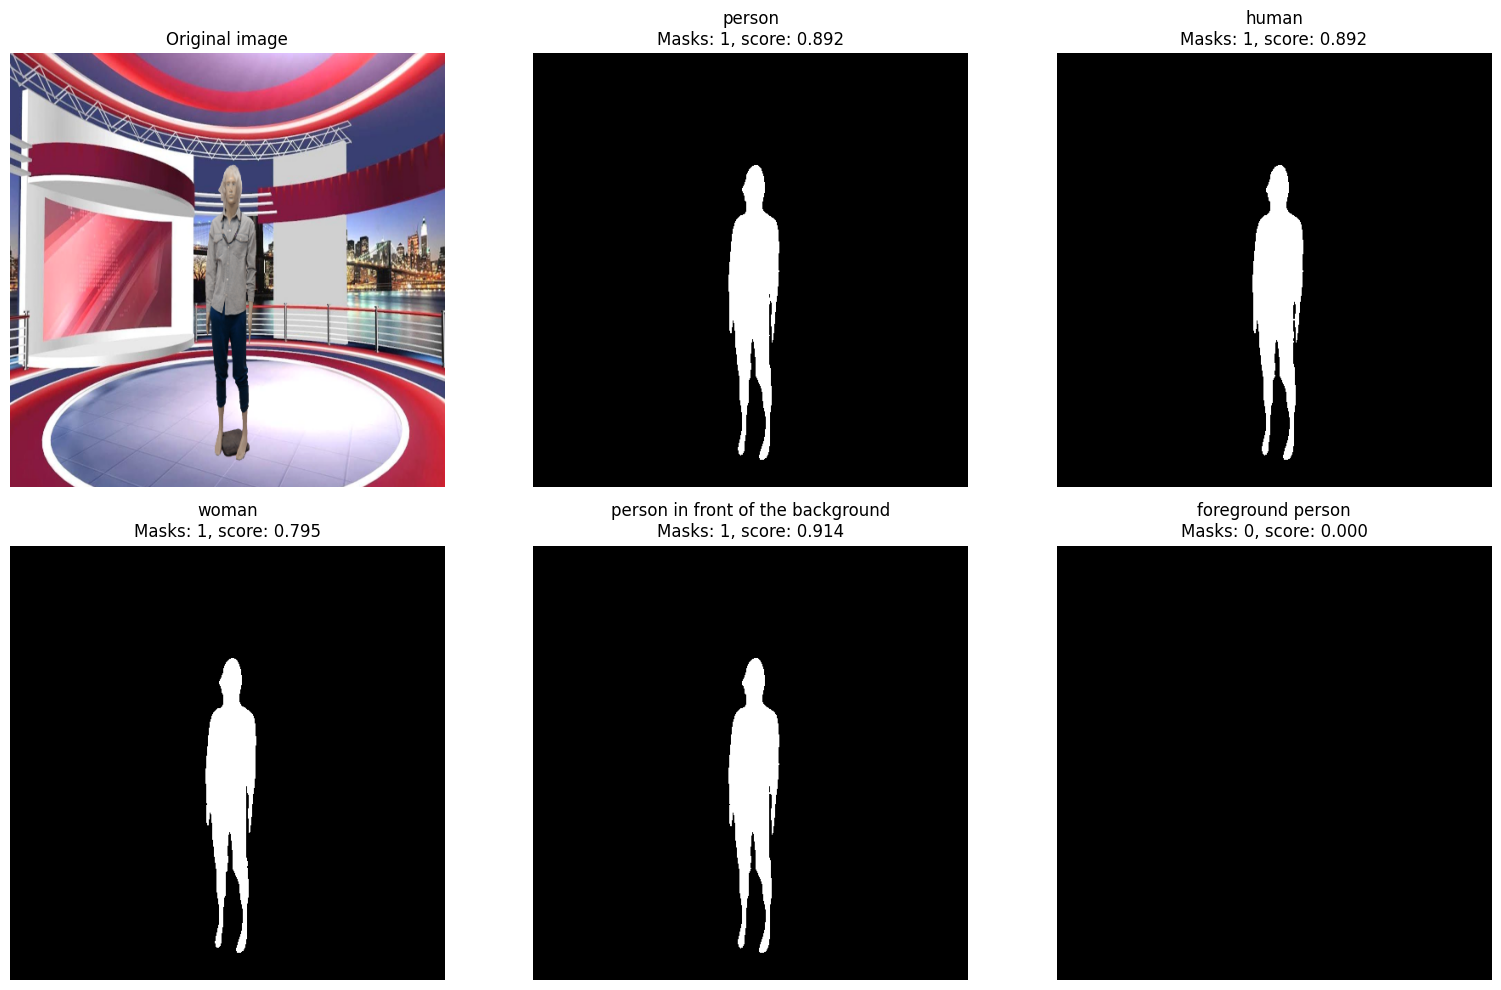


SAM 3 PROMPT TEST COMPLETED
Results folder: /content/sam3_results/prompt_test
Comparison figure: /content/sam3_results/prompt_test/sam3_prompt_comparison.png


In [ ]:
# ============================================================
# STEP 2 — LOAD SAM 3 AND TEST TEXT PROMPTS ON ONE IMAGE
# ============================================================

from pathlib import Path

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

from PIL import Image

from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor


# ============================================================
# SETTINGS
# ============================================================

TEST_IMAGE_PATH = Path(
    "/content/ROM_Detectron2/test/images/test_001.png"
)

OUTPUT_DIR = Path(
    "/content/sam3_results/prompt_test"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

PROMPTS = [
    "person",
    "human",
    "woman",
    "person in front of the background",
    "foreground person"
]


# ============================================================
# LOAD SAM 3
# ============================================================

print("Loading SAM 3 model...")

sam3_model = build_sam3_image_model()

sam3_processor = Sam3Processor(
    sam3_model
)

print("SAM 3 model loaded.")
print("Device:", DEVICE)


# ============================================================
# LOAD TEST IMAGE
# ============================================================

if not TEST_IMAGE_PATH.exists():
    raise FileNotFoundError(
        f"Test image not found: {TEST_IMAGE_PATH}"
    )

image_pil = Image.open(
    TEST_IMAGE_PATH
).convert("RGB")

image_rgb = np.array(
    image_pil
)

height, width = image_rgb.shape[:2]

print("Image:", TEST_IMAGE_PATH)
print("Image dimensions:", width, "x", height)


# ============================================================
# HELPER FUNCTION
# ============================================================

def combine_sam3_masks(
    masks,
    height,
    width
):
    """
    Merge every detected SAM 3 instance into one binary mask.
    """

    combined_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    if masks is None:
        return combined_mask

    if torch.is_tensor(masks):
        masks = masks.detach().cpu().numpy()

    masks = np.asarray(masks)

    if masks.size == 0:
        return combined_mask

    # Remove singleton dimensions such as [N, 1, H, W].
    masks = np.squeeze(masks)

    if masks.ndim == 2:
        masks = masks[None, ...]

    for mask in masks:

        if mask.shape != (height, width):
            mask = cv2.resize(
                mask.astype(np.float32),
                (width, height),
                interpolation=cv2.INTER_NEAREST
            )

        binary_mask = (
            mask > 0
        ).astype(np.uint8)

        combined_mask = np.maximum(
            combined_mask,
            binary_mask
        )

    return combined_mask


# ============================================================
# RUN PROMPT TESTS
# ============================================================

prompt_results = []

for prompt_index, prompt in enumerate(
    PROMPTS,
    start=1
):

    print(
        f"\nTesting prompt {prompt_index}: "
        f"'{prompt}'"
    )

    with torch.inference_mode():

      with torch.autocast(
        device_type="cuda",
        dtype=torch.float16
      ):

        inference_state = (
            sam3_processor.set_image(
                image_pil
            )
        )

        output = (
            sam3_processor.set_text_prompt(
                state=inference_state,
                prompt=prompt
            )
        )

    masks = output.get(
        "masks",
        None
    )

    scores = output.get(
        "scores",
        None
    )

    boxes = output.get(
        "boxes",
        None
    )

    combined_mask = combine_sam3_masks(
        masks=masks,
        height=height,
        width=width
    )

    if scores is None:
        score_values = []

    elif torch.is_tensor(scores):
        score_values = (
            scores.detach()
            .cpu()
            .numpy()
            .reshape(-1)
            .tolist()
        )

    else:
        score_values = (
            np.asarray(scores)
            .reshape(-1)
            .tolist()
        )

    number_of_masks = 0

    if masks is not None:

        if torch.is_tensor(masks):
            mask_shape = tuple(
                masks.shape
            )
        else:
            mask_shape = np.asarray(
                masks
            ).shape

        if len(mask_shape) >= 3:
            number_of_masks = (
                mask_shape[0]
            )
        elif len(mask_shape) == 2:
            number_of_masks = 1

    foreground_pixels = int(
        combined_mask.sum()
    )

    foreground_fraction = (
        foreground_pixels
        / float(height * width)
    )

    maximum_score = (
        float(np.max(score_values))
        if score_values
        else 0.0
    )

    mean_score = (
        float(np.mean(score_values))
        if score_values
        else 0.0
    )

    prompt_results.append(
        {
            "prompt": prompt,
            "number_of_masks":
                number_of_masks,
            "foreground_pixels":
                foreground_pixels,
            "foreground_fraction":
                foreground_fraction,
            "maximum_score":
                maximum_score,
            "mean_score":
                mean_score
        }
    )

    safe_prompt_name = (
        prompt
        .replace(" ", "_")
        .replace("/", "_")
    )

    cv2.imwrite(
        str(
            OUTPUT_DIR
            / f"{prompt_index:02d}_{safe_prompt_name}.png"
        ),
        combined_mask * 255
    )

    print("Masks:", number_of_masks)
    print(
        "Foreground fraction:",
        f"{foreground_fraction:.4f}"
    )
    print(
        "Maximum score:",
        f"{maximum_score:.4f}"
    )


# ============================================================
# DISPLAY RESULTS
# ============================================================

import pandas as pd

prompt_dataframe = pd.DataFrame(
    prompt_results
)

display(
    prompt_dataframe
)


figure = plt.figure(
    figsize=(16, 10)
)

columns = 3
rows = 2

axis = figure.add_subplot(
    rows,
    columns,
    1
)

axis.imshow(
    image_rgb
)

axis.set_title(
    "Original image"
)

axis.axis("off")


for prompt_index, result in enumerate(
    prompt_results,
    start=2
):

    axis = figure.add_subplot(
        rows,
        columns,
        prompt_index
    )

    mask_path = (
        OUTPUT_DIR
        / (
            f"{prompt_index - 1:02d}_"
            f"{result['prompt'].replace(' ', '_')}.png"
        )
    )

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    axis.imshow(
        mask,
        cmap="gray",
        vmin=0,
        vmax=255
    )

    axis.set_title(
        f"{result['prompt']}\n"
        f"Masks: {result['number_of_masks']}, "
        f"score: {result['maximum_score']:.3f}"
    )

    axis.axis("off")


figure.tight_layout()

comparison_path = (
    OUTPUT_DIR
    / "sam3_prompt_comparison.png"
)

figure.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\n==========================================")
print("SAM 3 PROMPT TEST COMPLETED")
print("==========================================")
print("Results folder:", OUTPUT_DIR)
print("Comparison figure:", comparison_path)
print("==========================================")

In [ ]:
# ============================================================
# FIX SAM 3 DTYPE FOR TESLA T4
# ============================================================

import torch

# Ensure model parameters remain on CUDA in FP32.
sam3_model = sam3_model.to(
    device="cuda",
    dtype=torch.float32
)

sam3_model.eval()

print(
    "Model parameter dtype:",
    next(sam3_model.parameters()).dtype
)

print(
    "GPU BF16 supported:",
    torch.cuda.is_bf16_supported()
)

Model parameter dtype: torch.float32
GPU BF16 supported: True


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1370: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:308.)
  return t.to(


In [ ]:
# ============================================================
# SAM 3 — FULL EVALUATION ON 7 INDEPENDENT TEST IMAGES
# TESLA T4 FP16 VERSION
# ============================================================

import time
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
from PIL import Image


# ============================================================
# SETTINGS
# ============================================================

TEST_IMAGE_DIR = Path(
    "/content/ROM_Detectron2/test/images"
)

TEST_MASK_DIR = Path(
    "/content/ROM_Detectron2/test/masks"
)

OUTPUT_DIR = Path(
    "/content/sam3_results/test_evaluation"
)

PREDICTION_DIR = OUTPUT_DIR / "predicted_masks"

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

DETAILED_CSV = (
    OUTPUT_DIR / "sam3_test_metrics.csv"
)

SUMMARY_CSV = (
    OUTPUT_DIR / "sam3_test_summary.csv"
)

# Use exactly one prompt for all seven images.
TEXT_PROMPT = "person"

DEVICE = "cuda"


# ============================================================
# CHECK MODEL
# ============================================================

if "sam3_model" not in globals():
    raise RuntimeError(
        "sam3_model is not loaded. "
        "Rerun the SAM 3 model-loading cell."
    )

if "sam3_processor" not in globals():
    raise RuntimeError(
        "sam3_processor is not loaded. "
        "Rerun the SAM 3 model-loading cell."
    )

sam3_model = sam3_model.to(
    device=DEVICE,
    dtype=torch.float32
)

sam3_model.eval()

print("SAM 3 model found.")
print("Fixed prompt:", TEXT_PROMPT)
print(
    "Model parameter dtype:",
    next(sam3_model.parameters()).dtype
)


# ============================================================
# FIND TEST IMAGES
# ============================================================

supported_extensions = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}

test_image_paths = sorted(
    [
        path
        for path in TEST_IMAGE_DIR.iterdir()
        if path.suffix.lower()
        in supported_extensions
    ]
)

if len(test_image_paths) == 0:
    raise RuntimeError(
        f"No test images found in {TEST_IMAGE_DIR}"
    )

print("Test images found:", len(test_image_paths))


# ============================================================
# HELPER: FIND MATCHING MASK
# ============================================================

def find_matching_mask(
    image_path,
    mask_directory
):
    exact_path = (
        mask_directory / image_path.name
    )

    if exact_path.exists():
        return exact_path

    possible_extensions = [
        ".png",
        ".jpg",
        ".jpeg",
        ".bmp",
        ".tif",
        ".tiff"
    ]

    for extension in possible_extensions:
        candidate = (
            mask_directory
            / f"{image_path.stem}{extension}"
        )

        if candidate.exists():
            return candidate

    raise FileNotFoundError(
        f"No matching mask found for "
        f"{image_path.name}"
    )


# ============================================================
# HELPER: LOAD BINARY MASK
# ============================================================

def load_binary_mask(
    mask_path
):
    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Could not read mask: {mask_path}"
        )

    return (
        mask >= 128
    ).astype(np.uint8)


# ============================================================
# HELPER: CONVERT SAM MASKS
# ============================================================

def convert_sam3_masks_to_numpy(
    masks
):
    if masks is None:
        return np.empty(
            (0, 0, 0),
            dtype=np.float32
        )

    if torch.is_tensor(masks):
        masks = (
            masks.detach()
            .float()
            .cpu()
            .numpy()
        )
    else:
        masks = np.asarray(masks)

    if (
        masks.ndim == 4
        and masks.shape[1] == 1
    ):
        masks = masks[:, 0]

    if masks.ndim == 2:
        masks = masks[None, ...]

    return masks


# ============================================================
# HELPER: MERGE ALL DETECTED INSTANCES
# ============================================================

def combine_sam3_masks(
    masks,
    target_height,
    target_width
):
    masks_array = (
        convert_sam3_masks_to_numpy(
            masks
        )
    )

    combined_mask = np.zeros(
        (
            target_height,
            target_width
        ),
        dtype=np.uint8
    )

    if masks_array.size == 0:
        return combined_mask, 0

    valid_mask_count = 0

    for mask in masks_array:
        mask = np.squeeze(mask)

        if mask.ndim != 2:
            continue

        if mask.shape != (
            target_height,
            target_width
        ):
            mask = cv2.resize(
                mask.astype(
                    np.float32
                ),
                (
                    target_width,
                    target_height
                ),
                interpolation=(
                    cv2.INTER_NEAREST
                )
            )

        if mask.dtype == bool:
            binary_mask = (
                mask.astype(np.uint8)
            )

        elif np.min(mask) < 0:
            binary_mask = (
                mask > 0
            ).astype(np.uint8)

        else:
            binary_mask = (
                mask >= 0.5
            ).astype(np.uint8)

        if binary_mask.sum() > 0:
            combined_mask = np.maximum(
                combined_mask,
                binary_mask
            )

            valid_mask_count += 1

    return (
        combined_mask,
        valid_mask_count
    )


# ============================================================
# HELPER: CONVERT SCORES
# ============================================================

def values_to_list(
    values
):
    if values is None:
        return []

    if torch.is_tensor(values):
        return (
            values.detach()
            .float()
            .cpu()
            .numpy()
            .reshape(-1)
            .tolist()
        )

    return (
        np.asarray(values)
        .reshape(-1)
        .tolist()
    )


# ============================================================
# HELPER: METRICS
# ============================================================

def calculate_metrics(
    prediction,
    ground_truth,
    epsilon=1e-7
):
    prediction = (
        prediction > 0
    ).astype(np.uint8)

    ground_truth = (
        ground_truth > 0
    ).astype(np.uint8)

    true_positive = int(
        np.logical_and(
            prediction == 1,
            ground_truth == 1
        ).sum()
    )

    true_negative = int(
        np.logical_and(
            prediction == 0,
            ground_truth == 0
        ).sum()
    )

    false_positive = int(
        np.logical_and(
            prediction == 1,
            ground_truth == 0
        ).sum()
    )

    false_negative = int(
        np.logical_and(
            prediction == 0,
            ground_truth == 1
        ).sum()
    )

    dice = (
        2.0 * true_positive
        + epsilon
    ) / (
        2.0 * true_positive
        + false_positive
        + false_negative
        + epsilon
    )

    iou = (
        true_positive
        + epsilon
    ) / (
        true_positive
        + false_positive
        + false_negative
        + epsilon
    )

    precision = (
        true_positive
        / max(
            true_positive
            + false_positive,
            1
        )
    )

    recall = (
        true_positive
        / max(
            true_positive
            + false_negative,
            1
        )
    )

    pixel_accuracy = (
        true_positive
        + true_negative
    ) / max(
        true_positive
        + true_negative
        + false_positive
        + false_negative,
        1
    )

    squared_error = (
        prediction.astype(
            np.float32
        )
        - ground_truth.astype(
            np.float32
        )
    ) ** 2

    mse = float(
        np.mean(
            squared_error
        )
    )

    psnr = 10.0 * np.log10(
        1.0 / max(
            mse,
            epsilon
        )
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "psnr_db": float(psnr),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy":
            float(pixel_accuracy),
        "true_positive_pixels":
            true_positive,
        "true_negative_pixels":
            true_negative,
        "false_positive_pixels":
            false_positive,
        "false_negative_pixels":
            false_negative
    }


# ============================================================
# GPU WARM-UP
# ============================================================

warmup_image = Image.open(
    test_image_paths[0]
).convert("RGB")

print("Running GPU warm-up...")

for _ in range(2):
    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            warmup_state = (
                sam3_processor.set_image(
                    warmup_image
                )
            )

            _ = (
                sam3_processor
                .set_text_prompt(
                    state=warmup_state,
                    prompt=TEXT_PROMPT
                )
            )

torch.cuda.synchronize()

print("GPU warm-up completed.")


# ============================================================
# EVALUATE ALL TEST IMAGES
# ============================================================

results = []

for image_index, image_path in enumerate(
    test_image_paths,
    start=1
):
    mask_path = find_matching_mask(
        image_path=image_path,
        mask_directory=TEST_MASK_DIR
    )

    image_pil = Image.open(
        image_path
    ).convert("RGB")

    ground_truth = load_binary_mask(
        mask_path
    )

    target_height, target_width = (
        ground_truth.shape
    )

    torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):
            inference_state = (
                sam3_processor.set_image(
                    image_pil
                )
            )

            output = (
                sam3_processor
                .set_text_prompt(
                    state=inference_state,
                    prompt=TEXT_PROMPT
                )
            )

    torch.cuda.synchronize()

    inference_time_seconds = (
        time.perf_counter()
        - start_time
    )

    masks = output.get(
        "masks",
        None
    )

    scores = values_to_list(
        output.get(
            "scores",
            None
        )
    )

    prediction, number_of_masks = (
        combine_sam3_masks(
            masks=masks,
            target_height=(
                target_height
            ),
            target_width=(
                target_width
            )
        )
    )

    metrics = calculate_metrics(
        prediction=prediction,
        ground_truth=ground_truth
    )

    prediction_path = (
        PREDICTION_DIR
        / f"{image_path.stem}.png"
    )

    cv2.imwrite(
        str(prediction_path),
        prediction * 255
    )

    maximum_score = (
        float(np.max(scores))
        if scores
        else 0.0
    )

    mean_score = (
        float(np.mean(scores))
        if scores
        else 0.0
    )

    foreground_fraction = float(
        prediction.sum()
        / prediction.size
    )

    results.append(
        {
            "image_index":
                image_index,
            "image_filename":
                image_path.name,
            "mask_filename":
                mask_path.name,
            "text_prompt":
                TEXT_PROMPT,
            "number_of_masks":
                number_of_masks,
            "maximum_score":
                maximum_score,
            "mean_score":
                mean_score,
            "predicted_foreground_fraction":
                foreground_fraction,
            **metrics,
            "inference_time_seconds":
                inference_time_seconds,
            "inference_time_ms":
                inference_time_seconds
                * 1000.0
        }
    )

    print(
        f"Image {image_index}: "
        f"{image_path.name}"
    )

    print(
        f"  Masks: "
        f"{number_of_masks}"
    )

    print(
        f"  Dice: "
        f"{metrics['dice']:.6f}"
    )

    print(
        f"  IoU: "
        f"{metrics['iou']:.6f}"
    )

    print(
        f"  PSNR: "
        f"{metrics['psnr_db']:.3f} dB"
    )

    print(
        f"  Time: "
        f"{inference_time_seconds * 1000:.2f} ms"
    )


# ============================================================
# SAVE DETAILED RESULTS
# ============================================================

results_dataframe = pd.DataFrame(
    results
)

results_dataframe.to_csv(
    DETAILED_CSV,
    index=False
)


# ============================================================
# CREATE SUMMARY
# ============================================================

mean_time_seconds = float(
    results_dataframe[
        "inference_time_seconds"
    ].mean()
)

throughput_fps = (
    1.0 / mean_time_seconds
    if mean_time_seconds > 0
    else 0.0
)

summary_dataframe = pd.DataFrame(
    [
        {
            "model":
                "SAM 3",
            "evaluation_mode":
                "zero-shot text-prompt segmentation",
            "text_prompt":
                TEXT_PROMPT,
            "test_images":
                len(
                    results_dataframe
                ),
            "mean_dice":
                results_dataframe[
                    "dice"
                ].mean(),
            "std_dice":
                results_dataframe[
                    "dice"
                ].std(
                    ddof=0
                ),
            "mean_iou":
                results_dataframe[
                    "iou"
                ].mean(),
            "std_iou":
                results_dataframe[
                    "iou"
                ].std(
                    ddof=0
                ),
            "mean_psnr_db":
                results_dataframe[
                    "psnr_db"
                ].mean(),
            "std_psnr_db":
                results_dataframe[
                    "psnr_db"
                ].std(
                    ddof=0
                ),
            "mean_precision":
                results_dataframe[
                    "precision"
                ].mean(),
            "mean_recall":
                results_dataframe[
                    "recall"
                ].mean(),
            "mean_pixel_accuracy":
                results_dataframe[
                    "pixel_accuracy"
                ].mean(),
            "mean_number_of_masks":
                results_dataframe[
                    "number_of_masks"
                ].mean(),
            "mean_inference_time_ms":
                results_dataframe[
                    "inference_time_ms"
                ].mean(),
            "throughput_fps":
                throughput_fps
        }
    ]
)

summary_dataframe.to_csv(
    SUMMARY_CSV,
    index=False
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

summary = summary_dataframe.iloc[0]

print("\n==========================================")
print("SAM 3 INDEPENDENT TEST EVALUATION")
print("==========================================")
print("Mode: zero-shot text-prompt segmentation")
print("Fixed prompt:", TEXT_PROMPT)
print("Test images:", len(results_dataframe))

print(
    f"Mean Dice: "
    f"{summary['mean_dice']:.6f} "
    f"± {summary['std_dice']:.6f}"
)

print(
    f"Mean IoU: "
    f"{summary['mean_iou']:.6f} "
    f"± {summary['std_iou']:.6f}"
)

print(
    f"Mean PSNR: "
    f"{summary['mean_psnr_db']:.3f} "
    f"± {summary['std_psnr_db']:.3f} dB"
)

print(
    f"Mean inference time: "
    f"{summary['mean_inference_time_ms']:.2f} "
    f"ms/image"
)

print(
    f"Throughput: "
    f"{summary['throughput_fps']:.2f} FPS"
)

print(
    "Detailed metrics:",
    DETAILED_CSV
)

print(
    "Summary:",
    SUMMARY_CSV
)

print(
    "Predicted masks:",
    PREDICTION_DIR
)

print("==========================================")

display(
    results_dataframe
)

display(
    summary_dataframe
)

SAM 3 model found.
Fixed prompt: person
Model parameter dtype: torch.float32
Test images found: 7
Running GPU warm-up...
GPU warm-up completed.
Image 1: test_001.png
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 12.053 dB
  Time: 1215.45 ms
Image 2: test_002.png
  Masks: 1
  Dice: 0.351125
  IoU: 0.212948
  PSNR: 10.468 dB
  Time: 1221.37 ms
Image 3: test_003.png
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 8.064 dB
  Time: 1301.57 ms
Image 4: test_004.png
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 3.880 dB
  Time: 1296.36 ms
Image 5: test_005.png
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 9.749 dB
  Time: 1094.25 ms
Image 6: test_006.png
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 12.284 dB
  Time: 1108.13 ms
Image 7: test_007.png
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 10.038 dB
  Time: 1099.19 ms

SAM 3 INDEPENDENT TEST EVALUATION
Mode: zero-shot text-prompt segmentation
Fixed prompt: person
Test images: 7
Mean Dice: 0.050161 ± 0.12

,image_index,image_filename,mask_filename,text_prompt,number_of_masks,maximum_score,mean_score,predicted_foreground_fraction,dice,iou,psnr_db,precision,recall,pixel_accuracy,true_positive_pixels,true_negative_pixels,false_positive_pixels,false_negative_pixels,inference_time_seconds,inference_time_ms
0,1,test_001.png,test_001.png,person,0,0.000000,0.000000,0.000000,6.119951e-12,6.119951e-12,12.052879,0.000000,0.00000,0.937668,0,245804,0,16340,1.215451,1215.450510
1,2,test_002.png,test_002.png,person,1,0.560547,0.560547,0.027657,3.511248e-01,2.129481e-01,10.468073,0.878345,0.21942,0.910217,6368,232240,882,22654,1.221366,1221.365613
2,3,test_003.png,test_003.png,person,0,0.000000,0.000000,0.000000,2.442599e-12,2.442599e-12,8.063921,0.000000,0.00000,0.843826,0,221204,0,40940,1.301571,1301.571263
3,4,test_004.png,test_004.png,person,0,0.000000,0.000000,0.000000,9.321576e-13,9.321576e-13,3.880293,0.000000,0.00000,0.590767,0,154866,0,107278,1.296357,1296.357034
4,5,test_005.png,test_005.png,person,0,0.000000,0.000000,0.000000,3.600749e-12,3.600749e-12,9.749328,0.000000,0.00000,0.894058,0,234372,0,27772,1.094251,1094.251071
5,6,test_006.png,test_006.png,person,0,0.000000,0.000000,0.000000,6.454528e-12,6.454528e-12,12.284044,0.000000,0.00000,0.940899,0,246651,0,15493,1.108133,1108.133437
6,7,test_007.png,test_007.png,person,0,0.000000,0.000000,0.000000,3.848522e-12,3.848522e-12,10.038339,0.000000,0.00000,0.900879,0,236160,0,25984,1.099187,1099.186503


,model,evaluation_mode,text_prompt,test_images,mean_dice,std_dice,mean_iou,std_iou,mean_psnr_db,std_psnr_db,mean_precision,mean_recall,mean_pixel_accuracy,mean_number_of_masks,mean_inference_time_ms,throughput_fps
0,SAM 3,zero-shot text-prompt segmentation,person,7,0.050161,0.122868,0.030421,0.074516,9.505268,2.651158,0.125478,0.031346,0.859759,0.142857,1190.902204,0.8397


In [ ]:
# ============================================================
# SAM 3 — FINAL OBJECT-SPECIFIC PROMPT EVALUATION AND EXPORT
# ============================================================

import json
import shutil
import time
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image


# ============================================================
# PATHS
# ============================================================

TEST_IMAGE_DIR = Path(
    "/content/ROM_Detectron2/test/images"
)

TEST_MASK_DIR = Path(
    "/content/ROM_Detectron2/test/masks"
)

EXPORT_ROOT = Path(
    "/content/sam3_complete_results"
)

ORIGINAL_DIR = EXPORT_ROOT / "originals"
GT_DIR = EXPORT_ROOT / "ground_truth_masks"
PREDICTION_DIR = EXPORT_ROOT / "predicted_masks"
OVERLAY_DIR = EXPORT_ROOT / "overlays"
ERROR_DIR = EXPORT_ROOT / "error_maps"
COMPARISON_DIR = EXPORT_ROOT / "comparison_figures"
METRICS_DIR = EXPORT_ROOT / "metrics"
CONFIG_DIR = EXPORT_ROOT / "configuration"

for directory in [
    ORIGINAL_DIR,
    GT_DIR,
    PREDICTION_DIR,
    OVERLAY_DIR,
    ERROR_DIR,
    COMPARISON_DIR,
    METRICS_DIR,
    CONFIG_DIR
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )


# ============================================================
# FIXED PROMPTS
# ============================================================

PROMPTS_BY_IMAGE = {
    "test_001.png": "person",
    "test_002.png": "person",
    "test_003.png": "people",
    "test_004.png": "toilet paper",
    "test_005.png": "lamp",
    "test_006.png": "plate",
    "test_007.png": "pens in a pen holder"
}


# ============================================================
# CHECK SAM 3
# ============================================================

if "sam3_model" not in globals():
    raise RuntimeError(
        "sam3_model is not loaded."
    )

if "sam3_processor" not in globals():
    raise RuntimeError(
        "sam3_processor is not loaded."
    )

DEVICE = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

sam3_model = sam3_model.to(
    device=DEVICE,
    dtype=torch.float32
)

sam3_model.eval()

print("Device:", DEVICE)
print(
    "Model dtype:",
    next(sam3_model.parameters()).dtype
)


# ============================================================
# HELPERS
# ============================================================

def load_binary_mask(mask_path):
    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Could not read mask: {mask_path}"
        )

    return (
        mask >= 128
    ).astype(np.uint8)


def convert_masks_to_numpy(masks):
    if masks is None:
        return np.empty(
            (0, 0, 0),
            dtype=np.float32
        )

    if torch.is_tensor(masks):
        masks = (
            masks.detach()
            .float()
            .cpu()
            .numpy()
        )
    else:
        masks = np.asarray(masks)

    if (
        masks.ndim == 4
        and masks.shape[1] == 1
    ):
        masks = masks[:, 0]

    if masks.ndim == 2:
        masks = masks[None, ...]

    return masks


def combine_masks(
    masks,
    height,
    width
):
    masks = convert_masks_to_numpy(
        masks
    )

    combined = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    valid_count = 0

    if masks.size == 0:
        return combined, valid_count

    for mask in masks:
        mask = np.squeeze(mask)

        if mask.ndim != 2:
            continue

        if mask.shape != (
            height,
            width
        ):
            mask = cv2.resize(
                mask.astype(np.float32),
                (width, height),
                interpolation=cv2.INTER_NEAREST
            )

        if mask.dtype == bool:
            binary = mask.astype(np.uint8)

        elif np.min(mask) < 0:
            binary = (
                mask > 0
            ).astype(np.uint8)

        else:
            binary = (
                mask >= 0.5
            ).astype(np.uint8)

        if binary.sum() > 0:
            combined = np.maximum(
                combined,
                binary
            )

            valid_count += 1

    return combined, valid_count


def values_to_list(values):
    if values is None:
        return []

    if torch.is_tensor(values):
        return (
            values.detach()
            .float()
            .cpu()
            .numpy()
            .reshape(-1)
            .tolist()
        )

    return (
        np.asarray(values)
        .reshape(-1)
        .tolist()
    )


def calculate_metrics(
    prediction,
    ground_truth,
    epsilon=1e-7
):
    prediction = (
        prediction > 0
    ).astype(np.uint8)

    ground_truth = (
        ground_truth > 0
    ).astype(np.uint8)

    tp = int(
        np.logical_and(
            prediction == 1,
            ground_truth == 1
        ).sum()
    )

    tn = int(
        np.logical_and(
            prediction == 0,
            ground_truth == 0
        ).sum()
    )

    fp = int(
        np.logical_and(
            prediction == 1,
            ground_truth == 0
        ).sum()
    )

    fn = int(
        np.logical_and(
            prediction == 0,
            ground_truth == 1
        ).sum()
    )

    dice = (
        2.0 * tp + epsilon
    ) / (
        2.0 * tp
        + fp
        + fn
        + epsilon
    )

    iou = (
        tp + epsilon
    ) / (
        tp
        + fp
        + fn
        + epsilon
    )

    precision = (
        tp / max(
            tp + fp,
            1
        )
    )

    recall = (
        tp / max(
            tp + fn,
            1
        )
    )

    pixel_accuracy = (
        tp + tn
    ) / max(
        tp + tn + fp + fn,
        1
    )

    mse = float(
        np.mean(
            (
                prediction.astype(np.float32)
                - ground_truth.astype(np.float32)
            ) ** 2
        )
    )

    psnr = 10.0 * np.log10(
        1.0 / max(
            mse,
            epsilon
        )
    )

    return {
        "dice": float(dice),
        "iou": float(iou),
        "psnr_db": float(psnr),
        "precision": float(precision),
        "recall": float(recall),
        "pixel_accuracy": float(pixel_accuracy),
        "true_positive_pixels": tp,
        "true_negative_pixels": tn,
        "false_positive_pixels": fp,
        "false_negative_pixels": fn
    }


def create_overlay(
    image_rgb,
    ground_truth,
    prediction
):
    overlay = image_rgb.copy()

    gt_boundary = cv2.morphologyEx(
        ground_truth,
        cv2.MORPH_GRADIENT,
        np.ones(
            (3, 3),
            dtype=np.uint8
        )
    )

    pred_boundary = cv2.morphologyEx(
        prediction,
        cv2.MORPH_GRADIENT,
        np.ones(
            (3, 3),
            dtype=np.uint8
        )
    )

    # Ground truth boundary: green
    overlay[
        gt_boundary > 0
    ] = [0, 255, 0]

    # Prediction boundary: red
    overlay[
        pred_boundary > 0
    ] = [255, 0, 0]

    return overlay


def create_error_map(
    prediction,
    ground_truth
):
    error_map = np.zeros(
        (
            ground_truth.shape[0],
            ground_truth.shape[1],
            3
        ),
        dtype=np.uint8
    )

    true_positive = np.logical_and(
        prediction == 1,
        ground_truth == 1
    )

    false_positive = np.logical_and(
        prediction == 1,
        ground_truth == 0
    )

    false_negative = np.logical_and(
        prediction == 0,
        ground_truth == 1
    )

    # Correct foreground: white
    error_map[
        true_positive
    ] = [255, 255, 255]

    # False positive: red
    error_map[
        false_positive
    ] = [255, 0, 0]

    # False negative: blue
    error_map[
        false_negative
    ] = [0, 0, 255]

    return error_map


# ============================================================
# TEST FILES
# ============================================================

test_image_paths = sorted(
    [
        TEST_IMAGE_DIR / filename
        for filename in PROMPTS_BY_IMAGE
    ]
)

for image_path in test_image_paths:
    if not image_path.exists():
        raise FileNotFoundError(
            f"Missing image: {image_path}"
        )

    mask_path = (
        TEST_MASK_DIR / image_path.name
    )

    if not mask_path.exists():
        raise FileNotFoundError(
            f"Missing mask: {mask_path}"
        )


# ============================================================
# GPU WARM-UP
# ============================================================

print("Running warm-up...")

warmup_image = Image.open(
    test_image_paths[0]
).convert("RGB")

for _ in range(2):
    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                DEVICE == "cuda"
            )
        ):
            warmup_state = (
                sam3_processor.set_image(
                    warmup_image
                )
            )

            _ = sam3_processor.set_text_prompt(
                state=warmup_state,
                prompt="person"
            )

if DEVICE == "cuda":
    torch.cuda.synchronize()

print("Warm-up completed.")


# ============================================================
# FINAL EVALUATION
# ============================================================

result_rows = []

for image_index, image_path in enumerate(
    test_image_paths,
    start=1
):
    prompt = PROMPTS_BY_IMAGE[
        image_path.name
    ]

    mask_path = (
        TEST_MASK_DIR / image_path.name
    )

    image_pil = Image.open(
        image_path
    ).convert("RGB")

    image_rgb = np.asarray(
        image_pil
    )

    ground_truth = load_binary_mask(
        mask_path
    )

    height, width = (
        ground_truth.shape
    )

    if image_rgb.shape[:2] != (
        height,
        width
    ):
        image_rgb = cv2.resize(
            image_rgb,
            (width, height),
            interpolation=cv2.INTER_LINEAR
        )

        image_pil = Image.fromarray(
            image_rgb
        )

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    start_time = time.perf_counter()

    with torch.inference_mode():
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(
                DEVICE == "cuda"
            )
        ):
            inference_state = (
                sam3_processor.set_image(
                    image_pil
                )
            )

            output = (
                sam3_processor.set_text_prompt(
                    state=inference_state,
                    prompt=prompt
                )
            )

    if DEVICE == "cuda":
        torch.cuda.synchronize()

    inference_seconds = (
        time.perf_counter()
        - start_time
    )

    scores = values_to_list(
        output.get(
            "scores",
            None
        )
    )

    prediction, number_of_masks = (
        combine_masks(
            masks=output.get(
                "masks",
                None
            ),
            height=height,
            width=width
        )
    )

    metrics = calculate_metrics(
        prediction=prediction,
        ground_truth=ground_truth
    )

    overlay = create_overlay(
        image_rgb=image_rgb,
        ground_truth=ground_truth,
        prediction=prediction
    )

    error_map = create_error_map(
        prediction=prediction,
        ground_truth=ground_truth
    )

    output_name = (
        f"{image_index:02d}_"
        f"{image_path.stem}"
    )

    Image.fromarray(
        image_rgb
    ).save(
        ORIGINAL_DIR
        / f"{output_name}.png"
    )

    cv2.imwrite(
        str(
            GT_DIR
            / f"{output_name}.png"
        ),
        ground_truth * 255
    )

    cv2.imwrite(
        str(
            PREDICTION_DIR
            / f"{output_name}.png"
        ),
        prediction * 255
    )

    Image.fromarray(
        overlay
    ).save(
        OVERLAY_DIR
        / f"{output_name}.png"
    )

    Image.fromarray(
        error_map
    ).save(
        ERROR_DIR
        / f"{output_name}.png"
    )

    figure = plt.figure(
        figsize=(16, 4)
    )

    axis = figure.add_subplot(
        1,
        5,
        1
    )

    axis.imshow(
        image_rgb
    )

    axis.set_title(
        "Original"
    )

    axis.axis("off")

    axis = figure.add_subplot(
        1,
        5,
        2
    )

    axis.imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axis.set_title(
        "Ground truth"
    )

    axis.axis("off")

    axis = figure.add_subplot(
        1,
        5,
        3
    )

    axis.imshow(
        prediction,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axis.set_title(
        f"SAM 3 prediction\nPrompt: {prompt}"
    )

    axis.axis("off")

    axis = figure.add_subplot(
        1,
        5,
        4
    )

    axis.imshow(
        overlay
    )

    axis.set_title(
        "Boundary overlay"
    )

    axis.axis("off")

    axis = figure.add_subplot(
        1,
        5,
        5
    )

    axis.imshow(
        error_map
    )

    axis.set_title(
        "Error map"
    )

    axis.axis("off")

    figure.suptitle(
        f"Image {image_index} — "
        f"Dice: {metrics['dice']:.4f}, "
        f"IoU: {metrics['iou']:.4f}, "
        f"PSNR: {metrics['psnr_db']:.2f} dB"
    )

    figure.tight_layout()

    figure.savefig(
        COMPARISON_DIR
        / f"{output_name}_comparison.png",
        dpi=200,
        bbox_inches="tight"
    )

    plt.close(
        figure
    )

    result_rows.append(
        {
            "image_index": image_index,
            "image_filename":
                image_path.name,
            "text_prompt":
                prompt,
            "number_of_masks":
                number_of_masks,
            "maximum_score":
                float(np.max(scores))
                if scores else 0.0,
            "mean_score":
                float(np.mean(scores))
                if scores else 0.0,
            "predicted_foreground_fraction":
                float(
                    prediction.mean()
                ),
            **metrics,
            "inference_time_seconds":
                float(inference_seconds),
            "inference_time_ms":
                float(
                    inference_seconds
                    * 1000.0
                )
        }
    )

    print(
        f"Image {image_index}: "
        f"{image_path.name}"
    )

    print(
        f"  Prompt: {prompt}"
    )

    print(
        f"  Masks: {number_of_masks}"
    )

    print(
        f"  Dice: {metrics['dice']:.6f}"
    )

    print(
        f"  IoU: {metrics['iou']:.6f}"
    )

    print(
        f"  PSNR: "
        f"{metrics['psnr_db']:.3f} dB"
    )

    print(
        f"  Time: "
        f"{inference_seconds * 1000:.2f} ms"
    )


# ============================================================
# SAVE METRICS
# ============================================================

results_dataframe = pd.DataFrame(
    result_rows
)

detailed_csv = (
    METRICS_DIR
    / "sam3_test_metrics.csv"
)

results_dataframe.to_csv(
    detailed_csv,
    index=False
)

mean_time_seconds = float(
    results_dataframe[
        "inference_time_seconds"
    ].mean()
)

summary_dataframe = pd.DataFrame(
    [
        {
            "model":
                "SAM 3",
            "evaluation_mode":
                "zero-shot category-prompt segmentation",
            "test_images":
                len(results_dataframe),
            "mean_dice":
                results_dataframe[
                    "dice"
                ].mean(),
            "std_dice":
                results_dataframe[
                    "dice"
                ].std(ddof=0),
            "mean_iou":
                results_dataframe[
                    "iou"
                ].mean(),
            "std_iou":
                results_dataframe[
                    "iou"
                ].std(ddof=0),
            "mean_psnr_db":
                results_dataframe[
                    "psnr_db"
                ].mean(),
            "std_psnr_db":
                results_dataframe[
                    "psnr_db"
                ].std(ddof=0),
            "mean_precision":
                results_dataframe[
                    "precision"
                ].mean(),
            "mean_recall":
                results_dataframe[
                    "recall"
                ].mean(),
            "mean_pixel_accuracy":
                results_dataframe[
                    "pixel_accuracy"
                ].mean(),
            "mean_inference_time_ms":
                results_dataframe[
                    "inference_time_ms"
                ].mean(),
            "throughput_fps":
                (
                    1.0 / mean_time_seconds
                    if mean_time_seconds > 0
                    else 0.0
                )
        }
    ]
)

summary_csv = (
    METRICS_DIR
    / "sam3_test_summary.csv"
)

summary_dataframe.to_csv(
    summary_csv,
    index=False
)


# ============================================================
# SAVE CONFIGURATION
# ============================================================

configuration = {
    "model": "SAM 3",
    "model_repository":
        "facebook/sam3",
    "evaluation_mode":
        "zero-shot category-prompt segmentation",
    "image_size":
        "512 x 512",
    "device":
        DEVICE,
    "precision":
        "FP16 autocast on CUDA; FP32 model parameters",
    "prompts_by_image":
        PROMPTS_BY_IMAGE,
    "mask_combination":
        "Union of all masks returned for the specified prompt",
    "test_images":
        len(results_dataframe)
}

with open(
    CONFIG_DIR / "sam3_configuration.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        configuration,
        file,
        indent=4
    )


# ============================================================
# README
# ============================================================

readme_text = f"""
SAM 3 Complete Test Results
===========================

Model:
SAM 3

Evaluation mode:
Zero-shot category-prompt segmentation

Test images:
7 independent test images

Prompts:
test_001.png: person
test_002.png: person
test_003.png: people
test_004.png: toilet paper
test_005.png: lamp
test_006.png: plate
test_007.png: pens in a pen holder

Mean Dice:
{summary_dataframe.iloc[0]["mean_dice"]:.6f}

Mean IoU:
{summary_dataframe.iloc[0]["mean_iou"]:.6f}

Mean PSNR:
{summary_dataframe.iloc[0]["mean_psnr_db"]:.3f} dB

Mean inference time:
{summary_dataframe.iloc[0]["mean_inference_time_ms"]:.2f} ms/image

Throughput:
{summary_dataframe.iloc[0]["throughput_fps"]:.2f} FPS

Folders:
originals
ground_truth_masks
predicted_masks
overlays
error_maps
comparison_figures
metrics
configuration

Error-map legend:
White = true positive
Red = false positive
Blue = false negative
Black = true negative
"""

with open(
    EXPORT_ROOT / "README.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(
        readme_text.strip()
    )


# ============================================================
# CREATE ZIP
# ============================================================

zip_base = Path(
    "/content/sam3_complete_results"
)

zip_path = shutil.make_archive(
    str(zip_base),
    "zip",
    root_dir=EXPORT_ROOT
)


# ============================================================
# FINAL OUTPUT
# ============================================================

summary = summary_dataframe.iloc[0]

print("\n==========================================")
print("SAM 3 FINAL EVALUATION COMPLETED")
print("==========================================")
print(
    "Mode: zero-shot category-prompt segmentation"
)
print(
    "Test images:",
    len(results_dataframe)
)
print(
    f"Mean Dice: "
    f"{summary['mean_dice']:.6f} "
    f"± {summary['std_dice']:.6f}"
)
print(
    f"Mean IoU: "
    f"{summary['mean_iou']:.6f} "
    f"± {summary['std_iou']:.6f}"
)
print(
    f"Mean PSNR: "
    f"{summary['mean_psnr_db']:.3f} "
    f"± {summary['std_psnr_db']:.3f} dB"
)
print(
    f"Mean inference time: "
    f"{summary['mean_inference_time_ms']:.2f} "
    f"ms/image"
)
print(
    f"Throughput: "
    f"{summary['throughput_fps']:.2f} FPS"
)
print(
    "Results folder:",
    EXPORT_ROOT
)
print(
    "Archive:",
    zip_path
)
print("==========================================")

display(
    results_dataframe
)

display(
    summary_dataframe
)

Device: cuda
Model dtype: torch.float32
Running warm-up...
Warm-up completed.
Image 1: test_001.png
  Prompt: person
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 12.053 dB
  Time: 1185.76 ms
Image 2: test_002.png
  Prompt: person
  Masks: 1
  Dice: 0.351125
  IoU: 0.212948
  PSNR: 10.468 dB
  Time: 1206.84 ms
Image 3: test_003.png
  Prompt: people
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 8.064 dB
  Time: 1132.97 ms
Image 4: test_004.png
  Prompt: toilet paper
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 3.880 dB
  Time: 1105.22 ms
Image 5: test_005.png
  Prompt: lamp
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 9.749 dB
  Time: 1109.28 ms
Image 6: test_006.png
  Prompt: plate
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 12.284 dB
  Time: 1235.62 ms
Image 7: test_007.png
  Prompt: pens in a pen holder
  Masks: 0
  Dice: 0.000000
  IoU: 0.000000
  PSNR: 10.038 dB
  Time: 1341.41 ms

SAM 3 FINAL EVALUATION COMPLETED
Mode: zero-shot category-prompt se

,image_index,image_filename,text_prompt,number_of_masks,maximum_score,mean_score,predicted_foreground_fraction,dice,iou,psnr_db,precision,recall,pixel_accuracy,true_positive_pixels,true_negative_pixels,false_positive_pixels,false_negative_pixels,inference_time_seconds,inference_time_ms
0,1,test_001.png,person,0,0.000000,0.000000,0.000000,6.119951e-12,6.119951e-12,12.052879,0.000000,0.00000,0.937668,0,245804,0,16340,1.185756,1185.756122
1,2,test_002.png,person,1,0.560547,0.560547,0.027657,3.511248e-01,2.129481e-01,10.468073,0.878345,0.21942,0.910217,6368,232240,882,22654,1.206843,1206.843473
2,3,test_003.png,people,0,0.000000,0.000000,0.000000,2.442599e-12,2.442599e-12,8.063921,0.000000,0.00000,0.843826,0,221204,0,40940,1.132968,1132.967562
3,4,test_004.png,toilet paper,0,0.000000,0.000000,0.000000,9.321576e-13,9.321576e-13,3.880293,0.000000,0.00000,0.590767,0,154866,0,107278,1.105225,1105.224874
4,5,test_005.png,lamp,0,0.000000,0.000000,0.000000,3.600749e-12,3.600749e-12,9.749328,0.000000,0.00000,0.894058,0,234372,0,27772,1.109284,1109.283594
5,6,test_006.png,plate,0,0.000000,0.000000,0.000000,6.454528e-12,6.454528e-12,12.284044,0.000000,0.00000,0.940899,0,246651,0,15493,1.235623,1235.623207
6,7,test_007.png,pens in a pen holder,0,0.000000,0.000000,0.000000,3.848522e-12,3.848522e-12,10.038339,0.000000,0.00000,0.900879,0,236160,0,25984,1.341412,1341.411523


,model,evaluation_mode,test_images,mean_dice,std_dice,mean_iou,std_iou,mean_psnr_db,std_psnr_db,mean_precision,mean_recall,mean_pixel_accuracy,mean_inference_time_ms,throughput_fps
0,SAM 3,zero-shot category-prompt segmentation,7,0.050161,0.122868,0.030421,0.074516,9.505268,2.651158,0.125478,0.031346,0.859759,1188.158622,0.841638


In [ ]:
from google.colab import files

files.download(
    "/content/sam3_complete_results.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>